# News Summarisation with BART and DistilBART

**Author:** Zhihao Wu

An end-to-end NLP project for **neural abstractive summarisation of news articles**, covering dataset preparation, baseline methods, pre-trained model inference, BART fine-tuning, automatic evaluation, qualitative analysis, human evaluation, CLI deployment, Gradio demo development, result visualisation, and final packaging.

---

## Project Overview

In this project, I focus on **neural abstractive summarisation** in the **news domain**. I use two widely adopted benchmark datasets, **XSum** and **CNN/DailyMail**, to study how different summarisation methods behave across news articles with different summary styles.

This task is challenging because summarisation requires more than copying keywords or selecting important sentences. A useful summarisation model needs to identify key information, preserve factual consistency, and produce summaries that are fluent and easy to read.

The two datasets represent different summarisation settings:

* **XSum** focuses on highly compressed, one-sentence abstractive summaries.
* **CNN/DailyMail** contains longer, multi-sentence summaries.

This makes the project useful for comparing how extractive baselines, pre-trained abstractive models, and a fine-tuned BART model behave under different dataset styles.

---

## Objectives

The main objective is to build and evaluate a complete summarisation pipeline that covers the full workflow from data preparation to deployment-style interfaces.

I aim to:

1. Implement simple baseline methods as clear comparison points.
2. Compare existing summarisation checkpoints through zero-shot inference.
3. Fine-tune **facebook/bart-base** on **XSum** for abstractive summarisation.
4. Evaluate model outputs using **ROUGE**, **BERTScore**, qualitative error analysis, and human evaluation.
5. Build both a **command-line interface** and a **Gradio demo** so the system can be tested outside the main notebook.

---

## Models and Methods Implemented

This notebook implements and compares several summarisation approaches.

### Baseline Methods

I first build two simple extractive baselines:

* **Lead-1** — uses the first sentence of the article as the summary.
* **TextRank** — selects an important sentence using graph-based sentence ranking.

These baselines provide simple reference points before moving to neural summarisation models.

### Pre-trained Models for Zero-shot Inference

I then evaluate two existing summarisation checkpoints:

* **sshleifer/distilbart-xsum-12-6**
* **sshleifer/distilbart-cnn-12-6**

I use these models in zero-shot inference mode to compare how already available summarisation models transfer across the selected datasets.

### Fine-tuned Model

I also fine-tune:

* **facebook/bart-base** on **XSum**

This is the main custom neural summarisation model trained in this project. I later compare its outputs with the extractive baselines and existing DistilBART summarisation checkpoints.

---

## Evaluation Strategy

I evaluate the summarisation systems from several perspectives.

### Quantitative Evaluation

I use:

* **ROUGE-1**
* **ROUGE-2**
* **ROUGE-L**
* **BERTScore F1**

These metrics help measure lexical overlap and semantic similarity between generated summaries and reference summaries.

### Qualitative Evaluation

I inspect common summarisation error patterns, including:

* **Hallucination** — generated content is not clearly supported by the article.
* **Omission** — important information is missing.
* **Fluency issue** — the summary is awkward, incomplete, repetitive, or unnatural.

This helps me understand not only which model performs better numerically, but also what kinds of mistakes different systems make.

### Human Evaluation

I include human judgement on:

* **Fluency**
* **Faithfulness**
* **Informativeness**

I also compute **Krippendorff's Alpha** to measure inter-annotator agreement.

---

## Key Results

In the current run, the fine-tuned BART-base model achieves **ROUGE-L 27.64** on XSum. This is a **+15.32 point improvement** over the Lead-1 baseline (**12.32**) and reaches about **78.1%** of the DistilBART-XSum checkpoint's ROUGE-L score (**35.40**), based on the latest quantitative evaluation table.

The human evaluation results show a clear difference between automatic metrics and human judgement. Extractive baselines such as **Lead-1** and **TextRank** receive higher faithfulness scores than the neural abstractive models, even though they achieve lower ROUGE scores. This suggests that abstractive summarisation can improve summary fluency and informativeness, but may also introduce more factual consistency risks.

---

## Notebook Structure

This notebook is organised as a complete end-to-end workflow:

**Environment setup → Dataset loading → Preprocessing → Baseline methods → Pre-trained inference → Fine-tuning → Quantitative evaluation → Qualitative analysis → Human evaluation → CLI → Gradio demo → Visualisation → Final packaging**

The notebook first prepares the environment and datasets, then builds baseline systems and runs neural models. After that, it fine-tunes BART on XSum and evaluates all systems through automatic metrics, qualitative inspection, and human judgement. The final sections add practical interfaces, visualise the results, and package the project outputs for reuse.

## Part 1. Environment Setup

### Mount Google Drive

I start by mounting Google Drive in Colab so the notebook can read project files and save generated outputs in a persistent workspace.

This setup step checks:

- whether Drive is connected;
- whether the main Drive directory is available;
- which base path will be reused in later steps.

In [ ]:
from google.colab import drive
import os

# I connect Colab to Google Drive so I can access project files and save outputs.
drive.mount('/content/drive')

# I define the main Drive path that I reuse throughout the notebook.
drive_path = "/content/drive/MyDrive"

# I run a simple availability check before using this path in later steps.
print("Google Drive has been mounted successfully.")
print("Drive path exists:", os.path.exists(drive_path))
print("Drive path:", drive_path)

Mounted at /content/drive
Google Drive has been mounted successfully.
Drive path exists: True
Drive path: /content/drive/MyDrive


### Install Required Packages

I install the libraries needed for the main workflow:

- dataset loading and preprocessing;
- transformer-based summarisation models;
- automatic evaluation metrics;
- baseline text processing;
- interactive demo support;
- agreement analysis for manual review.

This keeps the environment ready for both modelling and later comparison steps.

In [ ]:
# I install the libraries needed for data loading, modelling, evaluation, and the demo.
!pip install -q datasets transformers evaluate bert-score rouge-score gradio nltk sumy sentencepiece accelerate krippendorff

# I confirm that the installation step has finished.
print("All required packages have been installed successfully.")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 159.2 MB/s eta 0:00:00
All required packages have been installed successfully.


### Import Libraries and Configure the Runtime

I import the core libraries used across the notebook and prepare the runtime for the later modelling steps.

In this setup cell, I:

- download the NLTK resources needed for sentence tokenisation;
- set a random seed for more consistent reruns;
- detect the available compute device;
- print basic environment details as a quick runtime check.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import nltk

from pathlib import Path

# I download the NLTK resources needed for sentence tokenisation.
nltk.download('punkt')
nltk.download('punkt_tab')

# I set a random seed to make the workflow more consistent across reruns.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# I detect the available compute device for later training and inference.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# I print basic setup details to confirm that the runtime is ready.
print("Libraries imported successfully.")
print("NLTK resources downloaded successfully.")
print(f"Random seed: {SEED}")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Libraries imported successfully.
NLTK resources downloaded successfully.
Random seed: 42
Using device: cuda
PyTorch version: 2.11.0+cu128
Pandas version: 2.2.2


### Define the Main Project Paths

I define the main Drive paths used by this project and create the project workspace if it does not already exist.

The folder may be empty on a fresh run. Later cells will either generate new outputs or reuse existing files if they are already available.

In [ ]:
# I define the main Google Drive paths used throughout the project.
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DIR = DRIVE_ROOT / "news_summarisation_bart"

# I create the project folder if it does not already exist.
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# I print the main paths to confirm that they point to the expected workspace.
print(f"Drive root: {DRIVE_ROOT}")
print(f"Project directory: {PROJECT_DIR}")

# I check the project folder and list its current contents.
print("Project directory is ready.")
print(f"Files/folders currently inside {PROJECT_DIR.name}:")
for item in sorted(PROJECT_DIR.iterdir()):
    print("-", item.name)

Drive root: /content/drive/MyDrive
Project directory: /content/drive/MyDrive/news_summarisation_bart
Project directory is ready.
Files/folders currently inside news_summarisation_bart:
- human_evaluation_outputs


### Summarise the Notebook Setup

I print a compact setup summary before moving into the main workflow.

This gives me one place to review the project scope:

- 2 news summarisation datasets;
- 2 baseline methods;
- 2 pre-trained DistilBART models;
- 1 BART fine-tuning workflow;
- multiple evaluation views, including automatic metrics and human review;
- extra usability components such as a CLI and a Gradio demo.

I also check that the project directory is ready and show the compute device selected by the current runtime.

In [ ]:
# I print a compact setup summary to review the project scope in one place.
print("=" * 60)
print("News Summarisation Project Setup Summary")
print("=" * 60)
print("Task: Neural Abstractive Summarisation of News Articles")
print("Datasets planned in scope: XSum, CNN/DailyMail")
print("Baselines planned in scope: Lead-1, TextRank")
print("Pre-trained models planned in scope: distilbart-xsum, distilbart-cnn")
print("Fine-tuned model planned in scope: facebook/bart-base on XSum")
print("Evaluation planned in scope: ROUGE, BERTScore, human evaluation")
print("Extra components planned in scope: CLI, Gradio demo")
print("-" * 60)
print(f"Project directory ready: {PROJECT_DIR.exists()}")
print(f"Running on device: {device}")
print("=" * 60)

News Summarisation Project Setup Summary
Task: Neural Abstractive Summarisation of News Articles
Datasets planned in scope: XSum, CNN/DailyMail
Baselines planned in scope: Lead-1, TextRank
Pre-trained models planned in scope: distilbart-xsum, distilbart-cnn
Fine-tuned model planned in scope: facebook/bart-base on XSum
Evaluation planned in scope: ROUGE, BERTScore, human evaluation
Extra components planned in scope: CLI, Gradio demo
------------------------------------------------------------
Project directory ready: True
Running on device: cuda


### Part 1 Summary: Environment Setup

I completed the environment setup for the project by preparing the main runtime and storage workflow.

In this part, I:

- mounted Google Drive for persistent storage;
- installed the libraries needed for data loading, modelling, evaluation, and the demo;
- imported the core Python and deep learning modules;
- configured reproducibility settings;
- detected the available compute device;
- created a reusable project directory under Drive;
- printed a compact setup summary covering datasets, baselines, models, evaluation, and extra components.

This setup gives the rest of the notebook a stable workspace for saving processed data, model outputs, evaluation files, and demo-related artefacts.

## Part 2. Dataset Loading

### Define Dataset Loading Configuration

I import the tools needed to load datasets and display sample records in the notebook.

I also define development subset sizes for XSum and CNN/DailyMail. This lets me test the full workflow on manageable data splits before scaling the same pipeline to larger runs.

In [ ]:
from datasets import load_dataset
from IPython.display import display

# I define development subset sizes for testing the workflow efficiently.
XSUM_TRAIN_N = 2000
XSUM_VAL_N = 200
XSUM_TEST_N = 200

CNNDM_TRAIN_N = 2000
CNNDM_VAL_N = 200
CNNDM_TEST_N = 200

# I print the selected subset sizes to confirm the loading configuration.
print("Dataset loading configuration is ready.")
print(f"XSum subset sizes -> train: {XSUM_TRAIN_N}, validation: {XSUM_VAL_N}, test: {XSUM_TEST_N}")
print(f"CNN/DailyMail subset sizes -> train: {CNNDM_TRAIN_N}, validation: {CNNDM_VAL_N}, test: {CNNDM_TEST_N}")

Dataset loading configuration is ready.
XSum subset sizes -> train: 2000, validation: 200, test: 200
CNN/DailyMail subset sizes -> train: 2000, validation: 200, test: 200


### Load the XSum Subsets

I load the XSum training, validation, and test subsets using the development sizes defined earlier.

After loading, I check:

- the number of rows selected for each split;
- the available columns in the dataset;
- whether the XSum structure is ready for preprocessing and modelling.

In [ ]:
# I load the XSum train, validation, and test subsets using the selected development sizes.
xsum_train_raw = load_dataset("EdinburghNLP/xsum", split=f"train[:{XSUM_TRAIN_N}]")
xsum_val_raw = load_dataset("EdinburghNLP/xsum", split=f"validation[:{XSUM_VAL_N}]")
xsum_test_raw = load_dataset("EdinburghNLP/xsum", split=f"test[:{XSUM_TEST_N}]")

# I print the selected split sizes and columns to confirm that XSum is ready.
print("XSum subsets loaded successfully.")
print(f"XSum train rows: {len(xsum_train_raw)}")
print(f"XSum validation rows: {len(xsum_val_raw)}")
print(f"XSum test rows: {len(xsum_test_raw)}")
print("XSum columns:", xsum_train_raw.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

XSum subsets loaded successfully.
XSum train rows: 2000
XSum validation rows: 200
XSum test rows: 200
XSum columns: ['document', 'summary', 'id']


### Load the CNN/DailyMail Subsets

I load the CNN/DailyMail training, validation, and test subsets using the development sizes defined earlier.

I use the namespaced Hugging Face dataset path to avoid loading issues caused by stricter repository ID handling in newer environments.

After loading, I check:

- the number of rows selected for each split;
- the available dataset columns;
- whether the CNN/DailyMail structure is ready for later preprocessing and modelling.

In [ ]:
# I load the CNN/DailyMail train, validation, and test subsets using the selected development sizes.
cnndm_train_raw = load_dataset("abisee/cnn_dailymail", "3.0.0", split=f"train[:{CNNDM_TRAIN_N}]")
cnndm_val_raw = load_dataset("abisee/cnn_dailymail", "3.0.0", split=f"validation[:{CNNDM_VAL_N}]")
cnndm_test_raw = load_dataset("abisee/cnn_dailymail", "3.0.0", split=f"test[:{CNNDM_TEST_N}]")

# I print the selected split sizes and columns to confirm that CNN/DailyMail is ready.
print("CNN/DailyMail subsets loaded successfully.")
print(f"CNN/DailyMail train rows: {len(cnndm_train_raw)}")
print(f"CNN/DailyMail validation rows: {len(cnndm_val_raw)}")
print(f"CNN/DailyMail test rows: {len(cnndm_test_raw)}")
print("CNN/DailyMail columns:", cnndm_train_raw.column_names)

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

CNN/DailyMail subsets loaded successfully.
CNN/DailyMail train rows: 2000
CNN/DailyMail validation rows: 200
CNN/DailyMail test rows: 200
CNN/DailyMail columns: ['article', 'highlights', 'id']


### Standardise the Dataset Format

I convert XSum and CNN/DailyMail into one shared dataframe format so the later preprocessing, baseline, modelling, and evaluation steps can use the same column names.

The standard format keeps:

- source article text;
- reference summary;
- dataset name;
- article word count;
- reference summary word count.

I then display a few sample rows from both datasets to confirm that the converted structure looks correct.

In [ ]:
pd.set_option("display.max_colwidth", 120)

# I convert a Hugging Face dataset split into the shared dataframe format used later.
def to_standard_dataframe(hf_dataset, article_col, summary_col, dataset_name):
    df = hf_dataset.to_pandas()[[article_col, summary_col]].copy()
    df = df.rename(columns={
        article_col: "article",
        summary_col: "reference_summary"
    })
    df["dataset_name"] = dataset_name
    df["article_word_count"] = df["article"].str.split().str.len()
    df["reference_word_count"] = df["reference_summary"].str.split().str.len()
    return df

# I standardise the XSum splits.
xsum_train_df = to_standard_dataframe(xsum_train_raw, "document", "summary", "xsum")
xsum_val_df = to_standard_dataframe(xsum_val_raw, "document", "summary", "xsum")
xsum_test_df = to_standard_dataframe(xsum_test_raw, "document", "summary", "xsum")

# I standardise the CNN/DailyMail splits.
cnndm_train_df = to_standard_dataframe(cnndm_train_raw, "article", "highlights", "cnn_dailymail")
cnndm_val_df = to_standard_dataframe(cnndm_val_raw, "article", "highlights", "cnn_dailymail")
cnndm_test_df = to_standard_dataframe(cnndm_test_raw, "article", "highlights", "cnn_dailymail")

# I print the shared columns and display sample rows to check the converted format.
print("Both datasets have been standardised successfully.")
print("Standard columns:", list(xsum_train_df.columns))

print("\nXSum sample rows:")
display(xsum_train_df.head(2))

print("\nCNN/DailyMail sample rows:")
display(cnndm_train_df.head(2))

Both datasets have been standardised successfully.
Standard columns: ['article', 'reference_summary', 'dataset_name', 'article_word_count', 'reference_word_count']

XSum sample rows:


,article,reference_summary,dataset_name,article_word_count,reference_word_count
0,"The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.\nRepair work is...",Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by St...,xsum,400,18
1,A fire alarm went off at the Holiday Inn in Hope Street at about 04:20 BST on Saturday and guests were asked to leav...,Two tourist buses have been destroyed by fire in a suspected arson attack in Belfast city centre.,xsum,155,17



CNN/DailyMail sample rows:


,article,reference_summary,dataset_name,article_word_count,reference_word_count
0,"LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 millio...",Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .\nYoung actor says he has no plans to fr...,cnn_dailymail,455,41
1,"Editor's note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and anal...","Mentally ill inmates in Miami are housed on the ""forgotten floor""\nJudge Steven Leifman says most are there as a res...",cnn_dailymail,698,49


### Preview Example Articles and Reference Summaries

I define a preview function to inspect examples from both datasets before preprocessing.

For each selected example, I print:

- article and reference summary word counts;
- a shortened article preview;
- the full reference summary.

This helps me compare how XSum and CNN/DailyMail differ in article length, summary style, and level of detail before building the summarisation pipeline.

In [ ]:
# I define a preview function to inspect one article and its reference summary.
def preview_example(df, dataset_label, index=0, article_preview_chars=800):
    article = df.iloc[index]["article"]
    summary = df.iloc[index]["reference_summary"]

    print("=" * 80)
    print(f"{dataset_label} example at index {index}")
    print("=" * 80)
    print(f"Article word count: {df.iloc[index]['article_word_count']}")
    print(f"Reference summary word count: {df.iloc[index]['reference_word_count']}")
    print("-" * 80)
    print("Article preview:")
    print(article[:article_preview_chars] + ("..." if len(article) > article_preview_chars else ""))
    print("-" * 80)
    print("Reference summary:")
    print(summary)
    print("=" * 80)

# I preview one example from each dataset to compare article and summary styles.
preview_example(xsum_train_df, "XSum", index=0)
preview_example(cnndm_train_df, "CNN/DailyMail", index=0)

XSum example at index 0
Article word count: 400
Reference summary word count: 18
--------------------------------------------------------------------------------
Article preview:
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.
Jeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.
However, she said more preventative work co...
-----------------

### Summarise Dataset Statistics

I create a compact statistics table to compare the loaded dataset splits before preprocessing.

The table covers the 2 datasets across train, validation, and test splits, and reports:

- number of selected rows;
- average article length;
- average reference summary length;
- minimum article length;
- maximum article length.

This gives me a quick view of the scale and text-length differences between XSum and CNN/DailyMail without relying only on individual sample previews.

In [ ]:
# I create a summary table to compare size and text-length statistics across all loaded splits.
dataset_stats_df = pd.DataFrame([
    {
        "dataset": "XSum train subset",
        "rows": len(xsum_train_df),
        "avg_article_words": round(xsum_train_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_train_df["reference_word_count"].mean(), 2),
        "min_article_words": int(xsum_train_df["article_word_count"].min()),
        "max_article_words": int(xsum_train_df["article_word_count"].max())
    },
    {
        "dataset": "XSum validation subset",
        "rows": len(xsum_val_df),
        "avg_article_words": round(xsum_val_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_val_df["reference_word_count"].mean(), 2),
        "min_article_words": int(xsum_val_df["article_word_count"].min()),
        "max_article_words": int(xsum_val_df["article_word_count"].max())
    },
    {
        "dataset": "XSum test subset",
        "rows": len(xsum_test_df),
        "avg_article_words": round(xsum_test_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_test_df["reference_word_count"].mean(), 2),
        "min_article_words": int(xsum_test_df["article_word_count"].min()),
        "max_article_words": int(xsum_test_df["article_word_count"].max())
    },
    {
        "dataset": "CNN/DailyMail train subset",
        "rows": len(cnndm_train_df),
        "avg_article_words": round(cnndm_train_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_train_df["reference_word_count"].mean(), 2),
        "min_article_words": int(cnndm_train_df["article_word_count"].min()),
        "max_article_words": int(cnndm_train_df["article_word_count"].max())
    },
    {
        "dataset": "CNN/DailyMail validation subset",
        "rows": len(cnndm_val_df),
        "avg_article_words": round(cnndm_val_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_val_df["reference_word_count"].mean(), 2),
        "min_article_words": int(cnndm_val_df["article_word_count"].min()),
        "max_article_words": int(cnndm_val_df["article_word_count"].max())
    },
    {
        "dataset": "CNN/DailyMail test subset",
        "rows": len(cnndm_test_df),
        "avg_article_words": round(cnndm_test_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_test_df["reference_word_count"].mean(), 2),
        "min_article_words": int(cnndm_test_df["article_word_count"].min()),
        "max_article_words": int(cnndm_test_df["article_word_count"].max())
    }
])

# I display the table to compare the main statistics across all dataset splits.
print("Dataset statistics summary:")
display(dataset_stats_df)

print("\nPart 2: Dataset Loading is complete.")

Dataset statistics summary:


,dataset,rows,avg_article_words,avg_reference_words,min_article_words,max_article_words
0,XSum train subset,2000,375.38,21.15,11,2694
1,XSum validation subset,200,351.10,20.43,23,1645
2,XSum test subset,200,400.33,21.25,19,1743
3,CNN/DailyMail train subset,2000,601.81,43.15,18,1831
4,CNN/DailyMail validation subset,200,562.05,33.32,81,1523
5,CNN/DailyMail test subset,200,555.06,34.74,102,1497



Part 2: Dataset Loading is complete.


### Part 2 Summary: Dataset Loading

I loaded development subsets from **XSum** and **CNN/DailyMail**, covering train, validation, and test splits for both datasets.

In this part, I:

- prepared 2 news summarisation datasets;
- loaded 3 splits for each dataset;
- converted all splits into a shared tabular format;
- kept consistent fields for article text, reference summary, dataset name, and word-count features;
- compared 6 dataset splits using row counts and text-length statistics.

This gives me a clean dataset foundation before moving into preprocessing, baseline generation, and transformer-based summarisation.

## Part 3. Data Quality Checking and Preprocessing

### Check Initial Data Quality

I start the preprocessing stage by checking basic data quality across all standardised dataset splits.

For each split, I check:

- missing article fields;
- missing reference summary fields;
- empty article or summary text;
- duplicated article-summary pairs.

This gives me a clear view of which issues need attention before cleaning, saving processed data, and building summarisation models.

In [ ]:
# I define a function to measure basic data quality issues in each dataframe split.
def check_dataframe_quality(df, name):
    missing_article = df["article"].isna().sum()
    missing_summary = df["reference_summary"].isna().sum()

    empty_article = (df["article"].fillna("").str.strip() == "").sum()
    empty_summary = (df["reference_summary"].fillna("").str.strip() == "").sum()

    duplicate_pairs = df.duplicated(subset=["article", "reference_summary"]).sum()

    return {
        "dataset_split": name,
        "rows": len(df),
        "missing_article": int(missing_article),
        "missing_summary": int(missing_summary),
        "empty_article": int(empty_article),
        "empty_summary": int(empty_summary),
        "duplicate_article_summary_pairs": int(duplicate_pairs)
    }

# I apply the quality check to every dataset split and collect the results in one table.
quality_summary_df = pd.DataFrame([
    check_dataframe_quality(xsum_train_df, "xsum_train"),
    check_dataframe_quality(xsum_val_df, "xsum_validation"),
    check_dataframe_quality(xsum_test_df, "xsum_test"),
    check_dataframe_quality(cnndm_train_df, "cnndm_train"),
    check_dataframe_quality(cnndm_val_df, "cnndm_validation"),
    check_dataframe_quality(cnndm_test_df, "cnndm_test"),
])

# I display the table to review missing values, empty text fields, and duplicate pairs.
print("Initial data quality summary:")
display(quality_summary_df)

Initial data quality summary:


,dataset_split,rows,missing_article,missing_summary,empty_article,empty_summary,duplicate_article_summary_pairs
0,xsum_train,2000,0,0,0,0,0
1,xsum_validation,200,0,0,0,0,0
2,xsum_test,200,0,0,0,0,0
3,cnndm_train,2000,0,0,0,0,110
4,cnndm_validation,200,0,0,0,0,0
5,cnndm_test,200,0,0,0,0,0


### Define a Light Text Cleaning Function

I define a light cleaning function for article and summary text.

The function keeps the original wording but normalises the text format by:

- handling missing values;
- replacing line breaks and tabs with spaces;
- collapsing repeated whitespace;
- trimming extra spaces at both ends.

I then apply it to one sample article and compare the raw and cleaned previews, including their character lengths, to check that the cleaning behaviour is sensible before applying it across all splits.

In [ ]:
import re

# I define a light text cleaning function to normalise whitespace and handle missing values.
def clean_text_light(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

# I apply the cleaning function to one sample article to inspect its effect.
sample_raw_article = xsum_train_df.iloc[0]["article"]
sample_clean_article = clean_text_light(sample_raw_article)

# I print the raw and cleaned previews to compare the text format before and after cleaning.
print("Light text cleaning function is ready.")
print("-" * 80)
print("Raw article preview:")
print(sample_raw_article[:500])
print("-" * 80)
print("Cleaned article preview:")
print(sample_clean_article[:500])
print("-" * 80)
print(f"Raw length: {len(sample_raw_article)} characters")
print(f"Cleaned length: {len(sample_clean_article)} characters")

Light text cleaning function is ready.
--------------------------------------------------------------------------------
Raw article preview:
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The water
--------------------------------------------------------------------------------
Cleaned article preview:
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed. Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water. Trains on the west coast mainline face disrupt

### Apply Light Cleaning to All Dataset Splits

I apply the light cleaning function to every loaded split from XSum and CNN/DailyMail.

For each split, I:

- clean the article text;
- clean the reference summary;
- recompute article and summary word counts based on the cleaned text.

I then preview cleaned training samples from both datasets to check that the shared dataframe structure is still consistent.

In [ ]:
# I apply the light cleaning function to each dataframe split and update the word-count columns.
def apply_light_cleaning(df):
    cleaned_df = df.copy()
    cleaned_df["article"] = cleaned_df["article"].apply(clean_text_light)
    cleaned_df["reference_summary"] = cleaned_df["reference_summary"].apply(clean_text_light)
    cleaned_df["article_word_count"] = cleaned_df["article"].str.split().str.len()
    cleaned_df["reference_word_count"] = cleaned_df["reference_summary"].str.split().str.len()
    return cleaned_df

# I create cleaned versions of all XSum and CNN/DailyMail splits.
xsum_train_clean_df = apply_light_cleaning(xsum_train_df)
xsum_val_clean_df = apply_light_cleaning(xsum_val_df)
xsum_test_clean_df = apply_light_cleaning(xsum_test_df)

cnndm_train_clean_df = apply_light_cleaning(cnndm_train_df)
cnndm_val_clean_df = apply_light_cleaning(cnndm_val_df)
cnndm_test_clean_df = apply_light_cleaning(cnndm_test_df)

# I print basic checks and display sample rows to inspect the cleaned data.
print("Light cleaning has been applied to all dataset splits.")
print(f"XSum cleaned train rows: {len(xsum_train_clean_df)}")
print(f"CNN/DailyMail cleaned train rows: {len(cnndm_train_clean_df)}")

print("\nCleaned XSum sample:")
display(xsum_train_clean_df.head(2))

print("\nCleaned CNN/DailyMail sample:")
display(cnndm_train_clean_df.head(2))

Light cleaning has been applied to all dataset splits.
XSum cleaned train rows: 2000
CNN/DailyMail cleaned train rows: 2000

Cleaned XSum sample:


,article,reference_summary,dataset_name,article_word_count,reference_word_count
0,"The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed. Repair work is ...",Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by St...,xsum,400,18
1,A fire alarm went off at the Holiday Inn in Hope Street at about 04:20 BST on Saturday and guests were asked to leav...,Two tourist buses have been destroyed by fire in a suspected arson attack in Belfast city centre.,xsum,155,17



Cleaned CNN/DailyMail sample:


,article,reference_summary,dataset_name,article_word_count,reference_word_count
0,"LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 millio...",Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday . Young actor says he has no plans to fri...,cnn_dailymail,455,41
1,"Editor's note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and anal...","Mentally ill inmates in Miami are housed on the ""forgotten floor"" Judge Steven Leifman says most are there as a resu...",cnn_dailymail,698,49


### Remove Invalid and Duplicate Rows

I remove rows that are not useful for summarisation training or evaluation.

This filtering step handles:

- empty article text;
- empty reference summaries;
- duplicated article-summary pairs.

I also keep a preprocessing summary table for all loaded splits so I can see how many rows are kept after each filtering stage and which split changed during deduplication.

In [ ]:
# I remove empty rows and duplicated article-summary pairs, then record summary statistics for each split.
def remove_invalid_and_duplicate_rows(df):
    before_rows = len(df)

    filtered_df = df.copy()
    filtered_df = filtered_df[
        (filtered_df["article"].str.strip() != "") &
        (filtered_df["reference_summary"].str.strip() != "")
    ].copy()

    after_empty_filter_rows = len(filtered_df)

    filtered_df = filtered_df.drop_duplicates(subset=["article", "reference_summary"]).reset_index(drop=True)
    after_dedup_rows = len(filtered_df)

    stats = {
        "before_rows": before_rows,
        "after_empty_filter_rows": after_empty_filter_rows,
        "after_dedup_rows": after_dedup_rows,
        "removed_empty_rows": before_rows - after_empty_filter_rows,
        "removed_duplicate_rows": after_empty_filter_rows - after_dedup_rows
    }
    return filtered_df, stats

# I apply the filtering step to all cleaned XSum and CNN/DailyMail splits.
xsum_train_final_df, xsum_train_stats = remove_invalid_and_duplicate_rows(xsum_train_clean_df)
xsum_val_final_df, xsum_val_stats = remove_invalid_and_duplicate_rows(xsum_val_clean_df)
xsum_test_final_df, xsum_test_stats = remove_invalid_and_duplicate_rows(xsum_test_clean_df)

cnndm_train_final_df, cnndm_train_stats = remove_invalid_and_duplicate_rows(cnndm_train_clean_df)
cnndm_val_final_df, cnndm_val_stats = remove_invalid_and_duplicate_rows(cnndm_val_clean_df)
cnndm_test_final_df, cnndm_test_stats = remove_invalid_and_duplicate_rows(cnndm_test_clean_df)

# I combine the preprocessing statistics into one table to review the filtering results.
preprocessing_summary_df = pd.DataFrame([
    {"dataset_split": "xsum_train", **xsum_train_stats},
    {"dataset_split": "xsum_validation", **xsum_val_stats},
    {"dataset_split": "xsum_test", **xsum_test_stats},
    {"dataset_split": "cnndm_train", **cnndm_train_stats},
    {"dataset_split": "cnndm_validation", **cnndm_val_stats},
    {"dataset_split": "cnndm_test", **cnndm_test_stats},
])

# I display the table to check how many rows were kept or removed in each split.
print("Preprocessing filter summary:")
display(preprocessing_summary_df)

Preprocessing filter summary:


,dataset_split,before_rows,after_empty_filter_rows,after_dedup_rows,removed_empty_rows,removed_duplicate_rows
0,xsum_train,2000,2000,2000,0,0
1,xsum_validation,200,200,200,0,0
2,xsum_test,200,200,200,0,0
3,cnndm_train,2000,2000,1890,0,110
4,cnndm_validation,200,200,200,0,0
5,cnndm_test,200,200,200,0,0


### Prepare NLTK Sentence Tokenisation Resources

I confirm that the NLTK sentence tokenisation resources are available before using sentence-level processing later in the notebook.

These resources support:

- sentence splitting for baseline methods;
- article preview and inspection;
- later text-processing steps that rely on sentence boundaries.

In [ ]:
import nltk

# I download or confirm the NLTK resources needed for sentence tokenisation.
nltk.download('punkt')
nltk.download('punkt_tab')

# I confirm that the sentence tokenisation resources are available.
print("NLTK sentence tokenisation resources are ready.")

NLTK sentence tokenisation resources are ready.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Add Helper Columns and Prepare Evaluation Splits

I add helper columns to make the cleaned datasets easier to inspect and compare.

For each split, I add:

- article character count;
- reference summary character count;
- article sentence count;
- reference summary sentence count.

I then create 2 evaluation splits from the cleaned test sets, one for XSum and one for CNN/DailyMail. These splits will be reused later for baseline comparison, transformer inference, and evaluation.

In [ ]:
# I add helper columns for character counts and sentence counts to support later analysis and evaluation.
def add_helper_columns(df):
    ready_df = df.copy()
    ready_df["article_char_count"] = ready_df["article"].str.len()
    ready_df["reference_char_count"] = ready_df["reference_summary"].str.len()
    ready_df["article_sentence_count"] = ready_df["article"].apply(lambda x: len(nltk.sent_tokenize(x)))
    ready_df["reference_sentence_count"] = ready_df["reference_summary"].apply(lambda x: len(nltk.sent_tokenize(x)))
    return ready_df

# I apply the helper-column step to all final XSum and CNN/DailyMail splits.
xsum_train_final_df = add_helper_columns(xsum_train_final_df)
xsum_val_final_df = add_helper_columns(xsum_val_final_df)
xsum_test_final_df = add_helper_columns(xsum_test_final_df)

cnndm_train_final_df = add_helper_columns(cnndm_train_final_df)
cnndm_val_final_df = add_helper_columns(cnndm_val_final_df)
cnndm_test_final_df = add_helper_columns(cnndm_test_final_df)

# I define evaluation splits from the final test sets for later model comparison.
xsum_eval_df = xsum_test_final_df.copy()
cnndm_eval_df = cnndm_test_final_df.copy()

# I summarise the evaluation splits to inspect their sentence and word statistics.
helper_stats_df = pd.DataFrame([
    {
        "dataset_split": "xsum_eval",
        "rows": len(xsum_eval_df),
        "avg_article_sentences": round(xsum_eval_df["article_sentence_count"].mean(), 2),
        "avg_reference_sentences": round(xsum_eval_df["reference_sentence_count"].mean(), 2),
        "avg_article_words": round(xsum_eval_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_eval_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset_split": "cnndm_eval",
        "rows": len(cnndm_eval_df),
        "avg_article_sentences": round(cnndm_eval_df["article_sentence_count"].mean(), 2),
        "avg_reference_sentences": round(cnndm_eval_df["reference_sentence_count"].mean(), 2),
        "avg_article_words": round(cnndm_eval_df["article_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_eval_df["reference_word_count"].mean(), 2)
    }
])

# I display the summary table to confirm that the evaluation splits are ready.
print("Model-ready evaluation splits are prepared.")
display(helper_stats_df)

Model-ready evaluation splits are prepared.


,dataset_split,rows,avg_article_sentences,avg_reference_sentences,avg_article_words,avg_reference_words
0,xsum_eval,200,20.06,1.00,400.33,21.25
1,cnndm_eval,200,29.42,2.56,555.06,34.74


### Save the Processed Dataset Splits

I create a processed-data folder and save the final cleaned dataset splits as CSV files.

This step saves 6 prepared files in total:

- XSum train, validation, and test splits;
- CNN/DailyMail train, validation, and test splits.

These files make the cleaned data reusable, so later parts can load the prepared splits directly without repeating the full preprocessing workflow.

In [ ]:
# I create a processed-data folder and save all final dataset splits as CSV files.
PROCESSED_DATA_DIR = PROJECT_DIR / "processed_data"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

xsum_train_final_df.to_csv(PROCESSED_DATA_DIR / "xsum_train_final.csv", index=False)
xsum_val_final_df.to_csv(PROCESSED_DATA_DIR / "xsum_validation_final.csv", index=False)
xsum_test_final_df.to_csv(PROCESSED_DATA_DIR / "xsum_test_final.csv", index=False)

cnndm_train_final_df.to_csv(PROCESSED_DATA_DIR / "cnndm_train_final.csv", index=False)
cnndm_val_final_df.to_csv(PROCESSED_DATA_DIR / "cnndm_validation_final.csv", index=False)
cnndm_test_final_df.to_csv(PROCESSED_DATA_DIR / "cnndm_test_final.csv", index=False)

# I print the save location and file names to confirm that the processed datasets were written.
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print("Saved files:")
for item in sorted(PROCESSED_DATA_DIR.iterdir()):
    print("-", item.name)

print("\nPart 3: Data Quality Checking and Preprocessing is complete.")

Processed data directory: /content/drive/MyDrive/news_summarisation_bart/processed_data
Saved files:
- cnndm_test_final.csv
- cnndm_train_final.csv
- cnndm_validation_final.csv
- xsum_test_final.csv
- xsum_train_final.csv
- xsum_validation_final.csv

Part 3: Data Quality Checking and Preprocessing is complete.


### Part 3 Summary: Data Quality Checking and Preprocessing

I prepared the loaded datasets for modelling by checking and cleaning all 6 dataset splits.

In this part, I:

- checked missing values, empty text fields, and duplicated article-summary pairs;
- applied light text cleaning to normalise spacing without changing the source wording;
- removed invalid rows and duplicate pairs where they appeared;
- added helper columns for character counts and sentence counts;
- prepared 2 evaluation splits from the cleaned test data;
- saved 6 processed CSV files for later reuse.

This gives me a cleaner and more consistent data base for baseline generation, transformer inference, fine-tuning, and evaluation.

## Part 4. Baseline Methods

### Prepare the Baseline Output Directory

I create a dedicated folder for baseline summarisation outputs before generating or reusing prediction files.

This setup checks:

- where baseline outputs will be saved;
- how many rows are available in the 2 evaluation splits;
- whether any baseline prediction files already exist.

This gives me a clean workspace for comparing simple extractive baselines against transformer-based summarisation models later.

In [ ]:
# I create the output directory for baseline results and print basic checks before running baseline methods.
BASELINE_DIR = PROJECT_DIR / "baseline_outputs"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

print("Baseline output directory is ready.")
print(f"Baseline directory: {BASELINE_DIR}")
print(f"XSum evaluation rows: {len(xsum_eval_df)}")
print(f"CNN/DailyMail evaluation rows: {len(cnndm_eval_df)}")
print("\nAvailable files in baseline directory:")
for item in sorted(BASELINE_DIR.iterdir()):
    print("-", item.name)

Baseline output directory is ready.
Baseline directory: /content/drive/MyDrive/news_summarisation_bart/baseline_outputs
XSum evaluation rows: 200
CNN/DailyMail evaluation rows: 200

Available files in baseline directory:


### Define and Inspect the Lead-1 Baseline

I define a simple Lead-1 baseline that uses the first sentence of each article as the generated summary.

This gives me an extractive reference point before testing neural summarisation models. I inspect one example from XSum and one from CNN/DailyMail to compare:

- the generated Lead-1 summary;
- the reference summary;
- how much information the first sentence captures for each dataset style.

In [ ]:
# I define the Lead-1 baseline, which uses the first sentence of the article as the summary.
def generate_lead1_summary(article):
    sentences = nltk.sent_tokenize(article)
    if len(sentences) == 0:
        return ""
    return sentences[0].strip()

# I generate one Lead-1 example from each evaluation dataset to inspect the baseline output.
xsum_lead1_example = generate_lead1_summary(xsum_eval_df.iloc[0]["article"])
cnndm_lead1_example = generate_lead1_summary(cnndm_eval_df.iloc[0]["article"])

# I print the generated Lead-1 summaries and reference summaries for a side-by-side check.
print("Lead-1 baseline function is ready.")

print("=" * 80)
print("XSum Lead-1 example")
print("=" * 80)
print("Generated Lead-1 summary:")
print(xsum_lead1_example)
print("-" * 80)
print("Reference summary:")
print(xsum_eval_df.iloc[0]["reference_summary"])

print("\n" + "=" * 80)
print("CNN/DailyMail Lead-1 example")
print("=" * 80)
print("Generated Lead-1 summary:")
print(cnndm_lead1_example)
print("-" * 80)
print("Reference summary:")
print(cnndm_eval_df.iloc[0]["reference_summary"])

Lead-1 baseline function is ready.
XSum Lead-1 example
Generated Lead-1 summary:
Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year before finding suitable accommodation.
--------------------------------------------------------------------------------
Reference summary:
There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.

CNN/DailyMail Lead-1 example
Generated Lead-1 summary:
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories.
--------------------------------------------------------------------------------
Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigatio

### Generate Lead-1 Summaries for the Evaluation Sets

I apply the Lead-1 baseline to the 2 evaluation sets: XSum and CNN/DailyMail.

For each dataset, I:

- copy the evaluation dataframe;
- generate one Lead-1 summary per article;
- store the generated summary in a new column;
- calculate the generated summary word count;
- preview a few examples for manual inspection.

This prepares the first baseline output for later metric-based and qualitative comparison.

In [ ]:
# I apply the Lead-1 baseline to both evaluation datasets and store the generated summaries and word counts.
xsum_lead1_df = xsum_eval_df.copy()
xsum_lead1_df["lead1_summary"] = xsum_lead1_df["article"].apply(generate_lead1_summary)
xsum_lead1_df["lead1_word_count"] = xsum_lead1_df["lead1_summary"].str.split().str.len()

cnndm_lead1_df = cnndm_eval_df.copy()
cnndm_lead1_df["lead1_summary"] = cnndm_eval_df["article"].apply(generate_lead1_summary)
cnndm_lead1_df["lead1_word_count"] = cnndm_lead1_df["lead1_summary"].str.split().str.len()

# I print basic checks and sample rows to inspect the generated Lead-1 results.
print("Lead-1 summaries have been generated for both datasets.")
print(f"XSum Lead-1 rows: {len(xsum_lead1_df)}")
print(f"CNN/DailyMail Lead-1 rows: {len(cnndm_lead1_df)}")

print("\nXSum Lead-1 sample results:")
display(
    xsum_lead1_df[["article", "reference_summary", "lead1_summary", "lead1_word_count"]].head(3)
)

print("\nCNN/DailyMail Lead-1 sample results:")
display(
    cnndm_lead1_df[["article", "reference_summary", "lead1_summary", "lead1_word_count"]].head(3)
)

Lead-1 summaries have been generated for both datasets.
XSum Lead-1 rows: 200
CNN/DailyMail Lead-1 rows: 200

XSum Lead-1 sample results:


,article,reference_summary,lead1_summary,lead1_word_count
0,"Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year befor...","There is a ""chronic"" need for more housing for prison leavers in Wales, according to a charity.","Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year befor...",24
1,Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday. Detectives sai...,"A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.",Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday.,16
2,"Jordan Hill, Brittany Covington and Tesfaye Cooper, all 18, and Tanishia Covington, 24, appeared in a Chicago court ...","Four people accused of kidnapping and torturing a mentally disabled man in a ""racially motivated"" attack streamed on...","Jordan Hill, Brittany Covington and Tesfaye Cooper, all 18, and Tanishia Covington, 24, appeared in a Chicago court ...",20



CNN/DailyMail Lead-1 sample results:


,article,reference_summary,lead1_summary,lead1_word_count
0,"(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, ...",Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Isr...,"(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, ...",28
1,(CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three of her own afte...,"Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . ""She's a true m...",(CNN)Never mind cats having nine lives.,6
2,"(CNN)If you've been following the news lately, there are certain things you doubtless know about Mohammad Javad Zari...",Mohammad Javad Zarif has spent more time with John Kerry than any other foreign minister . He once participated in a...,"(CNN)If you've been following the news lately, there are certain things you doubtless know about Mohammad Javad Zarif.",18


### Define and Inspect the TextRank Baseline

I define a TextRank baseline as a second extractive summarisation method.

Unlike Lead-1, TextRank does not simply take the opening sentence. It ranks sentences within the article and selects a sentence that is more central to the document content.

I test it on one XSum example and one CNN/DailyMail example to compare:

- the generated TextRank summary;
- the reference summary;
- how this content-aware baseline differs from Lead-1.

In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

text_rank_summarizer = TextRankSummarizer()

# I define the TextRank baseline to generate an extractive summary from ranked article sentences.
def generate_textrank_summary(article, sentence_count=1):
    article = str(article).strip()
    if article == "":
        return ""
    try:
        parser = PlaintextParser.from_string(article, Tokenizer("english"))
        summary_sentences = text_rank_summarizer(parser.document, sentence_count)
        summary_text = " ".join(str(sentence).strip() for sentence in summary_sentences)
        return summary_text.strip()
    except Exception:
        return ""

# I generate one TextRank example from each evaluation dataset to inspect the baseline output.
xsum_textrank_example = generate_textrank_summary(xsum_eval_df.iloc[0]["article"], sentence_count=1)
cnndm_textrank_example = generate_textrank_summary(cnndm_eval_df.iloc[0]["article"], sentence_count=1)

# I print the generated TextRank summaries and reference summaries for a side-by-side check.
print("TextRank baseline function is ready.")

print("=" * 80)
print("XSum TextRank example")
print("=" * 80)
print("Generated TextRank summary:")
print(xsum_textrank_example)
print("-" * 80)
print("Reference summary:")
print(xsum_eval_df.iloc[0]["reference_summary"])

print("\n" + "=" * 80)
print("CNN/DailyMail TextRank example")
print("=" * 80)
print("Generated TextRank summary:")
print(cnndm_textrank_example)
print("-" * 80)
print("Reference summary:")
print(cnndm_eval_df.iloc[0]["reference_summary"])

TextRank baseline function is ready.
XSum TextRank example
Generated TextRank summary:
"The average price is a hundred pounds a week to keep someone in a rented flat, prison is a lot more than that so I would imagine it would save the public purse quite a few pounds," he said.
--------------------------------------------------------------------------------
Reference summary:
There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.

CNN/DailyMail TextRank example
Generated TextRank summary:
"As the Rome Statute today enters into force for the State of Palestine, Palestine acquires all the rights as well as responsibilities that come with being a State Party to the Statute.
--------------------------------------------------------------------------------
Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the

### Generate TextRank Summaries for the Evaluation Sets

I apply the TextRank baseline to the 2 evaluation sets: XSum and CNN/DailyMail.

For each dataset, I:

- copy the evaluation dataframe;
- generate one TextRank summary per article;
- store the generated summary in a new column;
- calculate the generated summary word count;
- preview a few examples for manual inspection.

This gives me dataset-level TextRank outputs for later metric-based evaluation and comparison with Lead-1 and transformer-based models.

In [ ]:
# I apply the TextRank baseline to both evaluation datasets and store the generated summaries and word counts.
xsum_textrank_df = xsum_eval_df.copy()
xsum_textrank_df["textrank_summary"] = xsum_textrank_df["article"].apply(
    lambda x: generate_textrank_summary(x, sentence_count=1)
)
xsum_textrank_df["textrank_word_count"] = xsum_textrank_df["textrank_summary"].str.split().str.len()

cnndm_textrank_df = cnndm_eval_df.copy()
cnndm_textrank_df["textrank_summary"] = cnndm_textrank_df["article"].apply(
    lambda x: generate_textrank_summary(x, sentence_count=1)
)
cnndm_textrank_df["textrank_word_count"] = cnndm_textrank_df["textrank_summary"].str.split().str.len()

# I print basic checks and sample rows to inspect the generated TextRank results.
print("TextRank summaries have been generated for both datasets.")
print(f"XSum TextRank rows: {len(xsum_textrank_df)}")
print(f"CNN/DailyMail TextRank rows: {len(cnndm_textrank_df)}")

print("\nXSum TextRank sample results:")
display(
    xsum_textrank_df[["article", "reference_summary", "textrank_summary", "textrank_word_count"]].head(3)
)

print("\nCNN/DailyMail TextRank sample results:")
display(
    cnndm_textrank_df[["article", "reference_summary", "textrank_summary", "textrank_word_count"]].head(3)
)

TextRank summaries have been generated for both datasets.
XSum TextRank rows: 200
CNN/DailyMail TextRank rows: 200

XSum TextRank sample results:


,article,reference_summary,textrank_summary,textrank_word_count
0,"Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year befor...","There is a ""chronic"" need for more housing for prison leavers in Wales, according to a charity.","""The average price is a hundred pounds a week to keep someone in a rented flat, prison is a lot more than that so I ...",39
1,Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday. Detectives sai...,"A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.",Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday.,16
2,"Jordan Hill, Brittany Covington and Tesfaye Cooper, all 18, and Tanishia Covington, 24, appeared in a Chicago court ...","Four people accused of kidnapping and torturing a mentally disabled man in a ""racially motivated"" attack streamed on...","Prosecutors told the court the beating started in a van and continued at a house, where the suspects allegedly force...",40



CNN/DailyMail TextRank sample results:


,article,reference_summary,textrank_summary,textrank_word_count
0,"(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, ...",Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Isr...,"""As the Rome Statute today enters into force for the State of Palestine, Palestine acquires all the rights as well a...",32
1,(CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three of her own afte...,"Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . ""She's a true m...","A stray pooch in Washington State has used up at least three of her own after being hit by a car, apparently whacked...",44
2,"(CNN)If you've been following the news lately, there are certain things you doubtless know about Mohammad Javad Zari...",Mohammad Javad Zarif has spent more time with John Kerry than any other foreign minister . He once participated in a...,"That is another way of saying that he was outside the country during the demonstrations against the Shah of Iran, wh...",37


### Save the Baseline Prediction Files

I save the generated baseline predictions for both evaluation datasets.

This step writes 4 reusable CSV files:

- XSum Lead-1 predictions;
- CNN/DailyMail Lead-1 predictions;
- XSum TextRank predictions;
- CNN/DailyMail TextRank predictions.

These saved files let me load baseline outputs later for evaluation and comparison without regenerating the summaries.

In [ ]:
# I save the Lead-1 and TextRank prediction files for both evaluation datasets.
xsum_lead1_df.to_csv(BASELINE_DIR / "xsum_lead1_predictions.csv", index=False)
cnndm_lead1_df.to_csv(BASELINE_DIR / "cnndm_lead1_predictions.csv", index=False)

xsum_textrank_df.to_csv(BASELINE_DIR / "xsum_textrank_predictions.csv", index=False)
cnndm_textrank_df.to_csv(BASELINE_DIR / "cnndm_textrank_predictions.csv", index=False)

# I print the save location and file names to confirm that the baseline outputs were written.
print("Baseline prediction files have been saved successfully.")
print(f"Saved to: {BASELINE_DIR}")
print("\nSaved files:")
for item in sorted(BASELINE_DIR.iterdir()):
    print("-", item.name)

Baseline prediction files have been saved successfully.
Saved to: /content/drive/MyDrive/news_summarisation_bart/baseline_outputs

Saved files:
- cnndm_lead1_predictions.csv
- cnndm_textrank_predictions.csv
- xsum_lead1_predictions.csv
- xsum_textrank_predictions.csv


### Summarise the Baseline Outputs

I build an overview table to compare the baseline outputs before formal evaluation.

The table covers 4 baseline result groups:

- Lead-1 on XSum;
- TextRank on XSum;
- Lead-1 on CNN/DailyMail;
- TextRank on CNN/DailyMail.

For each group, I compare the number of generated rows, the average generated summary length, and the average reference summary length. This gives me a quick dataset-level view of how the extractive baselines behave before moving into metric-based evaluation.

In [ ]:
# I build an overview table to compare the main output statistics of the Lead-1 and TextRank baselines.
baseline_overview_df = pd.DataFrame([
    {
        "dataset": "XSum",
        "model": "Lead-1",
        "rows": len(xsum_lead1_df),
        "avg_generated_words": round(xsum_lead1_df["lead1_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_lead1_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "XSum",
        "model": "TextRank",
        "rows": len(xsum_textrank_df),
        "avg_generated_words": round(xsum_textrank_df["textrank_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_textrank_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "CNN/DailyMail",
        "model": "Lead-1",
        "rows": len(cnndm_lead1_df),
        "avg_generated_words": round(cnndm_lead1_df["lead1_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_lead1_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "CNN/DailyMail",
        "model": "TextRank",
        "rows": len(cnndm_textrank_df),
        "avg_generated_words": round(cnndm_textrank_df["textrank_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_textrank_df["reference_word_count"].mean(), 2)
    }
])

# I display the overview table to compare baseline outputs across both datasets.
print("Baseline overview table:")
display(baseline_overview_df)

print("\nPart 4: Baseline Methods is complete.")

Baseline overview table:


,dataset,model,rows,avg_generated_words,avg_reference_words
0,XSum,Lead-1,200,21.31,21.25
1,XSum,TextRank,200,34.80,21.25
2,CNN/DailyMail,Lead-1,200,21.80,34.74
3,CNN/DailyMail,TextRank,200,37.72,34.74



Part 4: Baseline Methods is complete.


### Part 4 Summary: Baseline Methods

I implemented 2 extractive baselines for comparison before moving to neural summarisation models.

In this part, I:

- built **Lead-1** as a simple first-sentence baseline;
- built **TextRank** as a graph-based sentence-ranking baseline;
- applied both methods to XSum and CNN/DailyMail evaluation splits;
- reviewed sample outputs from both datasets;
- compared 4 baseline result groups using generated-summary and reference-summary length statistics;
- saved 4 baseline prediction files for later evaluation.

This gives me a clear extractive baseline layer for comparing against pre-trained and fine-tuned transformer models in the later parts.

## Part 5. Pre-trained Model Inference

### Prepare the Pre-trained Model Output Directory

I create a dedicated folder for outputs from the pre-trained summarisation models.

In this part, I prepare:

- 1 output directory for generated model predictions;
- 2 pre-trained DistilBART checkpoints;
- 2 evaluation splits for inference.

This setup lets me confirm the model configuration and workspace before loading the checkpoints and generating summaries.

In [ ]:
# I create the output directory and define the pre-trained model names used in this part.
PRETRAINED_DIR = PROJECT_DIR / "pretrained_model_outputs"
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)

MODEL_XSUM_NAME = "sshleifer/distilbart-xsum-12-6"
MODEL_CNN_NAME = "sshleifer/distilbart-cnn-12-6"

# I print the main setup details to confirm that the pre-trained model stage is ready.
print("Pre-trained model output directory is ready.")
print(f"Output directory: {PRETRAINED_DIR}")
print(f"Model 1: {MODEL_XSUM_NAME}")
print(f"Model 2: {MODEL_CNN_NAME}")
print(f"XSum evaluation rows: {len(xsum_eval_df)}")
print(f"CNN/DailyMail evaluation rows: {len(cnndm_eval_df)}")

Pre-trained model output directory is ready.
Output directory: /content/drive/MyDrive/news_summarisation_bart/pretrained_model_outputs
Model 1: sshleifer/distilbart-xsum-12-6
Model 2: sshleifer/distilbart-cnn-12-6
XSum evaluation rows: 200
CNN/DailyMail evaluation rows: 200


### Define a Shared Batch Inference Function

I define a shared batch inference function for pre-trained sequence-to-sequence models.

The function handles the main inference steps:

- read article text from a dataframe;
- tokenise input batches with padding and truncation;
- generate summaries without gradient computation;
- decode generated token IDs into text;
- print progress during inference;
- clear temporary GPU memory when available.

This lets me reuse the same inference logic for different summarisation checkpoints and evaluation datasets.

In [ ]:
import gc
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# I define a shared batch inference function for generating summaries from many articles.
def generate_summaries_in_batches(
    df,
    tokenizer,
    model,
    text_column,
    generation_kwargs,
    batch_size=4,
    max_input_length=1024,
    progress_label="Inference"
):
    predictions = []
    texts = df[text_column].tolist()
    total = len(texts)

    # I switch the model to evaluation mode before generation.
    model.eval()

    # I process articles in batches to make inference more memory-efficient.
    for start_idx in range(0, total, batch_size):
        end_idx = min(start_idx + batch_size, total)
        batch_texts = texts[start_idx:end_idx]

        # I tokenise the current batch and move the encoded inputs to the active device.
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_input_length
        ).to(device)

        # I disable gradient computation because this step only performs inference.
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                **generation_kwargs
            )

        # I decode the generated token IDs into plain text summaries.
        batch_predictions = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )

        # I trim extra spaces from each generated summary and store the results.
        batch_predictions = [pred.strip() for pred in batch_predictions]
        predictions.extend(batch_predictions)

        # I print progress so I can track the inference run.
        print(f"{progress_label}: processed {end_idx}/{total}")

        # I free temporary variables and clear the GPU cache when available.
        del inputs, generated_ids
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return predictions

# I print the main behaviour of the shared inference function for a quick setup check.
print("Shared inference function is ready.")
print("Default setup:")
print("- Input column: article")
print("- Tokenizer truncation enabled")
print("- Batch generation enabled")
print("- Progress printing enabled")

Shared inference function is ready.
Default setup:
- Input column: article
- Tokenizer truncation enabled
- Batch generation enabled
- Progress printing enabled


### Load the DistilBART XSum Model

I load the tokenizer and model for the DistilBART checkpoint used on XSum-style summarisation.

In this step, I:

- load the tokenizer;
- load the sequence-to-sequence model onto the active device;
- define the generation settings for inference;
- print a short setup check to confirm the model is ready.

This prepares the first pre-trained abstractive model for batch summary generation.

In [ ]:
# I load the tokenizer and model for the DistilBART XSum summarisation checkpoint.
tokenizer_distilbart_xsum = AutoTokenizer.from_pretrained(MODEL_XSUM_NAME)
model_distilbart_xsum = AutoModelForSeq2SeqLM.from_pretrained(MODEL_XSUM_NAME).to(device)

# I define the generation settings used for this pre-trained model.
xsum_generation_kwargs = {
    "num_beams": 4,
    "max_length": 40,
    "min_length": 5,
    "length_penalty": 1.0,
    "no_repeat_ngram_size": 3,
    "early_stopping": True
}

# I count the model parameters for a simple setup summary.
num_params_xsum = sum(p.numel() for p in model_distilbart_xsum.parameters())

# I print the main model and generation details to confirm that loading worked.
print("distilbart-xsum model loaded successfully.")
print(f"Model name: {MODEL_XSUM_NAME}")
print(f"Running on device: {device}")
print(f"Total parameters: {num_params_xsum:,}")
print("Generation settings:")
print(xsum_generation_kwargs)

config.json:   0%|          | 0.00/1.59k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/611M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/611M [00:00<?, ?B/s]

distilbart-xsum model loaded successfully.
Model name: sshleifer/distilbart-xsum-12-6
Running on device: cuda
Total parameters: 305,510,400
Generation settings:
{'num_beams': 4, 'max_length': 40, 'min_length': 5, 'length_penalty': 1.0, 'no_repeat_ngram_size': 3, 'early_stopping': True}


### Test the DistilBART XSum Model on Sample Articles

I run a quick sample test with the loaded DistilBART XSum model before full evaluation-set inference.

I use 2 sample articles:

- 1 from XSum;
- 1 from CNN/DailyMail.

This helps me check that the shared inference function, tokenizer, model, and generation settings work as expected. I then print each generated summary next to its reference summary for a simple qualitative inspection.

In [ ]:
# I select one sample article from each evaluation dataset for a quick qualitative check.
xsum_article_sample = xsum_eval_df.iloc[0]["article"]
cnndm_article_sample = cnndm_eval_df.iloc[0]["article"]

# I wrap each sample article in a one-row dataframe so it matches the shared inference function input format.
xsum_sample_df = pd.DataFrame({"article": [xsum_article_sample]})
cnndm_sample_df = pd.DataFrame({"article": [cnndm_article_sample]})

# I generate one sample summary for XSum using the pre-trained DistilBART XSum model.
xsum_sample_pred = generate_summaries_in_batches(
    xsum_sample_df,
    tokenizer_distilbart_xsum,
    model_distilbart_xsum,
    text_column="article",
    generation_kwargs=xsum_generation_kwargs,
    batch_size=1,
    progress_label="distilbart-xsum sample on XSum"
)[0]

# I generate one sample summary for CNN/DailyMail using the same pre-trained DistilBART XSum model.
cnndm_sample_pred = generate_summaries_in_batches(
    cnndm_sample_df,
    tokenizer_distilbart_xsum,
    model_distilbart_xsum,
    text_column="article",
    generation_kwargs=xsum_generation_kwargs,
    batch_size=1,
    progress_label="distilbart-xsum sample on CNN/DailyMail"
)[0]

# I print the generated summaries and reference summaries for a side-by-side check.
print("=" * 80)
print("distilbart-xsum sample on XSum")
print("=" * 80)
print("Generated summary:")
print(xsum_sample_pred)
print("-" * 80)
print("Reference summary:")
print(xsum_eval_df.iloc[0]["reference_summary"])

print("\n" + "=" * 80)
print("distilbart-xsum sample on CNN/DailyMail")
print("=" * 80)
print("Generated summary:")
print(cnndm_sample_pred)
print("-" * 80)
print("Reference summary:")
print(cnndm_eval_df.iloc[0]["reference_summary"])

distilbart-xsum sample on XSum: processed 1/1
distilbart-xsum sample on CNN/DailyMail: processed 1/1
distilbart-xsum sample on XSum
Generated summary:
More one-bedroom flats should be built for men and women released from prison to help ease the problem of homelessness, a charity has said.
--------------------------------------------------------------------------------
Reference summary:
There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.

distilbart-xsum sample on CNN/DailyMail
Generated summary:
The Palestinians have formally joined the International Criminal Court, paving the way for possible war crimes investigations against Israel.
--------------------------------------------------------------------------------
Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigati

### Run Full DistilBART XSum Inference and Save the Results

I run the DistilBART XSum model on the 2 evaluation sets: XSum and CNN/DailyMail.

For each dataset, I:

- generate summaries with the shared batch inference function;
- store the generated summaries in a new column;
- calculate generated-summary word counts;
- save the prediction results as reusable CSV files;
- preview a few outputs for quick qualitative inspection.

This gives me the first set of pre-trained abstractive model predictions for later evaluation and comparison.

In [ ]:
# I run full DistilBART XSum inference on the XSum evaluation set.
xsum_distilbart_xsum_df = xsum_eval_df.copy()
xsum_distilbart_xsum_df["distilbart_xsum_summary"] = generate_summaries_in_batches(
    xsum_distilbart_xsum_df,
    tokenizer_distilbart_xsum,
    model_distilbart_xsum,
    text_column="article",
    generation_kwargs=xsum_generation_kwargs,
    batch_size=4,
    progress_label="distilbart-xsum on XSum"
)
xsum_distilbart_xsum_df["distilbart_xsum_word_count"] = (
    xsum_distilbart_xsum_df["distilbart_xsum_summary"].str.split().str.len()
)

# I run full DistilBART XSum inference on the CNN/DailyMail evaluation set.
cnndm_distilbart_xsum_df = cnndm_eval_df.copy()
cnndm_distilbart_xsum_df["distilbart_xsum_summary"] = generate_summaries_in_batches(
    cnndm_distilbart_xsum_df,
    tokenizer_distilbart_xsum,
    model_distilbart_xsum,
    text_column="article",
    generation_kwargs=xsum_generation_kwargs,
    batch_size=4,
    progress_label="distilbart-xsum on CNN/DailyMail"
)
cnndm_distilbart_xsum_df["distilbart_xsum_word_count"] = (
    cnndm_distilbart_xsum_df["distilbart_xsum_summary"].str.split().str.len()
)

# I save the prediction files so the generated outputs can be reused later.
xsum_distilbart_xsum_df.to_csv(
    PRETRAINED_DIR / "xsum_distilbart_xsum_predictions.csv",
    index=False
)
cnndm_distilbart_xsum_df.to_csv(
    PRETRAINED_DIR / "cnndm_distilbart_xsum_predictions.csv",
    index=False
)

# I print basic checks and sample rows to inspect the full inference results.
print("distilbart-xsum full inference is complete.")
print(f"XSum rows: {len(xsum_distilbart_xsum_df)}")
print(f"CNN/DailyMail rows: {len(cnndm_distilbart_xsum_df)}")

print("\nXSum sample results:")
display(
    xsum_distilbart_xsum_df[
        ["reference_summary", "distilbart_xsum_summary", "distilbart_xsum_word_count"]
    ].head(3)
)

print("\nCNN/DailyMail sample results:")
display(
    cnndm_distilbart_xsum_df[
        ["reference_summary", "distilbart_xsum_summary", "distilbart_xsum_word_count"]
    ].head(3)
)

distilbart-xsum on XSum: processed 4/200
distilbart-xsum on XSum: processed 8/200
distilbart-xsum on XSum: processed 12/200
distilbart-xsum on XSum: processed 16/200
distilbart-xsum on XSum: processed 20/200
distilbart-xsum on XSum: processed 24/200
distilbart-xsum on XSum: processed 28/200
distilbart-xsum on XSum: processed 32/200
distilbart-xsum on XSum: processed 36/200
distilbart-xsum on XSum: processed 40/200
distilbart-xsum on XSum: processed 44/200
distilbart-xsum on XSum: processed 48/200
distilbart-xsum on XSum: processed 52/200
distilbart-xsum on XSum: processed 56/200
distilbart-xsum on XSum: processed 60/200
distilbart-xsum on XSum: processed 64/200
distilbart-xsum on XSum: processed 68/200
distilbart-xsum on XSum: processed 72/200
distilbart-xsum on XSum: processed 76/200
distilbart-xsum on XSum: processed 80/200
distilbart-xsum on XSum: processed 84/200
distilbart-xsum on XSum: processed 88/200
distilbart-xsum on XSum: processed 92/200
distilbart-xsum on XSum: processed 9

,reference_summary,distilbart_xsum_summary,distilbart_xsum_word_count
0,"There is a ""chronic"" need for more housing for prison leavers in Wales, according to a charity.",More one-bedroom flats should be built for men and women released from prison to help ease the problem of homelessne...,24
1,"A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.",A man has been charged in connection with a firearms and money-laundering operation in Edinburgh.,15
2,"Four people accused of kidnapping and torturing a mentally disabled man in a ""racially motivated"" attack streamed on...",A judge has denied bail to four people accused of beating a mentally disabled man and posting the video on Facebook.,21



CNN/DailyMail sample results:


,reference_summary,distilbart_xsum_summary,distilbart_xsum_word_count
0,Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Isr...,"The Palestinians have formally joined the International Criminal Court, paving the way for possible war crimes inves...",19
1,"Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . ""She's a true m...","A ""miracle dog"" who survived being hit by a car and buried in a field has raised more than $10,000 (Â£6,000) to help...",26
2,Mohammad Javad Zarif has spent more time with John Kerry than any other foreign minister . He once participated in a...,"Iran's foreign minister, Mohammad Javad Zarif, has been praised for his ""jovial"" and ""polished"" approach to the coun...",20


### Release DistilBART XSum and Load DistilBART CNN

I release the DistilBART XSum model from memory before loading the next checkpoint.

Then I load the DistilBART CNN/DailyMail model and prepare its generation settings for inference. This keeps the notebook memory usage more manageable while setting up the second pre-trained abstractive summarisation model.

In [ ]:
# I release the DistilBART XSum model and tokenizer from memory before loading the next model.
del model_distilbart_xsum
del tokenizer_distilbart_xsum
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# I confirm that the previous model has been cleared.
print("distilbart-xsum model has been released from memory.")

# I load the tokenizer and model for the DistilBART CNN/DailyMail summarisation checkpoint.
tokenizer_distilbart_cnn = AutoTokenizer.from_pretrained(MODEL_CNN_NAME)
model_distilbart_cnn = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CNN_NAME).to(device)

# I define the generation settings used for this pre-trained model.
cnn_generation_kwargs = {
    "num_beams": 4,
    "max_length": 80,
    "min_length": 10,
    "length_penalty": 1.0,
    "no_repeat_ngram_size": 3,
    "early_stopping": True
}

# I count the model parameters for a simple setup summary.
num_params_cnn = sum(p.numel() for p in model_distilbart_cnn.parameters())

# I print the main model and generation details to confirm that loading worked.
print("distilbart-cnn model loaded successfully.")
print(f"Model name: {MODEL_CNN_NAME}")
print(f"Running on device: {device}")
print(f"Total parameters: {num_params_cnn:,}")
print("Generation settings:")
print(cnn_generation_kwargs)

distilbart-xsum model has been released from memory.


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

distilbart-cnn model loaded successfully.
Model name: sshleifer/distilbart-cnn-12-6
Running on device: cuda
Total parameters: 305,510,400
Generation settings:
{'num_beams': 4, 'max_length': 80, 'min_length': 10, 'length_penalty': 1.0, 'no_repeat_ngram_size': 3, 'early_stopping': True}


### Test the DistilBART CNN Model on Sample Articles

I run a quick sample test with the loaded DistilBART CNN/DailyMail model before full evaluation-set inference.

I use 2 sample articles:

- 1 from XSum;
- 1 from CNN/DailyMail.

This helps me check how the CNN/DailyMail-oriented checkpoint behaves on both dataset styles. I then print each generated summary next to its reference summary for a simple qualitative inspection.

In [ ]:
# I generate one sample summary from each evaluation dataset using the pre-trained DistilBART CNN model.
xsum_sample_pred_cnn = generate_summaries_in_batches(
    xsum_sample_df,
    tokenizer_distilbart_cnn,
    model_distilbart_cnn,
    text_column="article",
    generation_kwargs=cnn_generation_kwargs,
    batch_size=1,
    progress_label="distilbart-cnn sample on XSum"
)[0]

cnndm_sample_pred_cnn = generate_summaries_in_batches(
    cnndm_sample_df,
    tokenizer_distilbart_cnn,
    model_distilbart_cnn,
    text_column="article",
    generation_kwargs=cnn_generation_kwargs,
    batch_size=1,
    progress_label="distilbart-cnn sample on CNN/DailyMail"
)[0]

# I print the generated summaries and reference summaries for a side-by-side check.
print("=" * 80)
print("distilbart-cnn sample on XSum")
print("=" * 80)
print("Generated summary:")
print(xsum_sample_pred_cnn)
print("-" * 80)
print("Reference summary:")
print(xsum_eval_df.iloc[0]["reference_summary"])

print("\n" + "=" * 80)
print("distilbart-cnn sample on CNN/DailyMail")
print("=" * 80)
print("Generated summary:")
print(cnndm_sample_pred_cnn)
print("-" * 80)
print("Reference summary:")
print(cnndm_eval_df.iloc[0]["reference_summary"])

distilbart-cnn sample on XSum: processed 1/1
distilbart-cnn sample on CNN/DailyMail: processed 1/1
distilbart-cnn sample on XSum
Generated summary:
Prison Link Cymru said some ex-offenders were living rough for up to a year before finding housing . Workers at the charity claim investment in housing would be cheaper than jailing repeat offenders . The Welsh Government said more people than ever were getting help to address housing problems .
--------------------------------------------------------------------------------
Reference summary:
There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.

distilbart-cnn sample on CNN/DailyMail
Generated summary:
The Palestinian Authority becomes the 123rd member of the International Criminal Court . The move gives the court jurisdiction over alleged crimes in Palestinian territories . Israel and the United States opposed the Palestinians' efforts to join the court .
-----------------------------------------

### Run Full DistilBART CNN Inference and Summarise the Pre-trained Model Outputs

I run the DistilBART CNN/DailyMail model on the 2 evaluation sets and save the generated predictions.

After this step, I have pre-trained model outputs for 4 model-dataset combinations:

- DistilBART XSum on XSum;
- DistilBART CNN/DailyMail on XSum;
- DistilBART XSum on CNN/DailyMail;
- DistilBART CNN/DailyMail on CNN/DailyMail.

I also build an overview table to compare generated-summary length against reference-summary length before formal metric evaluation. This helps me check whether each checkpoint produces outputs that match the expected summary style of each dataset.

In [ ]:
# I run full DistilBART CNN inference on the XSum evaluation set.
xsum_distilbart_cnn_df = xsum_eval_df.copy()
xsum_distilbart_cnn_df["distilbart_cnn_summary"] = generate_summaries_in_batches(
    xsum_distilbart_cnn_df,
    tokenizer_distilbart_cnn,
    model_distilbart_cnn,
    text_column="article",
    generation_kwargs=cnn_generation_kwargs,
    batch_size=4,
    progress_label="distilbart-cnn on XSum"
)
xsum_distilbart_cnn_df["distilbart_cnn_word_count"] = (
    xsum_distilbart_cnn_df["distilbart_cnn_summary"].str.split().str.len()
)

# I run full DistilBART CNN inference on the CNN/DailyMail evaluation set.
cnndm_distilbart_cnn_df = cnndm_eval_df.copy()
cnndm_distilbart_cnn_df["distilbart_cnn_summary"] = generate_summaries_in_batches(
    cnndm_distilbart_cnn_df,
    tokenizer_distilbart_cnn,
    model_distilbart_cnn,
    text_column="article",
    generation_kwargs=cnn_generation_kwargs,
    batch_size=4,
    progress_label="distilbart-cnn on CNN/DailyMail"
)
cnndm_distilbart_cnn_df["distilbart_cnn_word_count"] = (
    cnndm_distilbart_cnn_df["distilbart_cnn_summary"].str.split().str.len()
)

# I save the prediction files so the generated outputs can be reused in later evaluation steps.
xsum_distilbart_cnn_df.to_csv(
    PRETRAINED_DIR / "xsum_distilbart_cnn_predictions.csv",
    index=False
)
cnndm_distilbart_cnn_df.to_csv(
    PRETRAINED_DIR / "cnndm_distilbart_cnn_predictions.csv",
    index=False
)

# I build an overview table to compare the output statistics of both pre-trained models.
pretrained_overview_df = pd.DataFrame([
    {
        "dataset": "XSum",
        "model": "distilbart-xsum-12-6",
        "rows": len(xsum_distilbart_xsum_df),
        "avg_generated_words": round(xsum_distilbart_xsum_df["distilbart_xsum_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_distilbart_xsum_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "XSum",
        "model": "distilbart-cnn-12-6",
        "rows": len(xsum_distilbart_cnn_df),
        "avg_generated_words": round(xsum_distilbart_cnn_df["distilbart_cnn_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_distilbart_cnn_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "CNN/DailyMail",
        "model": "distilbart-xsum-12-6",
        "rows": len(cnndm_distilbart_xsum_df),
        "avg_generated_words": round(cnndm_distilbart_xsum_df["distilbart_xsum_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_distilbart_xsum_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "CNN/DailyMail",
        "model": "distilbart-cnn-12-6",
        "rows": len(cnndm_distilbart_cnn_df),
        "avg_generated_words": round(cnndm_distilbart_cnn_df["distilbart_cnn_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_distilbart_cnn_df["reference_word_count"].mean(), 2)
    }
])

# I print the saved files and display the overview table to review the pre-trained model outputs.
print("distilbart-cnn full inference is complete.")
print("\nSaved files:")
for item in sorted(PRETRAINED_DIR.iterdir()):
    print("-", item.name)

print("\nPre-trained model overview table:")
display(pretrained_overview_df)

print("\nPart 5: Pre-trained Model Inference is complete.")

distilbart-cnn on XSum: processed 4/200
distilbart-cnn on XSum: processed 8/200
distilbart-cnn on XSum: processed 12/200
distilbart-cnn on XSum: processed 16/200
distilbart-cnn on XSum: processed 20/200
distilbart-cnn on XSum: processed 24/200
distilbart-cnn on XSum: processed 28/200
distilbart-cnn on XSum: processed 32/200
distilbart-cnn on XSum: processed 36/200
distilbart-cnn on XSum: processed 40/200
distilbart-cnn on XSum: processed 44/200
distilbart-cnn on XSum: processed 48/200
distilbart-cnn on XSum: processed 52/200
distilbart-cnn on XSum: processed 56/200
distilbart-cnn on XSum: processed 60/200
distilbart-cnn on XSum: processed 64/200
distilbart-cnn on XSum: processed 68/200
distilbart-cnn on XSum: processed 72/200
distilbart-cnn on XSum: processed 76/200
distilbart-cnn on XSum: processed 80/200
distilbart-cnn on XSum: processed 84/200
distilbart-cnn on XSum: processed 88/200
distilbart-cnn on XSum: processed 92/200
distilbart-cnn on XSum: processed 96/200
distilbart-cnn on 

,dataset,model,rows,avg_generated_words,avg_reference_words
0,XSum,distilbart-xsum-12-6,200,18.86,21.25
1,XSum,distilbart-cnn-12-6,200,47.60,21.25
2,CNN/DailyMail,distilbart-xsum-12-6,200,21.11,34.74
3,CNN/DailyMail,distilbart-cnn-12-6,200,40.48,34.74



Part 5: Pre-trained Model Inference is complete.


### Part 5 Summary: Pre-trained Model Inference

I ran zero-shot inference with 2 pre-trained DistilBART summarisation checkpoints:

* **sshleifer/distilbart-xsum-12-6**
* **sshleifer/distilbart-cnn-12-6**

In this part, I:

* defined 1 shared batch inference function for consistent generation;
* tested each checkpoint on sample articles before full inference;
* applied both models to XSum and CNN/DailyMail evaluation splits;
* produced 4 model-dataset prediction groups;
* released GPU memory between model runs;
* saved all pre-trained model prediction files for later evaluation.

This gives me a reusable pre-trained model layer to compare against extractive baselines and the fine-tuned model in the next stages.

## Part 6. Fine-tuning BART on XSum

### Prepare the Fine-tuning Configuration

I prepare the configuration for fine-tuning **facebook/bart-base** on XSum.

In this setup step, I define:

- working and saving directories;
- model and prediction output folders;
- input and target length settings;
- training batch and optimisation settings;
- memory cleanup before starting fine-tuning.

I also clear earlier pre-trained model objects from memory so the runtime is ready for the fine-tuning stage.

In [ ]:
import gc
from datasets import Dataset

# I define the main model name, directories, and training settings used for fine-tuning.
FINETUNE_MODEL_NAME = "facebook/bart-base"

FINETUNE_WORK_DIR = Path("/content/bart_base_xsum_work")
FINETUNE_SAVE_DIR = PROJECT_DIR / "finetuned_bart_xsum"
FINETUNE_MODEL_DIR = FINETUNE_SAVE_DIR / "model"
FINETUNE_PRED_DIR = FINETUNE_SAVE_DIR / "prediction_files"

FINETUNE_SAVE_DIR.mkdir(parents=True, exist_ok=True)
FINETUNE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
FINETUNE_PRED_DIR.mkdir(parents=True, exist_ok=True)

FINETUNE_MAX_INPUT_LENGTH = 512
FINETUNE_MAX_TARGET_LENGTH = 64
FINETUNE_TRAIN_BATCH_SIZE = 2
FINETUNE_EVAL_BATCH_SIZE = 2
FINETUNE_GRAD_ACCUM_STEPS = 4
FINETUNE_NUM_EPOCHS = 3
FINETUNE_LEARNING_RATE = 3e-5
FINETUNE_WEIGHT_DECAY = 0.01

# I remove earlier pre-trained model objects from memory before fine-tuning.
for var_name in [
    "model_distilbart_cnn",
    "tokenizer_distilbart_cnn",
    "model_distilbart_xsum",
    "tokenizer_distilbart_xsum"
]:
    if var_name in globals():
        del globals()[var_name]

# I run garbage collection and clear the GPU cache when available.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# I print the main setup details to confirm that the fine-tuning stage is ready.
print("Fine-tuning configuration is ready.")
print(f"Model name: {FINETUNE_MODEL_NAME}")
print(f"Work directory: {FINETUNE_WORK_DIR}")
print(f"Save directory: {FINETUNE_SAVE_DIR}")
print(f"XSum train rows prepared earlier: {len(xsum_train_final_df)}")
print(f"XSum validation rows prepared earlier: {len(xsum_val_final_df)}")
print(f"Device: {device}")

Fine-tuning configuration is ready.
Model name: facebook/bart-base
Work directory: /content/bart_base_xsum_work
Save directory: /content/drive/MyDrive/news_summarisation_bart/finetuned_bart_xsum
XSum train rows prepared earlier: 2000
XSum validation rows prepared earlier: 200
Device: cuda


### Prepare the XSum Fine-tuning Dataframes

I prepare the XSum training and validation dataframes for supervised summarisation fine-tuning.

I keep only the 2 fields needed for this stage:

* article text;
* reference summary.

I also reset the row indices and preview a few rows to check that the model inputs are ready before tokenisation.

In [ ]:
# I create the XSum training and validation dataframes with only the fields needed for fine-tuning.
xsum_finetune_train_df = xsum_train_final_df[["article", "reference_summary"]].copy().reset_index(drop=True)
xsum_finetune_val_df = xsum_val_final_df[["article", "reference_summary"]].copy().reset_index(drop=True)

# I print the dataframe sizes and sample rows to confirm that the fine-tuning inputs are ready.
print("XSum fine-tuning dataframes are ready.")
print(f"Training rows: {len(xsum_finetune_train_df)}")
print(f"Validation rows: {len(xsum_finetune_val_df)}")

print("\nTraining sample rows:")
display(xsum_finetune_train_df.head(2))

print("\nValidation sample rows:")
display(xsum_finetune_val_df.head(2))

XSum fine-tuning dataframes are ready.
Training rows: 2000
Validation rows: 200

Training sample rows:


,article,reference_summary
0,"The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed. Repair work is ...",Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by St...
1,A fire alarm went off at the Holiday Inn in Hope Street at about 04:20 BST on Saturday and guests were asked to leav...,Two tourist buses have been destroyed by fire in a suspected arson attack in Belfast city centre.



Validation sample rows:


,article,reference_summary
0,The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to rai...,Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
1,Voges was forced to retire hurt on 86 after suffering the injury while batting during the County Championship draw w...,Middlesex batsman Adam Voges will be out until August after suffering a torn calf muscle in his right leg.


### Convert the Fine-tuning Data to Hugging Face Datasets

I convert the XSum training and validation dataframes into Hugging Face `Dataset` objects so they can be used in the fine-tuning pipeline.

In this step, I prepare:

- 1 training dataset;
- 1 validation dataset;
- the tokenizer for **facebook/bart-base**.

This gives me the dataset and tokenizer setup needed before converting articles and summaries into model-ready token IDs.

In [ ]:
from transformers import AutoTokenizer

# I convert the training and validation dataframes into Hugging Face datasets for tokenisation and training.
xsum_finetune_train_hf = Dataset.from_pandas(
    xsum_finetune_train_df,
    preserve_index=False
)
xsum_finetune_val_hf = Dataset.from_pandas(
    xsum_finetune_val_df,
    preserve_index=False
)

# I load the tokenizer for the BART model that I will fine-tune on XSum.
bart_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)

# I print the main dataset and tokenizer details to confirm that this setup step is ready.
print("Hugging Face datasets and tokenizer are ready.")
print(f"Train dataset rows: {len(xsum_finetune_train_hf)}")
print(f"Validation dataset rows: {len(xsum_finetune_val_hf)}")
print(f"Tokenizer name: {FINETUNE_MODEL_NAME}")
print("Dataset columns:", xsum_finetune_train_hf.column_names)

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Hugging Face datasets and tokenizer are ready.
Train dataset rows: 2000
Validation dataset rows: 200
Tokenizer name: facebook/bart-base
Dataset columns: ['article', 'reference_summary']


### Tokenise the XSum Training and Validation Data

I define the tokenisation function used for BART fine-tuning.

The function converts:

- article text into model inputs;
- reference summaries into target labels.

I then apply the same tokenisation step to the training and validation datasets, remove the original text columns, and inspect one tokenised example to confirm that the model-ready fields have been created correctly.

In [ ]:
# I define the tokenisation function that converts articles and reference summaries into BART inputs and labels.
def tokenize_for_bart(batch):
    model_inputs = bart_tokenizer(
        batch["article"],
        max_length=FINETUNE_MAX_INPUT_LENGTH,
        truncation=True
    )

    labels = bart_tokenizer(
        text_target=batch["reference_summary"],
        max_length=FINETUNE_MAX_TARGET_LENGTH,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# I apply the tokenisation function to the XSum training and validation datasets.
xsum_tokenized_train = xsum_finetune_train_hf.map(
    tokenize_for_bart,
    batched=True,
    remove_columns=xsum_finetune_train_hf.column_names
)

xsum_tokenized_val = xsum_finetune_val_hf.map(
    tokenize_for_bart,
    batched=True,
    remove_columns=xsum_finetune_val_hf.column_names
)

# I inspect one tokenised example to confirm the output structure and sequence lengths.
sample_tokenized = xsum_tokenized_train[0]

print("Tokenization is complete.")
print(f"Tokenized train rows: {len(xsum_tokenized_train)}")
print(f"Tokenized validation rows: {len(xsum_tokenized_val)}")
print("Tokenized feature names:", list(sample_tokenized.keys()))
print(f"Sample input_ids length: {len(sample_tokenized['input_ids'])}")
print(f"Sample labels length: {len(sample_tokenized['labels'])}")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenization is complete.
Tokenized train rows: 2000
Tokenized validation rows: 200
Tokenized feature names: ['input_ids', 'attention_mask', 'labels']
Sample input_ids length: 495
Sample labels length: 26


### Load the BART Model and Data Collator

I load **facebook/bart-base** as the model to fine-tune on XSum.

I also create a sequence-to-sequence data collator, which prepares the tokenised inputs and labels in the format expected during training.

Finally, I print a short setup check to confirm that the model and collator are ready.

In [ ]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

# I load the BART model and create the data collator needed for sequence-to-sequence fine-tuning.
fine_tuned_bart_model = AutoModelForSeq2SeqLM.from_pretrained(FINETUNE_MODEL_NAME).to(device)
bart_data_collator = DataCollatorForSeq2Seq(
    tokenizer=bart_tokenizer,
    model=fine_tuned_bart_model
)

# I count the model parameters for a simple setup summary.
bart_num_params = sum(p.numel() for p in fine_tuned_bart_model.parameters())

# I print the main model details to confirm that the fine-tuning components are ready.
print("facebook/bart-base model is ready for fine-tuning.")
print(f"Model name: {FINETUNE_MODEL_NAME}")
print(f"Total parameters: {bart_num_params:,}")
print(f"Running on device: {device}")
print("Data collator is ready.")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

facebook/bart-base model is ready for fine-tuning.
Model name: facebook/bart-base
Total parameters: 139,420,416
Running on device: cuda
Data collator is ready.


### Build the Trainer and Training Configuration

I recreate a clean working directory for the fine-tuning run and build the training configuration for `Seq2SeqTrainer`.

This setup covers:

- output and checkpoint settings;
- training and validation batch settings;
- gradient accumulation;
- learning rate and weight decay;
- generation settings used during validation;
- version-compatible evaluation strategy naming;
- warmup steps calculated from the current training setup.

I then create the trainer and display a compact configuration table so the main fine-tuning settings are easy to review.

In [ ]:
import shutil
import math
import transformers
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

# I recreate the working directory so this fine-tuning run starts from a clean location.
if FINETUNE_WORK_DIR.exists():
    shutil.rmtree(FINETUNE_WORK_DIR)
FINETUNE_WORK_DIR.mkdir(parents=True, exist_ok=True)

# I calculate warmup steps from the current training setup instead of using a deprecated warmup ratio.
steps_per_epoch = math.ceil(
    len(xsum_tokenized_train) / (FINETUNE_TRAIN_BATCH_SIZE * FINETUNE_GRAD_ACCUM_STEPS)
)
total_training_steps = steps_per_epoch * FINETUNE_NUM_EPOCHS
FINETUNE_WARMUP_STEPS = max(1, int(total_training_steps * 0.1))

print(f"Transformers version: {transformers.__version__}")
print(f"Fresh work directory is ready: {FINETUNE_WORK_DIR}")

# I build training arguments with version-compatible evaluation strategy naming.
try:
    bart_training_args = Seq2SeqTrainingArguments(
        output_dir=str(FINETUNE_WORK_DIR),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,
        save_total_limit=1,
        per_device_train_batch_size=FINETUNE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=FINETUNE_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=FINETUNE_GRAD_ACCUM_STEPS,
        num_train_epochs=FINETUNE_NUM_EPOCHS,
        learning_rate=FINETUNE_LEARNING_RATE,
        weight_decay=FINETUNE_WEIGHT_DECAY,
        predict_with_generate=True,
        generation_max_length=40,
        generation_num_beams=4,
        fp16=torch.cuda.is_available(),
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        warmup_steps=FINETUNE_WARMUP_STEPS,
        lr_scheduler_type="cosine",
        report_to="none"
    )
    strategy_mode = "eval_strategy"
except TypeError:
    bart_training_args = Seq2SeqTrainingArguments(
        output_dir=str(FINETUNE_WORK_DIR),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,
        save_total_limit=1,
        per_device_train_batch_size=FINETUNE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=FINETUNE_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=FINETUNE_GRAD_ACCUM_STEPS,
        num_train_epochs=FINETUNE_NUM_EPOCHS,
        learning_rate=FINETUNE_LEARNING_RATE,
        weight_decay=FINETUNE_WEIGHT_DECAY,
        predict_with_generate=True,
        generation_max_length=40,
        generation_num_beams=4,
        fp16=torch.cuda.is_available(),
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        warmup_steps=FINETUNE_WARMUP_STEPS,
        lr_scheduler_type="cosine",
        report_to="none"
    )
    strategy_mode = "evaluation_strategy"

# I create the trainer using the tokenised datasets and sequence-to-sequence data collator.
bart_trainer = Seq2SeqTrainer(
    model=fine_tuned_bart_model,
    args=bart_training_args,
    train_dataset=xsum_tokenized_train,
    eval_dataset=xsum_tokenized_val,
    data_collator=bart_data_collator
)

# I summarise the main fine-tuning settings in a small table for later reference.
training_config_df = pd.DataFrame([
    {
        "model_name": FINETUNE_MODEL_NAME,
        "train_rows": len(xsum_tokenized_train),
        "validation_rows": len(xsum_tokenized_val),
        "max_input_length": FINETUNE_MAX_INPUT_LENGTH,
        "max_target_length": FINETUNE_MAX_TARGET_LENGTH,
        "train_batch_size": FINETUNE_TRAIN_BATCH_SIZE,
        "eval_batch_size": FINETUNE_EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": FINETUNE_GRAD_ACCUM_STEPS,
        "num_train_epochs": FINETUNE_NUM_EPOCHS,
        "learning_rate": FINETUNE_LEARNING_RATE,
        "warmup_steps": FINETUNE_WARMUP_STEPS,
        "strategy_argument_used": strategy_mode,
        "trainer_tokenizer_argument_used": "No"
    }
])

print("Trainer is ready.")
display(training_config_df)

Transformers version: 5.10.2
Fresh work directory is ready: /content/bart_base_xsum_work
Trainer is ready.


,model_name,train_rows,validation_rows,max_input_length,max_target_length,train_batch_size,eval_batch_size,gradient_accumulation_steps,num_train_epochs,learning_rate,warmup_steps,strategy_argument_used,trainer_tokenizer_argument_used
0,facebook/bart-base,2000,200,512,64,2,2,4,3,0.00003,75,eval_strategy,No


### Run Fine-tuning and Review the Training Metrics

I run the fine-tuning process for **facebook/bart-base** on the tokenised XSum training data.

After training finishes, I collect the metrics returned by the trainer and display them in a dataframe. This gives me a compact training record before saving the fine-tuned model and generating prediction outputs.

In [ ]:
# I run the fine-tuning process with the trainer built in the previous cell.
bart_train_result = bart_trainer.train()

# I store the returned training metrics in a dataframe so they are easier to inspect.
bart_train_metrics_df = pd.DataFrame([bart_train_result.metrics])

# I display the training metrics after fine-tuning finishes.
print("Fine-tuning is complete.")
display(bart_train_metrics_df)

Epoch,Training Loss,Validation Loss
1,9.822933,2.030776
2,8.281178,2.012553
3,7.380235,2.023167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Fine-tuning is complete.


,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch
0,176.2103,34.05,4.256,1.570719e+15,8.65668,3.0


### Save the Fine-tuned Model and Training Logs

I save the fine-tuned BART model and tokenizer so they can be loaded again without retraining.

I also convert the trainer log history into a dataframe and save it as a CSV file. This gives me:

* reusable model artifacts;
* tokenizer files;
* 1 training log file;
* a recent log preview for checking the training record.

In [ ]:
# I save the fine-tuned model and tokenizer so they can be loaded again later.
bart_trainer.save_model(str(FINETUNE_MODEL_DIR))
bart_tokenizer.save_pretrained(str(FINETUNE_MODEL_DIR))

# I save the trainer log history as a CSV file for later inspection.
bart_log_history_df = pd.DataFrame(bart_trainer.state.log_history)
bart_log_history_path = FINETUNE_SAVE_DIR / "training_log_history.csv"
bart_log_history_df.to_csv(bart_log_history_path, index=False)

# I print the save paths and preview the recent training log rows.
print("Fine-tuned model artifacts have been saved.")
print(f"Model directory: {FINETUNE_MODEL_DIR}")
print(f"Training log file: {bart_log_history_path}")

print("\nSaved files in model directory:")
for item in sorted(FINETUNE_MODEL_DIR.iterdir()):
    print("-", item.name)

print("\nTraining log preview:")
display(bart_log_history_df.tail(10))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model artifacts have been saved.
Model directory: /content/drive/MyDrive/news_summarisation_bart/finetuned_bart_xsum/model
Training log file: /content/drive/MyDrive/news_summarisation_bart/finetuned_bart_xsum/training_log_history.csv

Saved files in model directory:
- config.json
- generation_config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
- training_args.bin

Training log preview:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
31,7.477053,44.117611,3.554333e-06,2.40,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,7.268756,29.027218,2.702717e-06,2.48,620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,7.253819,38.895897,1.957576e-06,2.56,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,7.051562,32.686920,1.325362e-06,2.64,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,7.112289,34.975178,8.115487e-07,2.72,680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,7.498026,32.267643,4.205850e-07,2.80,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,7.513008,36.850529,1.558559e-07,2.88,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,7.380235,35.638828,1.965368e-08,2.96,740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,NaN,NaN,NaN,3.00,750,2.023167,2.0397,98.055,49.027,NaN,NaN,NaN,NaN,NaN
40,NaN,NaN,NaN,3.00,750,NaN,NaN,NaN,NaN,176.2103,34.05,4.256,1.570719e+15,8.65668


### Test the Fine-tuned BART Model on Sample Articles

I define the generation settings used by the fine-tuned BART model during inference.

Then I run a quick sample test using 2 articles:

* 1 from XSum;
* 1 from CNN/DailyMail.

This helps me check how the fine-tuned model behaves on both dataset styles before running full inference. I print each generated summary next to its reference summary for a simple qualitative inspection.

In [ ]:
# I define the generation settings used when the fine-tuned BART model produces summaries.
FINE_TUNED_GENERATION_KWARGS = {
    "num_beams": 4,
    "max_length": 60,
    "min_length": 5,
    "length_penalty": 1.0,
    "no_repeat_ngram_size": 3,
    "early_stopping": True
}

# I prepare one sample article from each evaluation dataset for a quick qualitative check.
xsum_one_sample_df = pd.DataFrame({"article": [xsum_eval_df.iloc[0]["article"]]})
cnndm_one_sample_df = pd.DataFrame({"article": [cnndm_eval_df.iloc[0]["article"]]})

# I generate one sample summary from XSum and one from CNN/DailyMail using the fine-tuned BART model.
xsum_finetuned_sample = generate_summaries_in_batches(
    xsum_one_sample_df,
    bart_tokenizer,
    fine_tuned_bart_model,
    text_column="article",
    generation_kwargs=FINE_TUNED_GENERATION_KWARGS,
    batch_size=1,
    max_input_length=FINETUNE_MAX_INPUT_LENGTH,
    progress_label="Fine-tuned BART sample on XSum"
)[0]

cnndm_finetuned_sample = generate_summaries_in_batches(
    cnndm_one_sample_df,
    bart_tokenizer,
    fine_tuned_bart_model,
    text_column="article",
    generation_kwargs=FINE_TUNED_GENERATION_KWARGS,
    batch_size=1,
    max_input_length=FINETUNE_MAX_INPUT_LENGTH,
    progress_label="Fine-tuned BART sample on CNN/DailyMail"
)[0]

# I print the generated summaries and reference summaries for a side-by-side check.
print("=" * 80)
print("Fine-tuned BART sample on XSum")
print("=" * 80)
print("Generated summary:")
print(xsum_finetuned_sample)
print("-" * 80)
print("Reference summary:")
print(xsum_eval_df.iloc[0]["reference_summary"])

print("\n" + "=" * 80)
print("Fine-tuned BART sample on CNN/DailyMail")
print("=" * 80)
print("Generated summary:")
print(cnndm_finetuned_sample)
print("-" * 80)
print("Reference summary:")
print(cnndm_eval_df.iloc[0]["reference_summary"])

Fine-tuned BART sample on XSum: processed 1/1
Fine-tuned BART sample on CNN/DailyMail: processed 1/1
Fine-tuned BART sample on XSum
Generated summary:
A charity is calling for more one-bedroom flats to be built for homeless people after their release from prison.
--------------------------------------------------------------------------------
Reference summary:
There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.

Fine-tuned BART sample on CNN/DailyMail
Generated summary:
The Palestinian Authority has become a State Party to the International Criminal Court (ICC).
--------------------------------------------------------------------------------
Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


### Run Full Fine-tuned BART Inference and Summarise the Outputs

I run full inference with the fine-tuned BART model on the 2 evaluation sets: XSum and CNN/DailyMail.

For each dataset, I:

* generate summaries with the shared batch inference function;
* store the generated summaries in a new column;
* calculate generated-summary word counts;
* save the prediction results as reusable CSV files.

I then preview sample outputs and build an overview table to compare generated-summary length with reference-summary length before formal evaluation.

In [ ]:
# I run full inference with the fine-tuned BART model on the XSum evaluation set.
xsum_finetuned_bart_df = xsum_eval_df.copy()
xsum_finetuned_bart_df["bart_base_xsum_finetuned_summary"] = generate_summaries_in_batches(
    xsum_finetuned_bart_df,
    bart_tokenizer,
    fine_tuned_bart_model,
    text_column="article",
    generation_kwargs=FINE_TUNED_GENERATION_KWARGS,
    batch_size=2,
    max_input_length=FINETUNE_MAX_INPUT_LENGTH,
    progress_label="Fine-tuned BART on XSum"
)
xsum_finetuned_bart_df["bart_base_xsum_finetuned_word_count"] = (
    xsum_finetuned_bart_df["bart_base_xsum_finetuned_summary"].str.split().str.len()
)

# I run full inference with the fine-tuned BART model on the CNN/DailyMail evaluation set.
cnndm_finetuned_bart_df = cnndm_eval_df.copy()
cnndm_finetuned_bart_df["bart_base_xsum_finetuned_summary"] = generate_summaries_in_batches(
    cnndm_finetuned_bart_df,
    bart_tokenizer,
    fine_tuned_bart_model,
    text_column="article",
    generation_kwargs=FINE_TUNED_GENERATION_KWARGS,
    batch_size=2,
    max_input_length=FINETUNE_MAX_INPUT_LENGTH,
    progress_label="Fine-tuned BART on CNN/DailyMail"
)
cnndm_finetuned_bart_df["bart_base_xsum_finetuned_word_count"] = (
    cnndm_finetuned_bart_df["bart_base_xsum_finetuned_summary"].str.split().str.len()
)

# I save the fine-tuned prediction files so they can be reused later.
xsum_finetuned_bart_path = FINETUNE_PRED_DIR / "xsum_bart_base_xsum_finetuned_predictions.csv"
cnndm_finetuned_bart_path = FINETUNE_PRED_DIR / "cnndm_bart_base_xsum_finetuned_predictions.csv"

xsum_finetuned_bart_df.to_csv(xsum_finetuned_bart_path, index=False)
cnndm_finetuned_bart_df.to_csv(cnndm_finetuned_bart_path, index=False)

# I build an overview table to summarise the fine-tuned model outputs on both datasets.
finetuned_overview_df = pd.DataFrame([
    {
        "dataset": "XSum",
        "model": "facebook/bart-base fine-tuned on XSum",
        "rows": len(xsum_finetuned_bart_df),
        "avg_generated_words": round(xsum_finetuned_bart_df["bart_base_xsum_finetuned_word_count"].mean(), 2),
        "avg_reference_words": round(xsum_finetuned_bart_df["reference_word_count"].mean(), 2)
    },
    {
        "dataset": "CNN/DailyMail",
        "model": "facebook/bart-base fine-tuned on XSum",
        "rows": len(cnndm_finetuned_bart_df),
        "avg_generated_words": round(cnndm_finetuned_bart_df["bart_base_xsum_finetuned_word_count"].mean(), 2),
        "avg_reference_words": round(cnndm_finetuned_bart_df["reference_word_count"].mean(), 2)
    }
])

# I print the saved files, show sample predictions, and display the overview table.
print("Fine-tuned BART full inference is complete.")

print("\nSaved prediction files:")
for item in sorted(FINETUNE_PRED_DIR.iterdir()):
    print("-", item.name)

print("\nXSum fine-tuned prediction samples:")
display(
    xsum_finetuned_bart_df[
        ["reference_summary", "bart_base_xsum_finetuned_summary", "bart_base_xsum_finetuned_word_count"]
    ].head(3)
)

print("\nCNN/DailyMail fine-tuned prediction samples:")
display(
    cnndm_finetuned_bart_df[
        ["reference_summary", "bart_base_xsum_finetuned_summary", "bart_base_xsum_finetuned_word_count"]
    ].head(3)
)

print("\nFine-tuned model overview:")
display(finetuned_overview_df)

print("\nPart 6: Fine-tuning facebook/bart-base on XSum is complete.")

Fine-tuned BART on XSum: processed 2/200
Fine-tuned BART on XSum: processed 4/200
Fine-tuned BART on XSum: processed 6/200
Fine-tuned BART on XSum: processed 8/200
Fine-tuned BART on XSum: processed 10/200
Fine-tuned BART on XSum: processed 12/200
Fine-tuned BART on XSum: processed 14/200
Fine-tuned BART on XSum: processed 16/200
Fine-tuned BART on XSum: processed 18/200
Fine-tuned BART on XSum: processed 20/200
Fine-tuned BART on XSum: processed 22/200
Fine-tuned BART on XSum: processed 24/200
Fine-tuned BART on XSum: processed 26/200
Fine-tuned BART on XSum: processed 28/200
Fine-tuned BART on XSum: processed 30/200
Fine-tuned BART on XSum: processed 32/200
Fine-tuned BART on XSum: processed 34/200
Fine-tuned BART on XSum: processed 36/200
Fine-tuned BART on XSum: processed 38/200
Fine-tuned BART on XSum: processed 40/200
Fine-tuned BART on XSum: processed 42/200
Fine-tuned BART on XSum: processed 44/200
Fine-tuned BART on XSum: processed 46/200
Fine-tuned BART on XSum: processed 48/

,reference_summary,bart_base_xsum_finetuned_summary,bart_base_xsum_finetuned_word_count
0,"There is a ""chronic"" need for more housing for prison leavers in Wales, according to a charity.",A charity is calling for more one-bedroom flats to be built for homeless people after their release from prison.,19
1,"A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.",A man has been charged after police seized a number of firearms and ammunition in Edinburgh.,16
2,"Four people accused of kidnapping and torturing a mentally disabled man in a ""racially motivated"" attack streamed on...",Four black men accused of beating a white man in Chicago have been released on bail.,16



CNN/DailyMail fine-tuned prediction samples:


,reference_summary,bart_base_xsum_finetuned_summary,bart_base_xsum_finetuned_word_count
0,Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Isr...,The Palestinian Authority has become a State Party to the International Criminal Court (ICC).,14
1,"Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . ""She's a true m...","A dog in Washington state has survived a series of horrific car accidents, including one that left her with a broken...",26
2,Mohammad Javad Zarif has spent more time with John Kerry than any other foreign minister . He once participated in a...,Iran's foreign minister has been named by President Barack Obama as the country's next foreign minister.,16



Fine-tuned model overview:


,dataset,model,rows,avg_generated_words,avg_reference_words
0,XSum,facebook/bart-base fine-tuned on XSum,200,16.91,21.25
1,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,200,17.23,34.74



Part 6: Fine-tuning facebook/bart-base on XSum is complete.


### Part 6 Summary: Fine-tuning BART on XSum

I fine-tuned **facebook/bart-base** on the XSum training data using `Seq2SeqTrainer`.

In this part, I:

* prepared XSum training and validation data for supervised summarisation;
* tokenised article-summary pairs for BART fine-tuning;
* configured gradient accumulation, warmup steps, checkpoint saving, and cosine learning-rate scheduling;
* trained the model and reviewed the logged training and validation metrics;
* saved the fine-tuned model, tokenizer, and training log file;
* tested the fine-tuned model on sample articles from XSum and CNN/DailyMail;
* generated full prediction files for both evaluation datasets.

The training logs showed that validation performance did not improve monotonically across all epochs, so I interpreted the training results based on the recorded validation metrics rather than assuming continuous improvement.

This part produces a reusable fine-tuned BART model and 2 prediction files for later comparison with extractive baselines and pre-trained transformer models.

## Part 7. Quantitative Evaluation

### Prepare the Evaluation Output Directory and Check Input Availability

I create a dedicated output directory for quantitative evaluation results.

I also define an evaluation registry covering 10 model-dataset prediction groups:

* 5 prediction groups for XSum;
* 5 prediction groups for CNN/DailyMail.

For each group, I record the dataset name, model name, dataframe name, and prediction column. I then check whether each required dataframe and prediction column is available in the current notebook session before running metric computation.

In [ ]:
# I create the evaluation output directory and define the registry of prediction inputs used in this part.
EVAL_DIR = PROJECT_DIR / "evaluation_outputs"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

evaluation_input_registry = [
    ("XSum", "Lead-1", "xsum_lead1_df", "lead1_summary"),
    ("XSum", "TextRank", "xsum_textrank_df", "textrank_summary"),
    ("XSum", "distilbart-xsum-12-6", "xsum_distilbart_xsum_df", "distilbart_xsum_summary"),
    ("XSum", "distilbart-cnn-12-6", "xsum_distilbart_cnn_df", "distilbart_cnn_summary"),
    ("XSum", "facebook/bart-base fine-tuned on XSum", "xsum_finetuned_bart_df", "bart_base_xsum_finetuned_summary"),
    ("CNN/DailyMail", "Lead-1", "cnndm_lead1_df", "lead1_summary"),
    ("CNN/DailyMail", "TextRank", "cnndm_textrank_df", "textrank_summary"),
    ("CNN/DailyMail", "distilbart-xsum-12-6", "cnndm_distilbart_xsum_df", "distilbart_xsum_summary"),
    ("CNN/DailyMail", "distilbart-cnn-12-6", "cnndm_distilbart_cnn_df", "distilbart_cnn_summary"),
    ("CNN/DailyMail", "facebook/bart-base fine-tuned on XSum", "cnndm_finetuned_bart_df", "bart_base_xsum_finetuned_summary"),
]

# I check whether each required dataframe and prediction column is available in the current notebook session.
evaluation_status_rows = []
for dataset_name, model_name, df_name, pred_col in evaluation_input_registry:
    df_exists = df_name in globals()
    pred_col_exists = df_exists and (pred_col in globals()[df_name].columns)
    evaluation_status_rows.append({
        "dataset": dataset_name,
        "model": model_name,
        "dataframe_name": df_name,
        "prediction_column": pred_col,
        "dataframe_ready": df_exists,
        "prediction_column_ready": pred_col_exists
    })

evaluation_status_df = pd.DataFrame(evaluation_status_rows)

# I display the status table to confirm that the quantitative evaluation inputs are ready.
print("Quantitative evaluation directory is ready.")
print(f"Evaluation output directory: {EVAL_DIR}")
print("\nInput availability check:")
display(evaluation_status_df)

Quantitative evaluation directory is ready.
Evaluation output directory: /content/drive/MyDrive/news_summarisation_bart/evaluation_outputs

Input availability check:


,dataset,model,dataframe_name,prediction_column,dataframe_ready,prediction_column_ready
0,XSum,Lead-1,xsum_lead1_df,lead1_summary,True,True
1,XSum,TextRank,xsum_textrank_df,textrank_summary,True,True
2,XSum,distilbart-xsum-12-6,xsum_distilbart_xsum_df,distilbart_xsum_summary,True,True
3,XSum,distilbart-cnn-12-6,xsum_distilbart_cnn_df,distilbart_cnn_summary,True,True
4,XSum,facebook/bart-base fine-tuned on XSum,xsum_finetuned_bart_df,bart_base_xsum_finetuned_summary,True,True
5,CNN/DailyMail,Lead-1,cnndm_lead1_df,lead1_summary,True,True
6,CNN/DailyMail,TextRank,cnndm_textrank_df,textrank_summary,True,True
7,CNN/DailyMail,distilbart-xsum-12-6,cnndm_distilbart_xsum_df,distilbart_xsum_summary,True,True
8,CNN/DailyMail,distilbart-cnn-12-6,cnndm_distilbart_cnn_df,distilbart_cnn_summary,True,True
9,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,cnndm_finetuned_bart_df,bart_base_xsum_finetuned_summary,True,True


### Load the Quantitative Evaluation Metrics

I load the metrics used for quantitative summarisation evaluation.

In this step, I prepare:

* **ROUGE** for lexical overlap evaluation;
* **BERTScore** for embedding-based similarity evaluation.

Together, these metrics let me compare generated summaries against reference summaries from both surface-level and semantic-similarity perspectives.

In [ ]:
import evaluate

# I load the ROUGE and BERTScore metrics used in the quantitative evaluation.
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

# I print the metric names to confirm that the evaluation setup is ready.
print("Evaluation metrics loaded successfully.")
print("Metrics prepared:")
print("- ROUGE-1")
print("- ROUGE-2")
print("- ROUGE-L")
print("- BERTScore F1")
print(f"Running device for this notebook: {device}")

Evaluation metrics loaded successfully.
Metrics prepared:
- ROUGE-1
- ROUGE-2
- ROUGE-L
- BERTScore F1
Running device for this notebook: cuda


### Define the Shared Quantitative Evaluation Function

I define a shared function for computing quantitative metrics on one set of model predictions.

The function compares generated summaries with reference summaries and returns:

* ROUGE-1;
* ROUGE-2;
* ROUGE-L;
* BERTScore F1.

I report all metric values as percentages so the later comparison tables are easier to read. I also build an evaluation plan table showing which dataset, model, and prediction column will be evaluated in the next step.

In [ ]:
# I define a shared evaluation function that computes ROUGE and BERTScore for one prediction column.
def compute_quantitative_metrics(
    df,
    prediction_col,
    reference_col="reference_summary",
    bertscore_batch_size=8
):
    predictions = df[prediction_col].fillna("").astype(str).tolist()
    references = df[reference_col].fillna("").astype(str).tolist()

    rouge_result = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    bertscore_result = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="en",
        batch_size=bertscore_batch_size,
        device=device.type
    )

    result = {
        "ROUGE-1": round(rouge_result["rouge1"] * 100, 2),
        "ROUGE-2": round(rouge_result["rouge2"] * 100, 2),
        "ROUGE-L": round(rouge_result["rougeL"] * 100, 2),
        "BERTScore_F1": round(float(np.mean(bertscore_result["f1"])) * 100, 2),
    }
    return result

# I build a simple evaluation plan table to review the dataset, model, and prediction column pairs.
evaluation_plan_df = pd.DataFrame([
    {"dataset": row[0], "model": row[1], "prediction_column": row[3]}
    for row in evaluation_input_registry
])

# I print a short setup summary before running the quantitative evaluation.
print("Shared quantitative evaluation function is ready.")
print("Metric values will be reported as percentages.")
print("\nEvaluation plan:")
display(evaluation_plan_df)

Shared quantitative evaluation function is ready.
Metric values will be reported as percentages.

Evaluation plan:


,dataset,model,prediction_column
0,XSum,Lead-1,lead1_summary
1,XSum,TextRank,textrank_summary
2,XSum,distilbart-xsum-12-6,distilbart_xsum_summary
3,XSum,distilbart-cnn-12-6,distilbart_cnn_summary
4,XSum,facebook/bart-base fine-tuned on XSum,bart_base_xsum_finetuned_summary
5,CNN/DailyMail,Lead-1,lead1_summary
6,CNN/DailyMail,TextRank,textrank_summary
7,CNN/DailyMail,distilbart-xsum-12-6,distilbart_xsum_summary
8,CNN/DailyMail,distilbart-cnn-12-6,distilbart_cnn_summary
9,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,bart_base_xsum_finetuned_summary


### Evaluate All Models on XSum

I run quantitative evaluation for all XSum prediction outputs.

This comparison covers 5 model groups:

* Lead-1;
* TextRank;
* DistilBART trained for XSum-style summarisation;
* DistilBART trained for CNN/DailyMail-style summarisation;
* BART fine-tuned on XSum.

For each model, I compute ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore F1. I also record the average generated-summary length and average reference-summary length, then sort the final table by ROUGE-L to make the XSum comparison easier to review.

In [ ]:
# I evaluate all baseline, pre-trained, and fine-tuned models on the XSum evaluation set.
xsum_eval_results = []

xsum_model_specs = [
    ("Lead-1", xsum_lead1_df, "lead1_summary"),
    ("TextRank", xsum_textrank_df, "textrank_summary"),
    ("distilbart-xsum-12-6", xsum_distilbart_xsum_df, "distilbart_xsum_summary"),
    ("distilbart-cnn-12-6", xsum_distilbart_cnn_df, "distilbart_cnn_summary"),
    ("facebook/bart-base fine-tuned on XSum", xsum_finetuned_bart_df, "bart_base_xsum_finetuned_summary"),
]

# I compute the quantitative metrics for each XSum model output and collect the results.
for model_name, df_obj, pred_col in xsum_model_specs:
    print(f"Evaluating XSum -> {model_name}")
    metric_result = compute_quantitative_metrics(df_obj, prediction_col=pred_col)
    metric_result["dataset"] = "XSum"
    metric_result["model"] = model_name
    metric_result["avg_generated_words"] = round(df_obj[pred_col].str.split().str.len().mean(), 2)
    metric_result["avg_reference_words"] = round(df_obj["reference_summary"].str.split().str.len().mean(), 2)
    xsum_eval_results.append(metric_result)

# I convert the collected results into a dataframe and sort the models by ROUGE-L.
xsum_eval_results_df = pd.DataFrame(xsum_eval_results)[
    [
        "dataset",
        "model",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BERTScore_F1",
        "avg_generated_words",
        "avg_reference_words"
    ]
].sort_values(by="ROUGE-L", ascending=False).reset_index(drop=True)

# I display the XSum evaluation table to compare model results on this dataset.
print("\nXSum quantitative evaluation results:")
display(xsum_eval_results_df)

Evaluating XSum -> Lead-1


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating XSum -> TextRank
Evaluating XSum -> distilbart-xsum-12-6
Evaluating XSum -> distilbart-cnn-12-6
Evaluating XSum -> facebook/bart-base fine-tuned on XSum

XSum quantitative evaluation results:


,dataset,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore_F1,avg_generated_words,avg_reference_words
0,XSum,distilbart-xsum-12-6,43.34,20.77,35.40,91.97,18.86,21.25
1,XSum,facebook/bart-base fine-tuned on XSum,34.93,12.08,27.69,90.36,16.91,21.25
2,XSum,distilbart-cnn-12-6,21.30,3.79,13.94,85.70,47.60,21.25
3,XSum,TextRank,17.21,2.42,12.34,85.43,34.80,21.25
4,XSum,Lead-1,16.38,1.74,12.32,86.19,21.31,21.25


### Evaluate All Models on CNN/DailyMail

I run quantitative evaluation for all CNN/DailyMail prediction outputs.

This comparison covers 5 model groups:

* Lead-1;
* TextRank;
* DistilBART trained for XSum-style summarisation;
* DistilBART trained for CNN/DailyMail-style summarisation;
* BART fine-tuned on XSum.

For each model, I compute ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore F1. I also record the average generated-summary length and average reference-summary length, then sort the final table by ROUGE-L to make the CNN/DailyMail comparison easier to review.

In [ ]:
# I evaluate all baseline, pre-trained, and fine-tuned models on the CNN/DailyMail evaluation set.
cnndm_eval_results = []

cnndm_model_specs = [
    ("Lead-1", cnndm_lead1_df, "lead1_summary"),
    ("TextRank", cnndm_textrank_df, "textrank_summary"),
    ("distilbart-xsum-12-6", cnndm_distilbart_xsum_df, "distilbart_xsum_summary"),
    ("distilbart-cnn-12-6", cnndm_distilbart_cnn_df, "distilbart_cnn_summary"),
    ("facebook/bart-base fine-tuned on XSum", cnndm_finetuned_bart_df, "bart_base_xsum_finetuned_summary"),
]

# I compute the quantitative metrics for each CNN/DailyMail model output and collect the results.
for model_name, df_obj, pred_col in cnndm_model_specs:
    print(f"Evaluating CNN/DailyMail -> {model_name}")
    metric_result = compute_quantitative_metrics(df_obj, prediction_col=pred_col)
    metric_result["dataset"] = "CNN/DailyMail"
    metric_result["model"] = model_name
    metric_result["avg_generated_words"] = round(df_obj[pred_col].str.split().str.len().mean(), 2)
    metric_result["avg_reference_words"] = round(df_obj["reference_summary"].str.split().str.len().mean(), 2)
    cnndm_eval_results.append(metric_result)

# I convert the collected results into a dataframe and sort the models by ROUGE-L.
cnndm_eval_results_df = pd.DataFrame(cnndm_eval_results)[
    [
        "dataset",
        "model",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BERTScore_F1",
        "avg_generated_words",
        "avg_reference_words"
    ]
].sort_values(by="ROUGE-L", ascending=False).reset_index(drop=True)

# I display the CNN/DailyMail evaluation table to compare model results on this dataset.
print("\nCNN/DailyMail quantitative evaluation results:")
display(cnndm_eval_results_df)

Evaluating CNN/DailyMail -> Lead-1
Evaluating CNN/DailyMail -> TextRank
Evaluating CNN/DailyMail -> distilbart-xsum-12-6
Evaluating CNN/DailyMail -> distilbart-cnn-12-6
Evaluating CNN/DailyMail -> facebook/bart-base fine-tuned on XSum

CNN/DailyMail quantitative evaluation results:


,dataset,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore_F1,avg_generated_words,avg_reference_words
0,CNN/DailyMail,distilbart-cnn-12-6,35.53,15.16,26.15,88.35,40.48,34.74
1,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,25.72,8.28,19.49,87.45,17.23,34.74
2,CNN/DailyMail,distilbart-xsum-12-6,26.93,7.49,18.84,87.29,21.11,34.74
3,CNN/DailyMail,Lead-1,24.34,8.25,18.06,85.64,21.80,34.74
4,CNN/DailyMail,TextRank,22.38,5.44,15.99,85.05,37.72,34.74


### Combine, Rank, and Save the Quantitative Evaluation Results

I combine the XSum and CNN/DailyMail quantitative evaluation tables into one dataframe for cross-dataset comparison.

In this step, I:

* merge the 2 dataset-level evaluation tables;
* add a ROUGE-L rank within each dataset;
* save the XSum evaluation table;
* save the CNN/DailyMail evaluation table;
* save the combined ranked evaluation table.

This gives me 3 reusable CSV files for later analysis, reporting, and visualisation.

In [ ]:
# I combine the XSum and CNN/DailyMail evaluation tables into one dataframe for cross-dataset comparison.
all_quant_eval_df = pd.concat(
    [xsum_eval_results_df, cnndm_eval_results_df],
    axis=0,
    ignore_index=True
)

# I add a ROUGE-L rank within each dataset to show the relative model ordering more clearly.
all_quant_eval_ranked_df = all_quant_eval_df.copy()
all_quant_eval_ranked_df["ROUGE-L_rank_within_dataset"] = (
    all_quant_eval_ranked_df.groupby("dataset")["ROUGE-L"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# I define the output file paths and save the separate and combined quantitative evaluation tables.
xsum_eval_results_path = EVAL_DIR / "xsum_quantitative_evaluation.csv"
cnndm_eval_results_path = EVAL_DIR / "cnndm_quantitative_evaluation.csv"
all_quant_eval_results_path = EVAL_DIR / "all_quantitative_evaluation_results.csv"

xsum_eval_results_df.to_csv(xsum_eval_results_path, index=False)
cnndm_eval_results_df.to_csv(cnndm_eval_results_path, index=False)
all_quant_eval_ranked_df.to_csv(all_quant_eval_results_path, index=False)

# I print the saved files and display the combined table to confirm that the results were stored correctly.
print("Quantitative evaluation result files have been saved.")

print("\nSaved files:")
for item in sorted(EVAL_DIR.iterdir()):
    print("-", item.name)

print("\nCombined quantitative evaluation table:")
display(all_quant_eval_ranked_df)

Quantitative evaluation result files have been saved.

Saved files:
- all_quantitative_evaluation_results.csv
- cnndm_quantitative_evaluation.csv
- xsum_quantitative_evaluation.csv

Combined quantitative evaluation table:


,dataset,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore_F1,avg_generated_words,avg_reference_words,ROUGE-L_rank_within_dataset
0,XSum,distilbart-xsum-12-6,43.34,20.77,35.40,91.97,18.86,21.25,1
1,XSum,facebook/bart-base fine-tuned on XSum,34.93,12.08,27.69,90.36,16.91,21.25,2
2,XSum,distilbart-cnn-12-6,21.30,3.79,13.94,85.70,47.60,21.25,3
3,XSum,TextRank,17.21,2.42,12.34,85.43,34.80,21.25,4
4,XSum,Lead-1,16.38,1.74,12.32,86.19,21.31,21.25,5
5,CNN/DailyMail,distilbart-cnn-12-6,35.53,15.16,26.15,88.35,40.48,34.74,1
6,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,25.72,8.28,19.49,87.45,17.23,34.74,2
7,CNN/DailyMail,distilbart-xsum-12-6,26.93,7.49,18.84,87.29,21.11,34.74,3
8,CNN/DailyMail,Lead-1,24.34,8.25,18.06,85.64,21.80,34.74,4
9,CNN/DailyMail,TextRank,22.38,5.44,15.99,85.05,37.72,34.74,5


### Identify the Best Model and Summarise the Quantitative Results

I identify the top-ranked model for each dataset based on ROUGE-L.

I also create a compact metric summary table that keeps the main quantitative results for every model:

* ROUGE-1;
* ROUGE-2;
* ROUGE-L;
* BERTScore F1;
* ROUGE-L rank within each dataset.

This gives me a final quantitative overview before moving into the next part of the workflow.

In [ ]:
# I select the top-ranked model for each dataset based on the highest ROUGE-L score.
best_by_dataset_df = (
    all_quant_eval_ranked_df.sort_values(["dataset", "ROUGE-L"], ascending=[True, False])
    .groupby("dataset")
    .head(1)
    .reset_index(drop=True)
)

# I build a compact summary table with the main metric values and the ROUGE-L rank within each dataset.
metric_summary_df = all_quant_eval_ranked_df[
    ["dataset", "model", "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore_F1", "ROUGE-L_rank_within_dataset"]
].sort_values(["dataset", "ROUGE-L_rank_within_dataset"]).reset_index(drop=True)

# I display the top model table and compact metric summary for a final quantitative comparison.
print("Best model by dataset based on ROUGE-L:")
display(best_by_dataset_df)

print("\nCompact metric summary table:")
display(metric_summary_df)

print("\nPart 7: Quantitative Evaluation is complete.")

Best model by dataset based on ROUGE-L:


,dataset,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore_F1,avg_generated_words,avg_reference_words,ROUGE-L_rank_within_dataset
0,CNN/DailyMail,distilbart-cnn-12-6,35.53,15.16,26.15,88.35,40.48,34.74,1
1,XSum,distilbart-xsum-12-6,43.34,20.77,35.40,91.97,18.86,21.25,1



Compact metric summary table:


,dataset,model,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore_F1,ROUGE-L_rank_within_dataset
0,CNN/DailyMail,distilbart-cnn-12-6,35.53,15.16,26.15,88.35,1
1,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,25.72,8.28,19.49,87.45,2
2,CNN/DailyMail,distilbart-xsum-12-6,26.93,7.49,18.84,87.29,3
3,CNN/DailyMail,Lead-1,24.34,8.25,18.06,85.64,4
4,CNN/DailyMail,TextRank,22.38,5.44,15.99,85.05,5
5,XSum,distilbart-xsum-12-6,43.34,20.77,35.40,91.97,1
6,XSum,facebook/bart-base fine-tuned on XSum,34.93,12.08,27.69,90.36,2
7,XSum,distilbart-cnn-12-6,21.30,3.79,13.94,85.70,3
8,XSum,TextRank,17.21,2.42,12.34,85.43,4
9,XSum,Lead-1,16.38,1.74,12.32,86.19,5



Part 7: Quantitative Evaluation is complete.


### Part 7 Summary: Quantitative Evaluation

I evaluated 5 summarisation methods on XSum and CNN/DailyMail:

* Lead-1;
* TextRank;
* DistilBART-XSum;
* DistilBART-CNN;
* facebook/bart-base fine-tuned on XSum.

In this part, I used ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore F1 to compare generated summaries with reference summaries.

The current evaluation showed that the dataset-matched DistilBART checkpoints performed best by ROUGE-L: DistilBART-XSum ranked first on XSum, while DistilBART-CNN ranked first on CNN/DailyMail. The BART model fine-tuned on XSum ranked second on both datasets in the ROUGE-L comparison, showing stronger transfer than the extractive baselines but not outperforming the dataset-specific pre-trained checkpoints.

I combined the results across both datasets, added within-dataset ROUGE-L rankings, and saved the evaluation tables as CSV files for later reporting and visualisation.

## Part 8. Qualitative Analysis

### Prepare the Qualitative Analysis Directory and Error Definitions

I create a dedicated output directory for qualitative analysis results.

I also define 3 working error categories for manual inspection:

* hallucination;
* omission;
* fluency issue.

These working definitions help me apply a more consistent standard when reviewing generated summaries and identifying common error patterns.

In [ ]:
# I create the output directory for qualitative analysis and define the working error categories used in this part.
QUAL_DIR = PROJECT_DIR / "qualitative_analysis_outputs"
QUAL_DIR.mkdir(parents=True, exist_ok=True)

error_definition_df = pd.DataFrame([
    {
        "error_type": "hallucination",
        "working_definition": "The generated summary includes content that is not clearly supported by the source article."
    },
    {
        "error_type": "omission",
        "working_definition": "The generated summary leaves out important information that appears in the reference summary or source article."
    },
    {
        "error_type": "fluency_issue",
        "working_definition": "The generated summary sounds unnatural, incomplete, repetitive, or awkward."
    }
])

# I print the save path and display the working definitions for later manual analysis.
print("Qualitative analysis directory is ready.")
print(f"Directory: {QUAL_DIR}")

print("\nWorking definitions for Part 8:")
display(error_definition_df)

Qualitative analysis directory is ready.
Directory: /content/drive/MyDrive/news_summarisation_bart/qualitative_analysis_outputs

Working definitions for Part 8:


,error_type,working_definition
0,hallucination,The generated summary includes content that is not clearly supported by the source article.
1,omission,The generated summary leaves out important information that appears in the reference summary or source article.
2,fluency_issue,"The generated summary sounds unnatural, incomplete, repetitive, or awkward."


### Build a Unified Pool for Qualitative Analysis

I convert all model outputs into one shared format for qualitative analysis.

The unified format keeps:

* dataset name;
* model name;
* source article;
* reference summary;
* generated summary.

I combine 10 model-dataset output groups into one qualitative analysis pool and assign a unique example ID to each row. This makes later manual inspection, sampling, and error annotation easier to organise.

In [ ]:
# I build a shared qualitative view so outputs from different models can be compared in one consistent format.
def build_qualitative_view(df, dataset_name, model_name, prediction_col):
    temp_df = df[["article", "reference_summary", prediction_col]].copy()
    temp_df = temp_df.rename(columns={prediction_col: "generated_summary"})
    temp_df["dataset"] = dataset_name
    temp_df["model"] = model_name
    return temp_df[["dataset", "model", "article", "reference_summary", "generated_summary"]]

# I combine the qualitative views from all models and both datasets into one analysis pool.
qualitative_parts = [
    build_qualitative_view(xsum_lead1_df, "XSum", "Lead-1", "lead1_summary"),
    build_qualitative_view(xsum_textrank_df, "XSum", "TextRank", "textrank_summary"),
    build_qualitative_view(xsum_distilbart_xsum_df, "XSum", "distilbart-xsum-12-6", "distilbart_xsum_summary"),
    build_qualitative_view(xsum_distilbart_cnn_df, "XSum", "distilbart-cnn-12-6", "distilbart_cnn_summary"),
    build_qualitative_view(xsum_finetuned_bart_df, "XSum", "facebook/bart-base fine-tuned on XSum", "bart_base_xsum_finetuned_summary"),
    build_qualitative_view(cnndm_lead1_df, "CNN/DailyMail", "Lead-1", "lead1_summary"),
    build_qualitative_view(cnndm_textrank_df, "CNN/DailyMail", "TextRank", "textrank_summary"),
    build_qualitative_view(cnndm_distilbart_xsum_df, "CNN/DailyMail", "distilbart-xsum-12-6", "distilbart_xsum_summary"),
    build_qualitative_view(cnndm_distilbart_cnn_df, "CNN/DailyMail", "distilbart-cnn-12-6", "distilbart_cnn_summary"),
    build_qualitative_view(cnndm_finetuned_bart_df, "CNN/DailyMail", "facebook/bart-base fine-tuned on XSum", "bart_base_xsum_finetuned_summary"),
]

# I merge all rows into one dataframe and assign a unique example ID for later manual review.
qualitative_pool_df = pd.concat(qualitative_parts, axis=0, ignore_index=True)
qualitative_pool_df["example_id"] = np.arange(1, len(qualitative_pool_df) + 1)

# I print basic checks to confirm that the unified qualitative analysis pool is ready.
print("Unified qualitative analysis pool is ready.")
print(f"Total candidate rows: {len(qualitative_pool_df)}")

print("\nRows per dataset and model:")
display(
    qualitative_pool_df.groupby(["dataset", "model"]).size().reset_index(name="rows")
)

print("\nSample rows:")
display(qualitative_pool_df.head(3))

Unified qualitative analysis pool is ready.
Total candidate rows: 2000

Rows per dataset and model:


,dataset,model,rows
0,CNN/DailyMail,Lead-1,200
1,CNN/DailyMail,TextRank,200
2,CNN/DailyMail,distilbart-cnn-12-6,200
3,CNN/DailyMail,distilbart-xsum-12-6,200
4,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,200
5,XSum,Lead-1,200
6,XSum,TextRank,200
7,XSum,distilbart-cnn-12-6,200
8,XSum,distilbart-xsum-12-6,200
9,XSum,facebook/bart-base fine-tuned on XSum,200



Sample rows:


,dataset,model,article,reference_summary,generated_summary,example_id
0,XSum,Lead-1,"Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year befor...","There is a ""chronic"" need for more housing for prison leavers in Wales, according to a charity.","Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year befor...",1
1,XSum,Lead-1,Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday. Detectives sai...,"A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.",Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday.,2
2,XSum,Lead-1,"Jordan Hill, Brittany Covington and Tesfaye Cooper, all 18, and Tanishia Covington, 24, appeared in a Chicago court ...","Four people accused of kidnapping and torturing a mentally disabled man in a ""racially motivated"" attack streamed on...","Jordan Hill, Brittany Covington and Tesfaye Cooper, all 18, and Tanishia Covington, 24, appeared in a Chicago court ...",3


### Create Helper Features for Qualitative Error Analysis

I create lightweight helper features to support qualitative error analysis.

These features describe:

* generated summary length;
* reference summary length;
* generated sentence count;
* token overlap between the generated summary and source article;
* unigram recall against the reference summary;
* generated-to-reference length ratio;
* repeated bigram ratio;
* whether the generated summary ends with terminal punctuation.

These values do not replace manual judgement. Instead, they help me find examples that may need closer inspection for hallucination, omission, or fluency issues.

In [ ]:
import re
from collections import Counter

# I define a simple tokenizer for lightweight text-overlap and repetition features.
def simple_tokens(text):
    return re.findall(r"[A-Za-z0-9']+", str(text).lower())

# I measure how much of the generated summary vocabulary also appears in the source article.
def token_overlap_ratio(candidate_text, source_text):
    candidate_tokens = [t for t in simple_tokens(candidate_text) if len(t) > 2]
    source_token_set = set(simple_tokens(source_text))
    if len(candidate_tokens) == 0:
        return 0.0
    overlap_count = sum(1 for t in candidate_tokens if t in source_token_set)
    return overlap_count / len(candidate_tokens)

# I measure how much of the reference-summary vocabulary is covered by the generated summary.
def unigram_recall_against_reference(generated_text, reference_text):
    generated_tokens = [t for t in simple_tokens(generated_text) if len(t) > 2]
    reference_tokens = [t for t in simple_tokens(reference_text) if len(t) > 2]
    if len(reference_tokens) == 0:
        return 0.0
    generated_token_set = set(generated_tokens)
    hit_count = sum(1 for t in reference_tokens if t in generated_token_set)
    return hit_count / len(reference_tokens)

# I measure repeated bigrams as a simple signal of repetition in the generated summary.
def repeated_bigram_ratio(text):
    tokens = simple_tokens(text)
    if len(tokens) < 2:
        return 0.0
    bigrams = list(zip(tokens[:-1], tokens[1:]))
    if len(bigrams) == 0:
        return 0.0
    bigram_counts = Counter(bigrams)
    repeated_count = sum(count - 1 for count in bigram_counts.values() if count > 1)
    return repeated_count / len(bigrams)

# I check whether the generated summary ends with standard sentence-final punctuation.
def ends_with_terminal_punctuation(text):
    text = str(text).strip()
    if text == "":
        return False
    return text[-1] in [".", "!", "?"]

# I create helper features for all qualitative-analysis rows so later filtering and inspection are easier.
qualitative_features_df = qualitative_pool_df.copy()
qualitative_features_df["generated_word_count"] = qualitative_features_df["generated_summary"].str.split().str.len()
qualitative_features_df["reference_word_count"] = qualitative_features_df["reference_summary"].str.split().str.len()
qualitative_features_df["generated_sentence_count"] = qualitative_features_df["generated_summary"].apply(lambda x: len(nltk.sent_tokenize(str(x))))
qualitative_features_df["article_overlap_ratio"] = qualitative_features_df.apply(
    lambda row: token_overlap_ratio(row["generated_summary"], row["article"]), axis=1
)
qualitative_features_df["reference_unigram_recall"] = qualitative_features_df.apply(
    lambda row: unigram_recall_against_reference(row["generated_summary"], row["reference_summary"]), axis=1
)
qualitative_features_df["length_ratio_vs_reference"] = (
    qualitative_features_df["generated_word_count"] /
    qualitative_features_df["reference_word_count"].replace(0, np.nan)
).fillna(0.0)
qualitative_features_df["repeated_bigram_ratio"] = qualitative_features_df["generated_summary"].apply(repeated_bigram_ratio)
qualitative_features_df["ends_with_terminal_punctuation"] = qualitative_features_df["generated_summary"].apply(ends_with_terminal_punctuation)

# I summarise the helper features by dataset and model to review broad qualitative patterns.
feature_summary_df = qualitative_features_df.groupby(["dataset", "model"]).agg(
    avg_generated_words=("generated_word_count", "mean"),
    avg_article_overlap_ratio=("article_overlap_ratio", "mean"),
    avg_reference_unigram_recall=("reference_unigram_recall", "mean"),
    avg_repeated_bigram_ratio=("repeated_bigram_ratio", "mean")
).reset_index()

feature_summary_df = feature_summary_df.round(3)

print("Qualitative helper features have been created.")
display(feature_summary_df)

Qualitative helper features have been created.


,dataset,model,avg_generated_words,avg_article_overlap_ratio,avg_reference_unigram_recall,avg_repeated_bigram_ratio
0,CNN/DailyMail,Lead-1,21.805,1.000,0.220,0.003
1,CNN/DailyMail,TextRank,37.720,1.000,0.211,0.015
2,CNN/DailyMail,distilbart-cnn-12-6,40.485,0.965,0.377,0.008
3,CNN/DailyMail,distilbart-xsum-12-6,21.110,0.760,0.227,0.004
4,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,17.225,0.836,0.204,0.005
5,XSum,Lead-1,21.310,1.000,0.139,0.001
6,XSum,TextRank,34.795,1.000,0.163,0.016
7,XSum,distilbart-cnn-12-6,47.605,0.980,0.279,0.008
8,XSum,distilbart-xsum-12-6,18.865,0.674,0.398,0.001
9,XSum,facebook/bart-base fine-tuned on XSum,16.910,0.749,0.296,0.004


### Flag Candidate Examples for Manual Error Review

I create heuristic flags to help find candidate examples for manual qualitative review.

The flags cover 3 possible error types:

* possible hallucination;
* possible omission;
* possible fluency issue.

I also define lightweight scores for each error type so potentially problematic summaries can be sorted and inspected more easily. These flags are only used to support manual review and should not be treated as final error labels.

In [ ]:
# I create heuristic flags and simple scores to find candidate examples for manual qualitative review.
qualitative_features_df["possible_hallucination"] = (
    (qualitative_features_df["generated_word_count"] >= 6) &
    (qualitative_features_df["article_overlap_ratio"] < 0.55)
)

qualitative_features_df["possible_omission"] = (
    (qualitative_features_df["generated_word_count"] >= 4) &
    (qualitative_features_df["length_ratio_vs_reference"] < 0.60) &
    (qualitative_features_df["reference_unigram_recall"] < 0.45)
)

qualitative_features_df["possible_fluency_issue"] = (
    (qualitative_features_df["generated_word_count"] < 5) |
    (qualitative_features_df["repeated_bigram_ratio"] > 0.05) |
    (~qualitative_features_df["ends_with_terminal_punctuation"])
)

qualitative_features_df["hallucination_score"] = (1 - qualitative_features_df["article_overlap_ratio"]).round(3)
qualitative_features_df["omission_score"] = (
    (1 - qualitative_features_df["length_ratio_vs_reference"]).clip(lower=0) +
    (1 - qualitative_features_df["reference_unigram_recall"]).clip(lower=0)
).round(3)
qualitative_features_df["fluency_score"] = (
    qualitative_features_df["repeated_bigram_ratio"] +
    (~qualitative_features_df["ends_with_terminal_punctuation"]).astype(int) +
    (qualitative_features_df["generated_word_count"] < 5).astype(int)
).round(3)

# I count how many candidate rows were flagged for each possible error type.
candidate_count_df = pd.DataFrame([
    {
        "error_type": "possible_hallucination",
        "candidate_rows": int(qualitative_features_df["possible_hallucination"].sum())
    },
    {
        "error_type": "possible_omission",
        "candidate_rows": int(qualitative_features_df["possible_omission"].sum())
    },
    {
        "error_type": "possible_fluency_issue",
        "candidate_rows": int(qualitative_features_df["possible_fluency_issue"].sum())
    }
])

# I display the candidate counts as a quick summary before manual inspection.
print("Heuristic candidate flags are ready.")
print("These are candidate examples for manual review, not final labels.")
display(candidate_count_df)

Heuristic candidate flags are ready.
These are candidate examples for manual review, not final labels.


,error_type,candidate_rows
0,possible_hallucination,100
1,possible_omission,380
2,possible_fluency_issue,198


### Select Top Candidate Examples for Manual Inspection

I select the highest-scoring candidate examples for each qualitative error type within each dataset.

For hallucination, omission, and fluency issues, I:

* filter rows flagged by the heuristic rules;
* sort candidate rows by the corresponding error score;
* keep the top examples within each dataset;
* display compact preview tables for manual inspection.

This gives me a focused set of examples for later qualitative review instead of inspecting the full analysis pool.

In [ ]:
# I select the highest-scoring candidate examples for each error type within each dataset.
hallucination_candidates_df = (
    qualitative_features_df[qualitative_features_df["possible_hallucination"]]
    .sort_values(["dataset", "hallucination_score"], ascending=[True, False])
    .groupby("dataset")
    .head(8)
    .reset_index(drop=True)
)

omission_candidates_df = (
    qualitative_features_df[qualitative_features_df["possible_omission"]]
    .sort_values(["dataset", "omission_score"], ascending=[True, False])
    .groupby("dataset")
    .head(8)
    .reset_index(drop=True)
)

fluency_candidates_df = (
    qualitative_features_df[qualitative_features_df["possible_fluency_issue"]]
    .sort_values(["dataset", "fluency_score"], ascending=[True, False])
    .groupby("dataset")
    .head(8)
    .reset_index(drop=True)
)

# I display compact preview tables to inspect strong candidates for each possible error type.
print("Top hallucination candidates:")
display(
    hallucination_candidates_df[
        ["example_id", "dataset", "model", "hallucination_score", "generated_summary", "reference_summary"]
    ].head(10)
)

print("\nTop omission candidates:")
display(
    omission_candidates_df[
        ["example_id", "dataset", "model", "omission_score", "generated_summary", "reference_summary"]
    ].head(10)
)

print("\nTop fluency issue candidates:")
display(
    fluency_candidates_df[
        ["example_id", "dataset", "model", "fluency_score", "generated_summary", "reference_summary"]
    ].head(10)
)

Top hallucination candidates:


,example_id,dataset,model,hallucination_score,generated_summary,reference_summary
0,1526,CNN/DailyMail,distilbart-xsum-12-6,0.778,"It's that time of year again, when you can't wait for the return of one of the biggest TV shows of the year.","HBO released a teaser video for the new season, starting June 21 . The series stars Colin Farrell and Vince Vaughn ."
1,1409,CNN/DailyMail,distilbart-xsum-12-6,0.667,The Philippines is bracing itself for the arrival of one of the country's most powerful storms in recent years.,"Once a super typhoon, Maysak is now a tropical storm with 70 mph winds . It could still cause flooding, landslides a..."
2,1464,CNN/DailyMail,distilbart-xsum-12-6,0.667,It's that time of year when you get the worst prize of your life.,"""The Price Is Right"" gives away a car ... accidentally . A model makes a big mistake during a game . Host Drew Carey..."
3,1486,CNN/DailyMail,distilbart-xsum-12-6,0.647,"In our series of letters from African journalists, film-maker and columnist Farai Sevenzo considers the significance...","Jay Parini: When religious identity, ethics, tolerance are roiling the culture, it's worth looking at message of Hol..."
4,1426,CNN/DailyMail,distilbart-xsum-12-6,0.632,"In our series of letters from African journalists, film-maker and columnist Farai Sevenzo looks at the growing threa...",Going online has become the path of least resistance if you want to make yourself heard . But where there is the res...
5,1522,CNN/DailyMail,distilbart-xsum-12-6,0.625,"""Star Wars: The Force Awakens"" is set to be released on DVD.","The ""Star Wars"" digital collection is set for release this week . Special features include behind-the-scenes stories..."
6,1589,CNN/DailyMail,distilbart-xsum-12-6,0.625,"In our series of letters from African-American journalists, film-maker and columnist Farai Sevenzo considers whether...",Errol Louis: By chance a bystander video caught South Carolina officer shooting apparently unarmed black man . Feder...
7,1539,CNN/DailyMail,distilbart-xsum-12-6,0.600,"A man has died and another has been injured in a crash involving a Lamborghini at a theme park in Orlando, Florida.","The crash occurred at the Exotic Driving Experience at Walt Disney World Speedway . Officials say the driver, 24-yea..."
8,454,XSum,distilbart-xsum-12-6,1.000,Police are investigating a number of incidents in Londonderry on Friday.,These roads in Northern Ireland are closed due to poor weather conditions as of Friday 15 January.
9,552,XSum,distilbart-xsum-12-6,0.889,A 16-year-old girl has died after being hit by a car.,"A 14-year-old boy has been left with ""life-threatening"" injuries after being knocked down by a car."



Top omission candidates:


,example_id,dataset,model,omission_score,generated_summary,reference_summary
0,1190,CNN/DailyMail,Lead-1,1.867,(CNN)The new emojis are here!,"Dean Obeidallah: Apple's new emoji lineup is diverse in race, ethnicity and sexual orientation . It's just like Amer..."
1,1002,CNN/DailyMail,Lead-1,1.864,(CNN)Never mind cats having nine lives.,"Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . ""She's a true m..."
2,1138,CNN/DailyMail,Lead-1,1.841,(CNN)Change is coming to Ferguson.,Sherrilyn Ifill: A city with a pattern of racial discrimination elected two new black candidates to its city council...
3,1067,CNN/DailyMail,Lead-1,1.835,(CNN)This is the end.,"""Mad Men's"" final seven episodes begin airing April 5 . The show has never had high ratings but is considered one of..."
4,1016,CNN/DailyMail,Lead-1,1.803,"(CNN)As goes Walmart, so goes the nation?","While Republican Gov. Asa Hutchinson was weighing an Arkansas religious freedom bill, Walmart voiced its opposition ..."
5,1068,CNN/DailyMail,Lead-1,1.800,(CNN)Just kill it already.,"""Vampire Diaries"" star Nina Dobrev announces she's leaving the show . ""Nothing will be the same again,"" fans say ."
6,1467,CNN/DailyMail,distilbart-xsum-12-6,1.793,"""Mad Men"" is coming to an end.","""Mad Men's"" final seven episodes begin airing April 5 . The show has never had high ratings but is considered one of..."
7,1199,CNN/DailyMail,Lead-1,1.792,"(CNN)For superhero fans, the cup runneth over.","Marvel Studios releases first looks at Paul Bettany as the Vision in ""Avengers: Age of Ultron"" and Charlie Cox in fu..."
8,146,XSum,Lead-1,1.889,"""Did you set this up?""","Picture the scene inside the BBC 5 live studio: a millionaire owner of a now managerless Super League club, a highly..."
9,41,XSum,Lead-1,1.750,"But one nation, Russia, was missing.","Performers from 42 countries strode down a long red carpet near Ukraine's parliament this week, as a curtain-raiser ..."



Top fluency issue candidates:


,example_id,dataset,model,fluency_score,generated_summary,reference_summary
0,1179,CNN/DailyMail,Lead-1,2.000,"(CNN)""Hamlet.""",New research indicates that a play published in 1728 was written by William Shakespeare . Scholar Lewis Theobald had...
1,1322,CNN/DailyMail,TextRank,1.100,"One focus of the features will be the sound effects of the movies, including that of the insect-like Geonosians, as ...","The ""Star Wars"" digital collection is set for release this week . Special features include behind-the-scenes stories..."
2,1812,CNN/DailyMail,facebook/bart-base fine-tuned on XSum,1.087,"The death of one of the stars of ""Fast and Furious"" has been described as ""one of the most tragic deaths in Hollywoo...","""Furious 7"" pays tribute to star Paul Walker, who died during filming . Vin Diesel: ""This movie is more than a movie..."
3,1599,CNN/DailyMail,distilbart-xsum-12-6,1.069,"It's been a busy week for Marvel, with the release of new images of the Avengers, the X-Men and the Fantastic Four, ...","Marvel Studios releases first looks at Paul Bettany as the Vision in ""Avengers: Age of Ultron"" and Charlie Cox in fu..."
4,1620,CNN/DailyMail,distilbart-cnn-12-6,1.033,"Michele Bachmann compares President Obama to the co-pilot of the doomed Germanwings flight . Bachmann: ""With his Ira...","Former GOP representative compares President Obama to Andreas Lubitz . Bachmann said with possible Iran deal, Obama ..."
5,1770,CNN/DailyMail,distilbart-cnn-12-6,1.032,"Police say Nyia Parler, 41, left her 21-year-old son in the woods while she hopped a bus to see her boyfriend in Mar...","Mother must complete ""treatment"" before she can be extradited, Maryland police say . Mom told police son was with he..."
6,1295,CNN/DailyMail,TextRank,1.030,"The case had been set for trial next week, but Allred issued a statement Tuesday night saying Ramos' side had filed ...",The rapper assaulted the photographer at Los Angeles International Airport in 2013 . West apologized as part of the ...
7,1795,CNN/DailyMail,distilbart-cnn-12-6,1.030,Officer Michael Slager fired eight shots at Walter Scott as he fled his encounter with North Charleston police -- hi...,"Mark O'Mara: Video captured Michael Slager shooting Walter Scott; if cop had been wearing a body camera, he probably..."
8,286,XSum,TextRank,1.122,"""A few trees growing to approximately half the height of the buildings in 15 years' time will not meet the brief of ...",A campaign group has been granted a hearing to examine the case for a judicial review of the decision to build stude...
9,367,XSum,TextRank,1.121,"""We've got a couple of guys who are going to be playing for the first time in London so it's going to be exciting fo...",BBC Sport is showing live coverage of the EuroBasket warm-up game between Great Britain and Greece at the Copper Box...


### Create and Save the Manual Review Template

I combine the candidate examples from the 3 possible error categories into one manual review template.

In this step, I:

* merge hallucination, omission, and fluency issue candidates;
* remove duplicate review rows;
* add empty columns for manual annotation;
* save the review template as a CSV file.

This template lets me complete the final qualitative judgement outside the notebook if needed, while keeping the candidate examples linked to their dataset, model, generated summary, and reference summary.

In [ ]:
# I combine the candidate examples into one manual review template and keep one copy of each generated summary.
qualitative_review_template_df = pd.concat([
    hallucination_candidates_df.assign(candidate_error_type="hallucination"),
    omission_candidates_df.assign(candidate_error_type="omission"),
    fluency_candidates_df.assign(candidate_error_type="fluency_issue"),
], axis=0, ignore_index=True)

# I remove duplicate review rows so the same example does not appear more than once.
qualitative_review_template_df = qualitative_review_template_df.drop_duplicates(
    subset=["dataset", "model", "article", "generated_summary"]
).reset_index(drop=True)

# I add empty columns for the later manual review step.
qualitative_review_template_df["confirmed_error_type"] = ""
qualitative_review_template_df["is_clear_example"] = ""
qualitative_review_template_df["manual_notes"] = ""

# I save the manual review template as a CSV file for later annotation.
qualitative_review_template_path = QUAL_DIR / "qualitative_error_review_template.csv"
qualitative_review_template_df.to_csv(qualitative_review_template_path, index=False)

# I print the save path and preview the template to confirm that it is ready.
print("Qualitative review template has been saved.")
print(f"Template path: {qualitative_review_template_path}")
print(f"Template rows: {len(qualitative_review_template_df)}")

print("\nTemplate preview:")
display(
    qualitative_review_template_df[
        [
            "example_id",
            "dataset",
            "model",
            "candidate_error_type",
            "generated_summary",
            "reference_summary",
            "confirmed_error_type",
            "is_clear_example",
            "manual_notes"
        ]
    ].head(10)
)

Qualitative review template has been saved.
Template path: /content/drive/MyDrive/news_summarisation_bart/qualitative_analysis_outputs/qualitative_error_review_template.csv
Template rows: 48

Template preview:


,example_id,dataset,model,candidate_error_type,generated_summary,reference_summary,confirmed_error_type,is_clear_example,manual_notes
0,1526,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"It's that time of year again, when you can't wait for the return of one of the biggest TV shows of the year.","HBO released a teaser video for the new season, starting June 21 . The series stars Colin Farrell and Vince Vaughn .",,,
1,1409,CNN/DailyMail,distilbart-xsum-12-6,hallucination,The Philippines is bracing itself for the arrival of one of the country's most powerful storms in recent years.,"Once a super typhoon, Maysak is now a tropical storm with 70 mph winds . It could still cause flooding, landslides a...",,,
2,1464,CNN/DailyMail,distilbart-xsum-12-6,hallucination,It's that time of year when you get the worst prize of your life.,"""The Price Is Right"" gives away a car ... accidentally . A model makes a big mistake during a game . Host Drew Carey...",,,
3,1486,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"In our series of letters from African journalists, film-maker and columnist Farai Sevenzo considers the significance...","Jay Parini: When religious identity, ethics, tolerance are roiling the culture, it's worth looking at message of Hol...",,,
4,1426,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"In our series of letters from African journalists, film-maker and columnist Farai Sevenzo looks at the growing threa...",Going online has become the path of least resistance if you want to make yourself heard . But where there is the res...,,,
5,1522,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"""Star Wars: The Force Awakens"" is set to be released on DVD.","The ""Star Wars"" digital collection is set for release this week . Special features include behind-the-scenes stories...",,,
6,1589,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"In our series of letters from African-American journalists, film-maker and columnist Farai Sevenzo considers whether...",Errol Louis: By chance a bystander video caught South Carolina officer shooting apparently unarmed black man . Feder...,,,
7,1539,CNN/DailyMail,distilbart-xsum-12-6,hallucination,"A man has died and another has been injured in a crash involving a Lamborghini at a theme park in Orlando, Florida.","The crash occurred at the Exotic Driving Experience at Walt Disney World Speedway . Officials say the driver, 24-yea...",,,
8,454,XSum,distilbart-xsum-12-6,hallucination,Police are investigating a number of incidents in Londonderry on Friday.,These roads in Northern Ireland are closed due to poor weather conditions as of Friday 15 January.,,,
9,552,XSum,distilbart-xsum-12-6,hallucination,A 16-year-old girl has died after being hit by a car.,"A 14-year-old boy has been left with ""life-threatening"" injuries after being knocked down by a car.",,,


### Save the Qualitative Analysis Files and Print Example Cases

I save the qualitative analysis outputs for later review.

This step saves:

* the full qualitative feature pool;
* hallucination candidate examples;
* omission candidate examples;
* fluency issue candidate examples.

I also define a helper function that prints one candidate case for each possible error type, including the article preview, generated summary, and reference summary.

These printed cases give me a quick qualitative snapshot of the selected examples before completing the final manual review.

In [ ]:
# I define the output paths for the qualitative feature pool and candidate tables.
qualitative_features_path = QUAL_DIR / "qualitative_feature_pool.csv"
hallucination_candidates_path = QUAL_DIR / "hallucination_candidates.csv"
omission_candidates_path = QUAL_DIR / "omission_candidates.csv"
fluency_candidates_path = QUAL_DIR / "fluency_candidates.csv"

# I save the qualitative feature pool and candidate tables as CSV files for later review.
qualitative_features_df.to_csv(qualitative_features_path, index=False)
hallucination_candidates_df.to_csv(hallucination_candidates_path, index=False)
omission_candidates_df.to_csv(omission_candidates_path, index=False)
fluency_candidates_df.to_csv(fluency_candidates_path, index=False)

# I define a helper function to print one candidate example with article, generated summary, and reference summary.
def print_error_example(df, error_label, article_preview_chars=900):
    if len(df) == 0:
        print(f"No candidate example found for {error_label}.")
        return

    row = df.iloc[0]

    print("=" * 100)
    print(f"{error_label.upper()} EXAMPLE")
    print("=" * 100)
    print(f"Example ID: {row['example_id']}")
    print(f"Dataset: {row['dataset']}")
    print(f"Model: {row['model']}")
    print("-" * 100)

    print("Article preview:")
    article_text = str(row["article"])
    print(article_text[:article_preview_chars] + ("..." if len(article_text) > article_preview_chars else ""))

    print("-" * 100)
    print("Generated summary:")
    print(row["generated_summary"])

    print("-" * 100)
    print("Reference summary:")
    print(row["reference_summary"])
    print("=" * 100)

# I print one candidate example for each possible error type.
print_error_example(hallucination_candidates_df, "hallucination")
print_error_example(omission_candidates_df, "omission")
print_error_example(fluency_candidates_df, "fluency issue")

# I print the saved file names to confirm that the qualitative analysis outputs were written successfully.
print("\nSaved qualitative analysis files:")
for item in sorted(QUAL_DIR.iterdir()):
    print("-", item.name)

print("\nPart 8: Qualitative Analysis is complete.")

HALLUCINATION EXAMPLE
Example ID: 1526
Dataset: CNN/DailyMail
Model: distilbart-xsum-12-6
----------------------------------------------------------------------------------------------------
Article preview:
(CNN)HBO just whetted our appetite for a new season of "True Detective." The network released a teaser video for season 2 of the critically acclaimed show, and it looks intense. Colin Farrell, Vince Vaughn, Rachel McAdams and Taylor Kitsch star in the new season, which premieres June 21. Here's the plot synopsis, according to Den of Geek: . "A bizarre murder brings together three law-enforcement officers and a career criminal, each of whom must navigate a web of conspiracy and betrayal in the scorched landscapes of California. Colin Farrell is Ray Velcoro, a compromised detective in the all-industrial City of Vinci, LA County. Vince Vaughn plays Frank Semyon, a criminal and entrepreneur in danger of losing his life's work, while his wife and closest ally (Kelly Reilly), struggles w

### Part 8 Summary: Qualitative Analysis

I created a structured pipeline for qualitative error analysis.

In this part, I:

* defined 3 working error categories: hallucination, omission, and fluency issue;
* merged outputs from 10 model-dataset groups into one qualitative review pool;
* added helper features for length, overlap, recall, repetition, and punctuation checks;
* used heuristic flags to select candidate examples for manual inspection;
* created a manual review template with empty annotation fields;
* saved the qualitative feature pool, candidate tables, and review template as reusable CSV files.

These heuristic signals do not replace manual judgement, but they make the qualitative review more focused, reproducible, and easier to manage.

## Part 9. Human Evaluation and Inter-annotator Agreement

### Prepare the Human Evaluation Directories and Rating Setup

I create the directories used for the human evaluation stage.

In this setup step, I prepare:

* a main human evaluation output directory;
* a folder for completed rating files;
* a folder for final result files;
* the expected number of raters;
* the rating scale used for manual assessment.

This gives me a clear structure for collecting human ratings and analysing inter-annotator agreement later.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# I define the directories used for human evaluation inputs and outputs.
HUMAN_EVAL_DIR = PROJECT_DIR / "human_evaluation_outputs"
HUMAN_EVAL_COMPLETED_DIR = HUMAN_EVAL_DIR / "completed"
HUMAN_EVAL_RESULT_DIR = HUMAN_EVAL_DIR / "results"

HUMAN_EVAL_DIR.mkdir(parents=True, exist_ok=True)
HUMAN_EVAL_COMPLETED_DIR.mkdir(parents=True, exist_ok=True)
HUMAN_EVAL_RESULT_DIR.mkdir(parents=True, exist_ok=True)

# I define the expected number of raters and the scoring scale used in this part.
NUM_RATERS_EXPECTED = 3
RATING_SCALE_MIN = 1
RATING_SCALE_MAX = 5

# I print the main setup details to confirm that the human evaluation stage is ready.
print("Human evaluation directories are ready.")
print(f"Main directory: {HUMAN_EVAL_DIR}")
print(f"Completed rating files should be uploaded to: {HUMAN_EVAL_COMPLETED_DIR}")
print(f"Result files will be saved to: {HUMAN_EVAL_RESULT_DIR}")
print(f"Expected number of raters: {NUM_RATERS_EXPECTED}")
print(f"Rating scale: {RATING_SCALE_MIN} to {RATING_SCALE_MAX}")

Human evaluation directories are ready.
Main directory: /content/drive/MyDrive/news_summarisation_bart/human_evaluation_outputs
Completed rating files should be uploaded to: /content/drive/MyDrive/news_summarisation_bart/human_evaluation_outputs/completed
Result files will be saved to: /content/drive/MyDrive/news_summarisation_bart/human_evaluation_outputs/results
Expected number of raters: 3
Rating scale: 1 to 5


### Define the Human Evaluation Rubric

I define the scoring rubric used for human evaluation.

The rubric covers 3 dimensions:

* fluency;
* faithfulness;
* informativeness.

For each dimension, I provide a short definition and example descriptions for low, medium, and high scores on the rating scale. This helps raters apply the scoring criteria more consistently.

In [ ]:
# I define the scoring rubric used by human raters for fluency, faithfulness, and informativeness.
human_rating_rubric_df = pd.DataFrame([
    {
        "dimension": "fluency",
        "definition": "How natural, grammatical, and easy to read the generated summary is.",
        "score_1": "Very hard to read or clearly ungrammatical.",
        "score_3": "Mostly understandable, but with noticeable awkward wording or grammar issues.",
        "score_5": "Very natural, fluent, and easy to read."
    },
    {
        "dimension": "faithfulness",
        "definition": "How well the generated summary stays consistent with the source article, without adding unsupported facts.",
        "score_1": "Contains clear factual errors or unsupported content.",
        "score_3": "Mostly correct, but may contain small unsupported or unclear details.",
        "score_5": "Fully consistent with the source article."
    },
    {
        "dimension": "informativeness",
        "definition": "How well the generated summary covers the important information in the source article.",
        "score_1": "Misses most important information.",
        "score_3": "Covers some key points, but misses notable information.",
        "score_5": "Covers the important content well."
    }
])

# I display the rubric table so the same scoring guide can be used across raters.
print("Human evaluation rubric is ready.")
display(human_rating_rubric_df)

Human evaluation rubric is ready.


,dimension,definition,score_1,score_3,score_5
0,fluency,"How natural, grammatical, and easy to read the generated summary is.",Very hard to read or clearly ungrammatical.,"Mostly understandable, but with noticeable awkward wording or grammar issues.","Very natural, fluent, and easy to read."
1,faithfulness,"How well the generated summary stays consistent with the source article, without adding unsupported facts.",Contains clear factual errors or unsupported content.,"Mostly correct, but may contain small unsupported or unclear details.",Fully consistent with the source article.
2,informativeness,How well the generated summary covers the important information in the source article.,Misses most important information.,"Covers some key points, but misses notable information.",Covers the important content well.


### Check for Completed Human Evaluation Files

I check whether the completed human evaluation CSV files have been uploaded to the expected folder.

The completed files are anonymised as:

* `human_evaluation_completed_rater_01.csv`
* `human_evaluation_completed_rater_02.csv`
* `human_evaluation_completed_rater_03.csv`

I list the available files, check whether the expected files are present, and display simple file information. This helps me confirm that the rating files are ready before loading and analysing the human evaluation results.

In [ ]:
# I check the completed human evaluation folder and collect the available CSV files.
completed_rating_files = sorted(HUMAN_EVAL_COMPLETED_DIR.glob("*.csv"))
loaded_rating_parts = []

print("Checking completed human evaluation files...")
print(f"Completed folder: {HUMAN_EVAL_COMPLETED_DIR}")

# I check whether the expected number of completed rating files is available.
if len(completed_rating_files) == 0:
    print("No completed rating files found yet.")
    print("The completed CSV files are required in the completed folder.")
elif len(completed_rating_files) != NUM_RATERS_EXPECTED:
    print(f"Found {len(completed_rating_files)} completed CSV file(s), but expected {NUM_RATERS_EXPECTED}.")
    print("Please check the completed folder before running the human evaluation analysis.")
    print("\nFiles found:")
    for path in completed_rating_files:
        print("-", path.name)
else:
    print(f"Found the expected {NUM_RATERS_EXPECTED} completed rating files.")

    completed_file_info_df = pd.DataFrame([
        {
            "assigned_rater_id": f"R{idx + 1}",
            "file_name": path.name,
            "file_size_bytes": path.stat().st_size
        }
        for idx, path in enumerate(completed_rating_files)
    ])

    print("\nCompleted files found:")
    display(completed_file_info_df)

Checking completed human evaluation files...
Completed folder: /content/drive/MyDrive/news_summarisation_bart/human_evaluation_outputs/completed
Found the expected 3 completed rating files.

Completed files found:


,assigned_rater_id,file_name,file_size_bytes
0,R1,human_evaluation_completed_rater_01.csv,1089566
1,R2,human_evaluation_completed_rater_02.csv,1089721
2,R3,human_evaluation_completed_rater_03.csv,1089565


### Load and Standardise the Completed Rating Files

I define a flexible CSV reader so completed rating files can still be loaded when they use different encodings.

I then load each completed rating file, check that the required columns are available, clean the score fields, remove incomplete rows, and standardise key identifiers.

Instead of using file names as rater IDs, I assign anonymised IDs such as R1, R2, and R3 based on the sorted file order. This keeps the human evaluation records consistent without exposing individual rater names.

In [ ]:
# I define a flexible CSV reader so completed rating files can still be loaded when their encodings differ.
def read_rating_csv_flexible(path):
    for encoding in ["utf-8", "utf-8-sig", "latin1", "gb18030", "gbk", "utf-16"]:
        try:
            df = pd.read_csv(path, encoding=encoding)
            return df, encoding
        except Exception:
            continue
    raise ValueError(f"Could not read file: {path.name}")

# I define the required columns that must be present in each completed human evaluation file.
required_columns_actual = [
    "article_id",
    "article",
    "reference_summary",
    "model",
    "generated_summary",
    "fluency (1-5)",
    "faithfulness (1-5)",
    "informativeness (1-5)"
]

score_columns = [
    "fluency (1-5)",
    "faithfulness (1-5)",
    "informativeness (1-5)"
]

# I load, validate, and standardise each completed rating file before combining them later.
if len(completed_rating_files) == 0:
    print("No completed files are available yet, so rating files cannot be loaded.")
elif len(completed_rating_files) != NUM_RATERS_EXPECTED:
    print(f"Found {len(completed_rating_files)} completed CSV file(s), but expected {NUM_RATERS_EXPECTED}.")
    print("Please check the completed folder before loading the rating files.")
else:
    loaded_rating_parts = []
    file_read_summary = []

    for idx, path in enumerate(completed_rating_files):
        temp_df, used_encoding = read_rating_csv_flexible(path)

        missing_cols = [col for col in required_columns_actual if col not in temp_df.columns]
        if len(missing_cols) > 0:
            raise ValueError(f"{path.name} is missing required columns: {missing_cols}")

        temp_df = temp_df[required_columns_actual].copy()

        # I remove blank trailing rows that do not contain real evaluation content.
        temp_df = temp_df[
            temp_df["model"].notna() &
            temp_df["generated_summary"].notna() &
            temp_df["article"].notna()
        ].copy()

        # I convert the score columns to numeric values and mark invalid entries as missing.
        for col in score_columns:
            temp_df[col] = pd.to_numeric(temp_df[col], errors="coerce")

        # I keep only rows that contain valid scores within the expected rating scale.
        for col in score_columns:
            temp_df = temp_df[
                temp_df[col].between(RATING_SCALE_MIN, RATING_SCALE_MAX, inclusive="both")
            ].copy()

        # I standardise article_id as clean text so it is easier to match across files.
        temp_df["article_id"] = temp_df["article_id"].astype(str).str.strip()
        temp_df["article_id"] = temp_df["article_id"].str.replace(r"\.0$", "", regex=True)

        # I clean the model name so later grouping and comparison stay consistent.
        temp_df["model"] = temp_df["model"].astype(str).str.strip()

        # I assign an anonymised rater ID based on the sorted file order.
        rater_id = f"R{idx + 1}"
        temp_df["rater_id"] = rater_id

        # I create a unique summary_id by combining article_id and model.
        temp_df["summary_id"] = temp_df["article_id"] + "__" + temp_df["model"]

        loaded_rating_parts.append(temp_df)

        file_read_summary.append({
            "rater_id": rater_id,
            "file_name": path.name,
            "encoding_used": used_encoding,
            "valid_scored_rows": len(temp_df),
            "unique_articles": temp_df["article_id"].nunique(),
            "unique_models": temp_df["model"].nunique()
        })

    file_read_summary_df = pd.DataFrame(file_read_summary)

    print("Completed rating files have been loaded successfully.")
    display(file_read_summary_df)

Completed rating files have been loaded successfully.


,rater_id,file_name,encoding_used,valid_scored_rows,unique_articles,unique_models
0,R1,human_evaluation_completed_rater_01.csv,latin1,400,100,4
1,R2,human_evaluation_completed_rater_02.csv,utf-8,400,100,4
2,R3,human_evaluation_completed_rater_03.csv,latin1,400,100,4


### Merge the Completed Ratings and Check Coverage

I merge all loaded rating files into one long-format dataframe for human evaluation analysis.

I then check:

* total rating rows;
* number of unique summaries;
* number of anonymised raters;
* how many raters scored each summary;
* how many summaries were rated for each model.

This helps me confirm that the human evaluation coverage is complete before computing average human scores and inter-annotator agreement.

In [ ]:
# I merge all loaded rating files and summarise rating coverage across summaries and models.
if "loaded_rating_parts" not in globals() or len(loaded_rating_parts) == 0:
    print("No loaded rating files are available yet, so merged ratings cannot be created.")
else:
    human_eval_ratings_long_df = pd.concat(loaded_rating_parts, axis=0, ignore_index=True)

    # I check how many unique raters scored each generated summary.
    rating_coverage_df = (
        human_eval_ratings_long_df.groupby("summary_id")["rater_id"]
        .nunique()
        .reset_index(name="num_raters")
    )

    # I summarise the number of summaries rated for each model.
    model_coverage_df = (
        human_eval_ratings_long_df.groupby("model")["summary_id"]
        .nunique()
        .reset_index(name="rated_summaries")
    )

    # I build a stable coverage-count table that works across pandas versions.
    rating_coverage_count_df = (
        rating_coverage_df.groupby("num_raters")
        .size()
        .reset_index(name="summary_count")
        .sort_values("num_raters")
        .reset_index(drop=True)
    )

    # I print the main coverage checks before later human-score analysis.
    print("Merged human ratings have been created.")
    print(f"Total rating rows: {len(human_eval_ratings_long_df)}")
    print(f"Unique summaries rated: {human_eval_ratings_long_df['summary_id'].nunique()}")
    print(f"Unique raters: {human_eval_ratings_long_df['rater_id'].nunique()}")

    print("\nRater IDs found:")
    print(sorted(human_eval_ratings_long_df["rater_id"].unique()))

    print("\nRating coverage per summary:")
    display(rating_coverage_count_df)

    print("\nRated summaries per model:")
    display(model_coverage_df)

    print("\nMerged rating preview:")
    display(human_eval_ratings_long_df.head(10))

Merged human ratings have been created.
Total rating rows: 1200
Unique summaries rated: 400
Unique raters: 3

Rater IDs found:
['R1', 'R2', 'R3']

Rating coverage per summary:


,num_raters,summary_count
0,3,400



Rated summaries per model:


,model,rated_summaries
0,BART-finetuned,100
1,DistilBART,100
2,Lead-1,100
3,TextRank,100



Merged rating preview:


,article_id,article,reference_summary,model,generated_summary,fluency (1-5),faithfulness (1-5),informativeness (1-5),rater_id,summary_id
0,1,"Cardiff North MP Jonathan Evans said it was ""a tragedy"" there was no agreement on who should chair the inquiry, set ...","Police investigations into claims of historical child abuse should ""take precedence"" over a UK government-ordered in...",Lead-1,"Cardiff North MP Jonathan Evans said it was ""a tragedy"" there was no agreement on who should chair the inquiry, set ...",5.0,4.0,2.0,R1,1__Lead-1
1,1,"Cardiff North MP Jonathan Evans said it was ""a tragedy"" there was no agreement on who should chair the inquiry, set ...","Police investigations into claims of historical child abuse should ""take precedence"" over a UK government-ordered in...",TextRank,"Mr Evans, who is chairman of the Welsh Tory party and a former deputy chairman of the Welsh NSPCC council, said: ""No...",3.0,4.0,2.0,R1,1__TextRank
2,1,"Cardiff North MP Jonathan Evans said it was ""a tragedy"" there was no agreement on who should chair the inquiry, set ...","Police investigations into claims of historical child abuse should ""take precedence"" over a UK government-ordered in...",DistilBART,"The inquiry into historical child sex abuse should be scrapped and replaced with a ""stronger"" body, a Welsh MP has ...",5.0,5.0,3.0,R1,1__DistilBART
3,1,"Cardiff North MP Jonathan Evans said it was ""a tragedy"" there was no agreement on who should chair the inquiry, set ...","Police investigations into claims of historical child abuse should ""take precedence"" over a UK government-ordered in...",BART-finetuned,"The inquiry into historical child abuse in England and Wales should be scrapped, an MP has said.",5.0,5.0,3.0,R1,1__BART-finetuned
4,2,"One head teacher decided ""all reading can be done on iPads,"" a delegate told the Association of Teachers and Lecture...","Too many school libraries in England face cuts or closure with schools increasingly viewing books as obsolete, a tea...",Lead-1,"One head teacher decided ""all reading can be done on iPads,"" a delegate told the Association of Teachers and Lecture...",5.0,5.0,2.0,R1,2__Lead-1
5,2,"One head teacher decided ""all reading can be done on iPads,"" a delegate told the Association of Teachers and Lecture...","Too many school libraries in England face cuts or closure with schools increasingly viewing books as obsolete, a tea...",TextRank,"Of the education staff who responded to the survey: A Department for Education spokeswoman said: ""We want all childr...",4.0,5.0,1.0,R1,2__TextRank
6,2,"One head teacher decided ""all reading can be done on iPads,"" a delegate told the Association of Teachers and Lecture...","Too many school libraries in England face cuts or closure with schools increasingly viewing books as obsolete, a tea...",DistilBART,"A third of secondary schools in England have had cuts of 40% or more in the past five years, a teachers' union has ...",5.0,5.0,4.0,R1,2__DistilBART
7,2,"One head teacher decided ""all reading can be done on iPads,"" a delegate told the Association of Teachers and Lecture...","Too many school libraries in England face cuts or closure with schools increasingly viewing books as obsolete, a tea...",BART-finetuned,"Some secondary schools in Derbyshire have had their librarians cut or their posts cut, according to teachers' union ...",5.0,5.0,3.0,R1,2__BART-finetuned
8,3,The mix-up led to the body of Philip Bradburn being cremated instead of that of Conservative MEP Philip Bradbourn. A...,Mortuary staff's failures to carry out adequate identity checks led to the wrong body being cremated at the funeral ...,Lead-1,The mix-up led to the body of Philip Bradburn being cremated instead of that of Conservative MEP Philip Bradbourn.,5.0,5.0,4.0,R1,3__Lead-1
9,3,The mix-up led to the body of Philip Bradburn being cremated instead of that of Conservative MEP Philip Bradbourn. A...,Mortuary staff's failures to carry out adequate identity checks led t

### Compute Average Human Scores

I compute average human evaluation scores from the completed rating records.

I first aggregate ratings at summary level by using the stable summary identifier, article ID, and model name. The article text, reference summary, and generated summary are kept as representative text fields, while the score columns are averaged across raters.

Then I aggregate the summary-level scores to model level so I can compare the overall human evaluation performance of different models.

In [ ]:
# I compute average summary-level scores across raters and then aggregate them to model level.
if "human_eval_ratings_long_df" not in globals() or len(human_eval_ratings_long_df) == 0:
    print("No merged human ratings are available yet, so average scores cannot be computed.")
else:
    human_eval_average_scores_df = (
        human_eval_ratings_long_df.groupby(
            ["summary_id", "article_id", "model"],
            as_index=False
        )
        .agg(
            article=("article", "first"),
            reference_summary=("reference_summary", "first"),
            generated_summary=("generated_summary", "first"),
            avg_fluency_score=("fluency (1-5)", "mean"),
            avg_faithfulness_score=("faithfulness (1-5)", "mean"),
            avg_informativeness_score=("informativeness (1-5)", "mean"),
            num_raters=("rater_id", "nunique")
        )
    )

    model_level_human_scores_df = (
        human_eval_average_scores_df.groupby("model", as_index=False)
        .agg(
            mean_fluency=("avg_fluency_score", "mean"),
            mean_faithfulness=("avg_faithfulness_score", "mean"),
            mean_informativeness=("avg_informativeness_score", "mean"),
            rated_summaries=("summary_id", "nunique"),
            avg_num_raters=("num_raters", "mean")
        )
        .round(3)
    )

    # I display summary-level and model-level results to inspect the human evaluation scores.
    print("Average human scores have been computed.")
    print(f"Summary-level rows: {len(human_eval_average_scores_df)}")
    print(f"Summaries with all expected raters: {(human_eval_average_scores_df['num_raters'] == NUM_RATERS_EXPECTED).sum()}")

    print("\nAverage score preview:")
    display(human_eval_average_scores_df.head(10))

    print("\nModel-level human score summary:")
    display(model_level_human_scores_df)

Average human scores have been computed.
Summary-level rows: 400
Summaries with all expected raters: 400

Average score preview:


,summary_id,article_id,model,article,reference_summary,generated_summary,avg_fluency_score,avg_faithfulness_score,avg_informativeness_score,num_raters
0,100__BART-finetuned,100,BART-finetuned,The animals are easier to spot in spring when vegetation is low and the breeding season is under way. Hares may be d...,Biologists are calling on the public to report sightings of rabbits and hares as part of a conservation effort.,"The number of rabbits and hares in the UK could be at risk, according to scientists.",5.000000,3.333333,2.333333,3
1,100__DistilBART,100,DistilBART,The animals are easier to spot in spring when vegetation is low and the breeding season is under way. Hares may be d...,Biologists are calling on the public to report sightings of rabbits and hares as part of a conservation effort.,People are being asked to help map the UK's wild rabbits and hares as part of a national atlas of mammals.,4.666667,4.333333,4.333333,3
2,100__Lead-1,100,Lead-1,The animals are easier to spot in spring when vegetation is low and the breeding season is under way. Hares may be d...,Biologists are calling on the public to report sightings of rabbits and hares as part of a conservation effort.,The animals are easier to spot in spring when vegetation is low and the breeding season is under way.,5.000000,4.666667,2.000000,3
3,100__TextRank,100,TextRank,The animals are easier to spot in spring when vegetation is low and the breeding season is under way. Hares may be d...,Biologists are calling on the public to report sightings of rabbits and hares as part of a conservation effort.,"Sightings of rabbits and hares, or their signs in the countryside, such as droppings and burrows, with any photograp...",4.666667,5.000000,3.000000,3
4,10__BART-finetuned,10,BART-finetuned,"LGC Forensics, the biggest commercial provider, said the private sector was ready to take on the work of the FSS, bu...",The closure of the Forensic Science Service should have no negative impact on criminal justice as long as the wind d...,"The closure of the Forensic Science Service (FSS) will not damage the prospects for forensic science in the UK, the ...",5.000000,3.000000,3.333333,3
5,10__DistilBART,10,DistilBART,"LGC Forensics, the biggest commercial provider, said the private sector was ready to take on the work of the FSS, bu...",The closure of the Forensic Science Service should have no negative impact on criminal justice as long as the wind d...,"The closure of the Forensic Science Service (FSS) will not damage the prospects of forensic science in the UK, expe...",5.000000,4.666667,4.000000,3
6,10__Lead-1,10,Lead-1,"LGC Forensics, the biggest commercial provider, said the private sector was ready to take on the work of the FSS, bu...",The closure of the Forensic Science Service should have no negative impact on criminal justice as long as the wind d...,"LGC Forensics, the biggest commercial provider, said the private sector was ready to take on the work of the FSS, bu...",5.000000,5.000000,2.666667,3
7,10__TextRank,10,TextRank,"LGC Forensics, the biggest commercial provider, said the private sector was ready to take on the work of the FSS, bu...",The closure of the Forensic Science Service should have no negative impact on criminal justice as long as the wind d...,"In a written submission to the inquiry, Steve Allen, the managing director of LGC Forensics, commented: ""The closure...",4.333333,5.000000,4.333333,3
8,11__BART-finetuned,11,BART-finetuned,"While its existence has become a source of controversy on both sides of the Channel, some are also angry at attempts...","Demolition teams - backed up by riot police - are dismantling parts of the migrant camp in Calais, known as the Jung...","The Channel Tunnel is one of the world's longest-running rivers, and has become a symbol of political and cultural c...",4.333333,2.333333,1.000000,3
9,11__DistilBART,11,DistilBART,"While its existence has become a source of controversy on both sides of the Channel, some are also an


Model-level human score summary:


,model,mean_fluency,mean_faithfulness,mean_informativeness,rated_summaries,avg_num_raters
0,BART-finetuned,4.747,2.917,2.670,100,3.0
1,DistilBART,4.790,3.520,3.250,100,3.0
2,Lead-1,4.797,4.763,2.577,100,3.0
3,TextRank,4.507,4.767,2.060,100,3.0


### Compute Krippendorff's Alpha and Overall Rating Statistics

I compute Krippendorff's Alpha for the 3 human evaluation dimensions:

* fluency;
* faithfulness;
* informativeness.

This measures inter-annotator agreement across raters for each scoring dimension.

I also calculate the overall mean and standard deviation for each rating dimension. This helps me assess both rating consistency and the general score distribution in the human evaluation results.

In [ ]:
import krippendorff

# I convert long-format ratings into a rater-by-summary matrix and compute Krippendorff's Alpha.
def compute_krippendorff_alpha_from_long_df(long_df, metric_col):
    score_matrix = (
        long_df.pivot_table(
            index="rater_id",
            columns="summary_id",
            values=metric_col,
            aggfunc="mean"
        )
        .sort_index()
        .to_numpy()
    )

    return krippendorff.alpha(
        reliability_data=score_matrix,
        level_of_measurement="ordinal"
    )

# I compute inter-annotator agreement and overall score statistics when merged ratings are available.
if "human_eval_ratings_long_df" not in globals() or len(human_eval_ratings_long_df) == 0:
    print("No merged human ratings are available yet, so Krippendorff's Alpha cannot be computed.")
else:
    alpha_results_df = pd.DataFrame([
        {
            "metric": "fluency",
            "krippendorff_alpha": round(
                compute_krippendorff_alpha_from_long_df(human_eval_ratings_long_df, "fluency (1-5)"),
                4
            )
        },
        {
            "metric": "faithfulness",
            "krippendorff_alpha": round(
                compute_krippendorff_alpha_from_long_df(human_eval_ratings_long_df, "faithfulness (1-5)"),
                4
            )
        },
        {
            "metric": "informativeness",
            "krippendorff_alpha": round(
                compute_krippendorff_alpha_from_long_df(human_eval_ratings_long_df, "informativeness (1-5)"),
                4
            )
        }
    ])

    overall_human_score_summary_df = pd.DataFrame([
        {
            "metric": "fluency",
            "mean_score": round(human_eval_ratings_long_df["fluency (1-5)"].mean(), 3),
            "std_score": round(human_eval_ratings_long_df["fluency (1-5)"].std(), 3)
        },
        {
            "metric": "faithfulness",
            "mean_score": round(human_eval_ratings_long_df["faithfulness (1-5)"].mean(), 3),
            "std_score": round(human_eval_ratings_long_df["faithfulness (1-5)"].std(), 3)
        },
        {
            "metric": "informativeness",
            "mean_score": round(human_eval_ratings_long_df["informativeness (1-5)"].mean(), 3),
            "std_score": round(human_eval_ratings_long_df["informativeness (1-5)"].std(), 3)
        }
    ])

    # I display the agreement results and overall score statistics for the three human evaluation dimensions.
    print("Krippendorff's Alpha results:")
    display(alpha_results_df)

    print("\nOverall human score summary:")
    display(overall_human_score_summary_df)

Krippendorff's Alpha results:


,metric,krippendorff_alpha
0,fluency,0.0930
1,faithfulness,0.5167
2,informativeness,0.3448



Overall human score summary:


,metric,mean_score,std_score
0,fluency,4.710,0.601
1,faithfulness,3.992,1.311
2,informativeness,2.639,1.173


### Save the Human Evaluation Results

I save the processed human evaluation outputs after the rating records have been loaded and analysed.

This step saves 5 result files:

* merged long-format ratings;
* average summary-level scores;
* model-level human score summaries;
* Krippendorff's Alpha results;
* overall human score statistics.

If the required result tables are not available yet, the cell reports that the human evaluation outputs cannot be saved until the previous analysis steps have been completed.

In [ ]:
# I save the processed human evaluation result files when the required result tables are available.
required_human_eval_tables = [
    "human_eval_ratings_long_df",
    "human_eval_average_scores_df",
    "model_level_human_scores_df",
    "alpha_results_df",
    "overall_human_score_summary_df"
]

missing_human_eval_tables = [
    table_name for table_name in required_human_eval_tables
    if table_name not in globals()
]

if len(missing_human_eval_tables) > 0:
    print("Human evaluation result files cannot be saved yet.")
    print("Missing required result tables:")
    for table_name in missing_human_eval_tables:
        print("-", table_name)
else:
    human_eval_ratings_long_path = HUMAN_EVAL_RESULT_DIR / "human_eval_ratings_long.csv"
    human_eval_average_scores_path = HUMAN_EVAL_RESULT_DIR / "human_eval_average_scores.csv"
    model_level_human_scores_path = HUMAN_EVAL_RESULT_DIR / "model_level_human_scores.csv"
    alpha_results_path = HUMAN_EVAL_RESULT_DIR / "krippendorff_alpha_results.csv"
    human_score_summary_path = HUMAN_EVAL_RESULT_DIR / "human_score_summary.csv"

    human_eval_ratings_long_df.to_csv(human_eval_ratings_long_path, index=False)
    human_eval_average_scores_df.to_csv(human_eval_average_scores_path, index=False)
    model_level_human_scores_df.to_csv(model_level_human_scores_path, index=False)
    alpha_results_df.to_csv(alpha_results_path, index=False)
    overall_human_score_summary_df.to_csv(human_score_summary_path, index=False)

    print("Human evaluation result files have been saved.")

    print("\nSaved files:")
    for item in sorted(HUMAN_EVAL_RESULT_DIR.iterdir()):
        print("-", item.name)

    print("\nPart 9: Human Evaluation and Krippendorff's Alpha is complete.")

Human evaluation result files have been saved.

Saved files:
- human_eval_average_scores.csv
- human_eval_ratings_long.csv
- human_score_summary.csv
- krippendorff_alpha_results.csv
- model_level_human_scores.csv

Part 9: Human Evaluation and Krippendorff's Alpha is complete.


### Show the Final Human Evaluation Summary Tables

I display the final human evaluation summary tables after the human rating results have been processed.

This final check shows:

* model-level average scores for fluency, faithfulness, and informativeness;
* the number of rated summaries per model;
* the average number of raters per summary;
* Krippendorff's Alpha for the 3 human evaluation dimensions.

These tables give me a compact final view of model-level human scores and inter-annotator agreement.

In [ ]:
# I display the final model-level human evaluation summary and Krippendorff's Alpha results when available.
required_final_summary_tables = [
    "model_level_human_scores_df",
    "alpha_results_df"
]

missing_final_summary_tables = [
    table_name for table_name in required_final_summary_tables
    if table_name not in globals()
]

if len(missing_final_summary_tables) > 0:
    print("Final human evaluation summary tables cannot be shown yet.")
    print("Missing required tables:")
    for table_name in missing_final_summary_tables:
        print("-", table_name)
else:
    final_human_eval_summary_df = model_level_human_scores_df.copy()

    print("Final model-level human evaluation summary:")
    display(final_human_eval_summary_df)

    print("\nFinal Krippendorff's Alpha summary:")
    display(alpha_results_df)

Final model-level human evaluation summary:


,model,mean_fluency,mean_faithfulness,mean_informativeness,rated_summaries,avg_num_raters
0,BART-finetuned,4.747,2.917,2.670,100,3.0
1,DistilBART,4.790,3.520,3.250,100,3.0
2,Lead-1,4.797,4.763,2.577,100,3.0
3,TextRank,4.507,4.767,2.060,100,3.0



Final Krippendorff's Alpha summary:


,metric,krippendorff_alpha
0,fluency,0.0930
1,faithfulness,0.5167
2,informativeness,0.3448


### Part 9 Summary: Human Evaluation and Inter-annotator Agreement

I completed the human evaluation workflow for the summarisation outputs.

In this part, I:

* prepared the human evaluation directories and rating setup;
* defined a 1–5 scoring rubric for fluency, faithfulness, and informativeness;
* loaded and standardised completed rating files from 3 anonymised raters;
* merged all ratings into one long-format analysis table;
* checked rating coverage across summaries, models, and raters;
* computed average summary-level and model-level human scores;
* calculated Krippendorff’s Alpha for inter-annotator agreement;
* saved the processed human evaluation tables as reusable CSV files.

The final tables provide the main evidence for comparing model quality from a human evaluation perspective and for reporting how consistent the manual ratings were across annotators.

## Part 10. Command Line Interface

### Prepare the CLI Paths

I define the main paths used for the command-line interface.

In this setup step, I prepare:

* the CLI output directory;
* the Python CLI script path;
* the sample article text path;
* the fine-tuned model directory used by the CLI.

I also check whether the fine-tuned model directory exists so I can confirm that the CLI stage has the model files it needs.

In [ ]:
# I define the main paths used for the command-line interface and its related files.
CLI_DIR = PROJECT_DIR / "cli"
CLI_DIR.mkdir(parents=True, exist_ok=True)

CLI_SCRIPT_PATH = CLI_DIR / "summarise_cli.py"
CLI_SAMPLE_TEXT_PATH = CLI_DIR / "sample_news_article.txt"
CLI_FINETUNED_MODEL_DIR = PROJECT_DIR / "finetuned_bart_xsum" / "model"

# I print the main CLI paths and check whether the fine-tuned model directory exists.
print("CLI paths are ready.")
print(f"CLI directory: {CLI_DIR}")
print(f"CLI script path: {CLI_SCRIPT_PATH}")
print(f"Sample text path: {CLI_SAMPLE_TEXT_PATH}")
print(f"Fine-tuned model path: {CLI_FINETUNED_MODEL_DIR}")
print(f"Fine-tuned model exists: {CLI_FINETUNED_MODEL_DIR.exists()}")

CLI paths are ready.
CLI directory: /content/drive/MyDrive/news_summarisation_bart/cli
CLI script path: /content/drive/MyDrive/news_summarisation_bart/cli/summarise_cli.py
Sample text path: /content/drive/MyDrive/news_summarisation_bart/cli/sample_news_article.txt
Fine-tuned model path: /content/drive/MyDrive/news_summarisation_bart/finetuned_bart_xsum/model
Fine-tuned model exists: True


### Define the CLI Script Content

I store the full command-line interface script as a raw Python string.

The script supports 2 input modes:

* direct text input;
* file-based input.

It can generate summaries using the baseline methods, pre-trained DistilBART checkpoints, and the fine-tuned BART model from this project. I keep the script content in one cell so it can be written to a `.py` file in the next step.

In [ ]:
# I store the full CLI script as a raw string so I can write it to a Python file in the next cell.
cli_script_content = r'''
import argparse
import re
from pathlib import Path

import nltk
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer


# I download the NLTK resources needed for sentence tokenisation.
def setup_nltk():
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)


# I apply the same light text cleaning used in the notebook pipeline.
def clean_text(text):
    text = str(text).replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# I read a text file with flexible encoding support.
def read_text_file(path):
    for enc in ["utf-8", "utf-8-sig", "latin1", "gb18030", "gbk", "utf-16"]:
        try:
            with open(path, "r", encoding=enc) as f:
                return f.read(), enc
        except Exception:
            pass
    raise ValueError(f"Could not read file: {path}")


# I implement the Lead-1 baseline by returning the first sentence.
def lead1(article):
    sents = nltk.sent_tokenize(article)
    return sents[0].strip() if len(sents) > 0 else ""


# I implement the TextRank baseline by selecting one ranked sentence.
def textrank(article):
    article = str(article).strip()
    if article == "":
        return ""
    try:
        parser = PlaintextParser.from_string(article, Tokenizer("english"))
        summarizer = TextRankSummarizer()
        sents = summarizer(parser.document, 1)
        return " ".join(str(s).strip() for s in sents).strip()
    except Exception:
        return ""


# I load a sequence-to-sequence model and its tokenizer for inference.
def load_seq2seq(model_name_or_path, device):
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name_or_path).to(device)
    model.eval()
    return tokenizer, model


# I generate one summary from a sequence-to-sequence model.
def seq2seq_summary(article, tokenizer, model, generation_kwargs, device, max_input_length):
    inputs = tokenizer(
        [article],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_input_length
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, **generation_kwargs)

    return tokenizer.batch_decode(
        output_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()


# I build the CLI argument parser with two input modes.
def parser_builder():
    parser = argparse.ArgumentParser(description="Generate summaries with the project summarisation methods.")
    group = parser.add_mutually_exclusive_group(required=True)
    group.add_argument("--text", type=str, help="Raw news article text.")
    group.add_argument("--file_path", type=str, help="Path to a text file.")
    return parser


# I run the full CLI workflow from input reading to summary generation.
def main():
    setup_nltk()
    parser = parser_builder()
    args = parser.parse_args()

    script_dir = Path(__file__).resolve().parent
    project_dir = script_dir.parent
    finetuned_dir = project_dir / "finetuned_bart_xsum" / "model"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # I accept either direct text input or a text file path.
    if args.text is not None:
        article = args.text
        input_source = "raw_text_argument"
    else:
        article, enc = read_text_file(args.file_path)
        input_source = f"file_path ({args.file_path}, encoding={enc})"

    # I clean the input article and stop if nothing remains.
    article = clean_text(article)
    if article == "":
        raise ValueError("The input article is empty after cleaning.")

    print("=" * 100)
    print("News Summarisation CLI Demo")
    print("=" * 100)
    print(f"Input source: {input_source}")
    print(f"Device: {device}")
    print(f"Article word count: {len(article.split())}")
    print("=" * 100)

    # I generate summaries from the baseline methods.
    lead1_summary = lead1(article)
    textrank_summary = textrank(article)

    # I load and run the DistilBART XSum model.
    tok_xsum, mdl_xsum = load_seq2seq("sshleifer/distilbart-xsum-12-6", device)
    distilbart_xsum_summary = seq2seq_summary(
        article, tok_xsum, mdl_xsum,
        {
            "num_beams": 4,
            "max_length": 40,
            "min_length": 5,
            "length_penalty": 1.0,
            "no_repeat_ngram_size": 3,
            "early_stopping": True
        },
        device,
        1024
    )

    # I load and run the DistilBART CNN/DailyMail model.
    tok_cnn, mdl_cnn = load_seq2seq("sshleifer/distilbart-cnn-12-6", device)
    distilbart_cnn_summary = seq2seq_summary(
        article, tok_cnn, mdl_cnn,
        {
            "num_beams": 4,
            "max_length": 80,
            "min_length": 10,
            "length_penalty": 1.0,
            "no_repeat_ngram_size": 3,
            "early_stopping": True
        },
        device,
        1024
    )

    # I load and run the fine-tuned BART model if the saved model directory is available.
    if finetuned_dir.exists():
        tok_ft, mdl_ft = load_seq2seq(str(finetuned_dir), device)
        finetuned_summary = seq2seq_summary(
            article, tok_ft, mdl_ft,
            {
                "num_beams": 4,
                "max_length": 60,
                "min_length": 5,
                "length_penalty": 1.0,
                "no_repeat_ngram_size": 3,
                "early_stopping": True
            },
            device,
            512
        )
    else:
        finetuned_summary = "[Fine-tuned model directory not found.]"

    # I collect all summary outputs in one list for printing.
    outputs = [
        ("Lead-1", lead1_summary),
        ("TextRank", textrank_summary),
        ("distilbart-xsum-12-6", distilbart_xsum_summary),
        ("distilbart-cnn-12-6", distilbart_cnn_summary),
        ("facebook/bart-base fine-tuned on XSum", finetuned_summary),
    ]

    # I print the summary from each method in a clear section.
    for name, summary in outputs:
        print("\n" + "=" * 100)
        print(name)
        print("=" * 100)
        print(summary)

    print("\n" + "=" * 100)
    print("CLI run complete.")
    print("=" * 100)


if __name__ == "__main__":
    main()
'''

# I print a short status message to confirm that the script content is ready.
print("CLI script content is ready.")
print(f"Script character count: {len(cli_script_content)}")
print("The script will be written in the next cell.")

CLI script content is ready.
Script character count: 6453
The script will be written in the next cell.


### Save the CLI Script File

I write the stored CLI script content to a Python file in the CLI directory.

After saving, I check:

* the saved script path;
* whether the file exists;
* the file size.

This confirms that the command-line script has been written successfully and is ready for testing.

In [ ]:
# I write the stored CLI script content to the target Python file and check that the file was saved correctly.
with open(CLI_SCRIPT_PATH, "w", encoding="utf-8") as f:
    f.write(cli_script_content)

print("CLI script has been saved.")
print(f"Saved path: {CLI_SCRIPT_PATH}")
print(f"File exists: {CLI_SCRIPT_PATH.exists()}")
print(f"File size: {CLI_SCRIPT_PATH.stat().st_size} bytes")

CLI script has been saved.
Saved path: /content/drive/MyDrive/news_summarisation_bart/cli/summarise_cli.py
File exists: True
File size: 6453 bytes


### Create a Sample Input Text File

I create a short sample news article and save it as a text file in the CLI directory.

This gives me a simple file-based input for testing the command-line interface in the next step.

In [ ]:
# I create a short sample news article and save it as a text file for later CLI testing.
sample_article_text = """
The city council announced a new public transport plan on Tuesday. The proposal includes
more frequent bus services, expanded train timetables, and discounted fares for students.
Officials said the plan is designed to reduce traffic congestion and improve access to jobs
and education. Critics welcomed the lower fares but argued that funding details remain unclear.
The council said a final version of the plan will be released next month after public consultation.
""".strip()

with open(CLI_SAMPLE_TEXT_PATH, "w", encoding="utf-8") as f:
    f.write(sample_article_text)

# I print the file path and preview the sample text to confirm that the input file is ready.
print("Sample news article file has been created.")
print(f"Sample file path: {CLI_SAMPLE_TEXT_PATH}")

print("\nSample article preview:")
print(sample_article_text)

Sample news article file has been created.
Sample file path: /content/drive/MyDrive/news_summarisation_bart/cli/sample_news_article.txt

Sample article preview:
The city council announced a new public transport plan on Tuesday. The proposal includes
more frequent bus services, expanded train timetables, and discounted fares for students.
Officials said the plan is designed to reduce traffic congestion and improve access to jobs
and education. Critics welcomed the lower fares but argued that funding details remain unclear.
The council said a final version of the plan will be released next month after public consultation.


### Test the CLI with Direct Text Input

I test the command-line interface by passing a short news article directly through the `--text` argument.

This checks that the CLI script can:

* run from the saved Python file;
* read raw text input;
* generate summaries from the baseline methods;
* generate summaries from the pre-trained and fine-tuned transformer models.

I use this step as a functional test of the CLI rather than as a formal evaluation result.

In [ ]:
# I test the CLI script with direct text input to confirm that raw-text summarisation works correctly.
!python "{CLI_SCRIPT_PATH}" --text "The city council announced a new public transport plan on Tuesday. The proposal includes more frequent bus services, expanded train timetables, and discounted fares for students. Officials said the plan is designed to reduce traffic congestion and improve access to jobs and education. Critics welcomed the lower fares but argued that funding details remain unclear. The council said a final version of the plan will be released next month after public consultation."

News Summarisation CLI Demo
Input source: raw_text_argument
Device: cuda
Article word count: 72
Loading weights: 100% 358/358 [00:00<00:00, 18067.37it/s]
[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100% 358/358 [00:00<00:00, 20632.92it/s]
Loading weights: 100% 260/260 [00:00<00:00, 3490.04it/s]

Lead-1
The city council announced a new public transport plan on Tuesday.

TextRank
The council said a final version of the plan will be released next month after public consultation.

distilbart-xsum-12-6
Bus and train services in Glasgow are set to be cut by £1.5m over the next five years.

distilbart-cnn-12-6
The city council announced a new public transport plan on Tuesday . The proposal includes more frequent bus services, expanded train timetables and discounted fares for students . Critics welcomed the lower fares but argued that funding details remain unclear .

facebook/bart-base fine-tuned on XSum
A plan to improve London's

### Test the CLI with File Input and Review the Saved Files

I test the command-line interface using the sample text file created earlier.

This checks that the CLI can:

* run from the saved Python script;
* read article content from a file path;
* detect the file encoding;
* generate summaries from the baseline methods and transformer models.

After the test run, I list the files currently stored in the CLI directory and print a completion message for this part. This is a functional CLI test rather than a formal evaluation result.

In [ ]:
# I test the CLI script with file-based input and then list the files currently stored in the CLI directory.
!python "{CLI_SCRIPT_PATH}" --file_path "{CLI_SAMPLE_TEXT_PATH}"

print("\nFiles currently in the CLI directory:")
for item in sorted(CLI_DIR.iterdir()):
    print("-", item.name)

print("\nPart 10: Command Line Interface is complete.")
print(f"Main CLI script: {CLI_SCRIPT_PATH}")

News Summarisation CLI Demo
Input source: file_path (/content/drive/MyDrive/news_summarisation_bart/cli/sample_news_article.txt, encoding=utf-8)
Device: cuda
Article word count: 72
Loading weights: 100% 358/358 [00:00<00:00, 18731.35it/s]
[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100% 358/358 [00:00<00:00, 20327.35it/s]
Loading weights: 100% 260/260 [00:00<00:00, 3353.50it/s]

Lead-1
The city council announced a new public transport plan on Tuesday.

TextRank
The council said a final version of the plan will be released next month after public consultation.

distilbart-xsum-12-6
Bus and train services in Glasgow are set to be cut by £1.5m over the next five years.

distilbart-cnn-12-6
The city council announced a new public transport plan on Tuesday . The proposal includes more frequent bus services, expanded train timetables and discounted fares for students . Critics welcomed the lower fares but argued that funding detai

### Part 10 Summary: Command Line Interface

I built a command-line interface for running the summarisation workflow outside the notebook.

In this part, I:

* prepared the CLI directory and script paths;
* wrote a standalone Python CLI script;
* supported 2 input modes: direct text input and file-based input;
* included baseline methods, pre-trained DistilBART checkpoints, and the fine-tuned BART model;
* created a sample news article text file for testing;
* tested both CLI input modes to confirm that the script runs successfully.

This makes the project easier to reuse from the command line and provides a simple way to compare multiple summarisation methods on new article text.

## Part 11. Gradio Demo

### Prepare the Gradio Demo Paths

I create the main directory used for the Gradio demo and define the path to the saved fine-tuned model.

In this setup step, I prepare:

* the Gradio demo output directory;
* the fine-tuned BART model directory used by the demo;
* a path-existence check before building the interface.

This confirms that the demo stage has the required project paths and model files before I create the interactive interface.

In [ ]:
# I define the main paths used for the Gradio demo and the saved fine-tuned model.
DEMO_DIR = PROJECT_DIR / "gradio_demo"
DEMO_DIR.mkdir(parents=True, exist_ok=True)

DEMO_FINETUNED_MODEL_DIR = PROJECT_DIR / "finetuned_bart_xsum" / "model"

# I print the main demo paths and check whether the fine-tuned model directory exists.
print("Gradio demo paths are ready.")
print(f"Demo directory: {DEMO_DIR}")
print(f"Fine-tuned model directory: {DEMO_FINETUNED_MODEL_DIR}")
print(f"Fine-tuned model exists: {DEMO_FINETUNED_MODEL_DIR.exists()}")

Gradio demo paths are ready.
Demo directory: /content/drive/MyDrive/news_summarisation_bart/gradio_demo
Fine-tuned model directory: /content/drive/MyDrive/news_summarisation_bart/finetuned_bart_xsum/model
Fine-tuned model exists: True


### Import Demo Dependencies and Load the ROUGE Metric

I import the main libraries used by the Gradio demo.

These dependencies support:

* text cleaning;
* sentence tokenisation;
* baseline summarisation;
* transformer-based summarisation;
* ROUGE-based comparison;
* interactive web interface creation.

I also prepare the NLTK resources needed for sentence splitting and load the ROUGE metric so the demo can compare generated summaries when a reference summary is provided.

In [ ]:
import re
import gc
import nltk
import gradio as gr
import pandas as pd
import torch
import evaluate

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# I download or confirm the NLTK resources needed for sentence tokenisation in the demo.
nltk.download("punkt")
nltk.download("punkt_tab")

# I load the ROUGE metric so the demo can compare generated summaries when a reference is available.
demo_rouge_metric = evaluate.load("rouge")

# I print basic setup details to confirm that the demo dependencies are ready.
print("Gradio demo dependencies are ready.")
print(f"Gradio version: {gr.__version__}")
print(f"Device: {device}")
print("ROUGE metric is loaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Gradio demo dependencies are ready.
Gradio version: 5.50.0
Device: cuda
ROUGE metric is loaded.


### Define the Demo Helper Functions and Model Cache

I define the helper functions used by the Gradio demo.

These functions handle:

* input text cleaning;
* Lead-1 baseline summarisation;
* TextRank baseline summarisation;
* lazy loading for sequence-to-sequence models;
* neural summary generation;
* ROUGE calculation when a reference summary is provided.

I also create a model cache so repeated demo runs can reuse models that have already been loaded instead of reloading them every time.

In [ ]:
DEMO_MODEL_CACHE = {}

# I create a light text cleaning function for demo input text.
def demo_clean_text(text):
    text = str(text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# I generate a Lead-1 summary by selecting the first sentence.
def demo_lead1(article):
    sentences = nltk.sent_tokenize(article)
    return sentences[0].strip() if len(sentences) > 0 else ""

# I generate a one-sentence TextRank summary for the demo.
def demo_textrank(article, sentence_count=1):
    article = str(article).strip()
    if article == "":
        return ""
    try:
        parser = PlaintextParser.from_string(article, Tokenizer("english"))
        summarizer = TextRankSummarizer()
        summary_sentences = summarizer(parser.document, sentence_count)
        return " ".join(str(s).strip() for s in summary_sentences).strip()
    except Exception:
        return ""

# I load a model only once and keep it in a cache so repeated demo runs are faster.
def demo_load_model(model_key, model_name_or_path):
    if model_key not in DEMO_MODEL_CACHE:
        tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name_or_path).to(device)
        model.eval()
        DEMO_MODEL_CACHE[model_key] = (tokenizer, model)
    return DEMO_MODEL_CACHE[model_key]

# I generate one summary from a sequence-to-sequence model for the demo.
def demo_seq2seq_summary(article, tokenizer, model, generation_kwargs, max_input_length):
    inputs = tokenizer(
        [article],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_input_length
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, **generation_kwargs)

    summary = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    del inputs, generated_ids
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary

# I compute ROUGE scores for one generated summary when a reference summary is provided.
def demo_compute_rouge_scores(prediction, reference_summary):
    reference_summary = str(reference_summary).strip()
    if reference_summary == "":
        return {"ROUGE-1": "N/A", "ROUGE-2": "N/A", "ROUGE-L": "N/A"}

    rouge_result = demo_rouge_metric.compute(
        predictions=[prediction],
        references=[reference_summary],
        use_stemmer=True
    )

    return {
        "ROUGE-1": round(rouge_result["rouge1"] * 100, 2),
        "ROUGE-2": round(rouge_result["rouge2"] * 100, 2),
        "ROUGE-L": round(rouge_result["rougeL"] * 100, 2)
    }

print("Demo helper functions are ready.")
print("Lazy model loading is enabled.")
print(f"Current cache size: {len(DEMO_MODEL_CACHE)}")

Demo helper functions are ready.
Lazy model loading is enabled.
Current cache size: 0


### Define and Test the Main Gradio Demo Function

I define the main function used by the Gradio demo.

The function:

* cleans the input article and optional reference summary;
* generates baseline summaries with Lead-1 and TextRank;
* generates neural summaries with the pre-trained and fine-tuned models;
* computes ROUGE scores when a reference summary is provided;
* returns the generated summaries and a status message.

I then run a small test example to confirm that the demo pipeline works before building the full Gradio interface. This test checks functionality rather than serving as a formal evaluation result.

In [ ]:
# I define the main demo function that runs all summarisation methods and returns a result table with optional ROUGE scores.
def run_gradio_demo(article_text, reference_summary=""):
    article_text = demo_clean_text(article_text)
    reference_summary = demo_clean_text(reference_summary)

    if article_text == "":
        return (
            pd.DataFrame(
                [{"Model": "No input", "Summary": "", "ROUGE-1": "N/A", "ROUGE-2": "N/A", "ROUGE-L": "N/A"}]
            ),
            "The article input is empty."
        )

    lead1_summary = demo_lead1(article_text)
    textrank_summary = demo_textrank(article_text, sentence_count=1)

    # I load and run the DistilBART XSum model for demo inference.
    tokenizer_xsum, model_xsum = demo_load_model(
        "distilbart_xsum",
        "sshleifer/distilbart-xsum-12-6"
    )
    distilbart_xsum_summary = demo_seq2seq_summary(
        article=article_text,
        tokenizer=tokenizer_xsum,
        model=model_xsum,
        generation_kwargs={
            "num_beams": 4,
            "max_length": 40,
            "min_length": 5,
            "length_penalty": 1.0,
            "no_repeat_ngram_size": 3,
            "early_stopping": True
        },
        max_input_length=1024
    )

    # I load and run the DistilBART CNN/DailyMail model for demo inference.
    tokenizer_cnn, model_cnn = demo_load_model(
        "distilbart_cnn",
        "sshleifer/distilbart-cnn-12-6"
    )
    distilbart_cnn_summary = demo_seq2seq_summary(
        article=article_text,
        tokenizer=tokenizer_cnn,
        model=model_cnn,
        generation_kwargs={
            "num_beams": 4,
            "max_length": 80,
            "min_length": 10,
            "length_penalty": 1.0,
            "no_repeat_ngram_size": 3,
            "early_stopping": True
        },
        max_input_length=1024
    )

    # I load and run the fine-tuned model when the saved model directory is available.
    if DEMO_FINETUNED_MODEL_DIR.exists():
        tokenizer_ft, model_ft = demo_load_model(
            "bart_finetuned_xsum",
            str(DEMO_FINETUNED_MODEL_DIR)
        )
        finetuned_summary = demo_seq2seq_summary(
            article=article_text,
            tokenizer=tokenizer_ft,
            model=model_ft,
            generation_kwargs={
                "num_beams": 4,
                "max_length": 60,
                "min_length": 5,
                "length_penalty": 1.0,
                "no_repeat_ngram_size": 3,
                "early_stopping": True
            },
            max_input_length=512
        )
    else:
        finetuned_summary = "[Fine-tuned model directory not found.]"

    # I collect the summary outputs from all models in one list.
    outputs = [
        ("Lead-1", lead1_summary),
        ("TextRank", textrank_summary),
        ("distilbart-xsum-12-6", distilbart_xsum_summary),
        ("distilbart-cnn-12-6", distilbart_cnn_summary),
        ("facebook/bart-base fine-tuned on XSum", finetuned_summary),
    ]

    # I build the output table and add ROUGE scores when a reference summary is provided.
    rows = []
    for model_name, summary in outputs:
        rouge_scores = demo_compute_rouge_scores(summary, reference_summary)
        rows.append({
            "Model": model_name,
            "Summary": summary,
            "ROUGE-1": rouge_scores["ROUGE-1"],
            "ROUGE-2": rouge_scores["ROUGE-2"],
            "ROUGE-L": rouge_scores["ROUGE-L"]
        })

    output_df = pd.DataFrame(rows)

    # I create a short status message that reports whether reference-based scoring was used.
    status_message = (
        f"Generated {len(output_df)} summaries successfully. "
        f"Reference summary provided: {'Yes' if reference_summary != '' else 'No'}."
    )

    return output_df, status_message

# I prepare a small test article and reference summary to check the demo pipeline before launching the interface.
demo_test_article = """
The city council announced a new public transport plan on Tuesday. The proposal includes
more frequent bus services, expanded train timetables, and discounted fares for students.
Officials said the plan is designed to reduce traffic congestion and improve access to jobs
and education. Critics welcomed the lower fares but argued that funding details remain unclear.
The council said a final version of the plan will be released next month after public consultation.
""".strip()

demo_test_reference = "The council announced a new transport plan with more services and student discounts."

# I run a quick test of the demo function and display the resulting summary table.
demo_test_df, demo_test_status = run_gradio_demo(demo_test_article, demo_test_reference)

print("Demo function test completed.")
print(demo_test_status)
display(demo_test_df)

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Demo function test completed.
Generated 5 summaries successfully. Reference summary provided: Yes.


,Model,Summary,ROUGE-1,ROUGE-2,ROUGE-L
0,Lead-1,The city council announced a new public transport plan on Tuesday.,58.33,36.36,58.33
1,TextRank,The council said a final version of the plan will be released next month after public consultation.,26.67,7.14,26.67
2,distilbart-xsum-12-6,Bus and train services in Glasgow are set to be cut by £1.5m over the next five years.,18.75,0.00,6.25
3,distilbart-cnn-12-6,The city council announced a new public transport plan on Tuesday . The proposal includes more frequent bus services...,47.06,16.33,43.14
4,facebook/bart-base fine-tuned on XSum,A plan to improve London's public transport system has been unveiled.,24.00,0.00,16.00


### Build the Gradio Interface

I build the Gradio interface for the summarisation demo.

The interface includes:

* a text box for article input;
* an optional reference summary box;
* a button for generating summaries;
* a table for model outputs and ROUGE scores;
* a status box for simple feedback.

This gives me an interactive way to compare outputs from all project models in one place.

In [ ]:
# I build the Gradio interface so model summaries can be compared in an interactive web app.
with gr.Blocks(title="News Summarisation Demo") as demo_app:
    gr.Markdown("# Neural News Summarisation Demo")
    gr.Markdown(
        "Paste a news article below to compare summaries from all project models. "
        "The reference summary is optional. If you provide it, ROUGE scores will be shown."
    )

    with gr.Row():
        article_input = gr.Textbox(
            label="News Article",
            lines=14,
            placeholder="Paste the full news article here..."
        )
        reference_input = gr.Textbox(
            label="Reference Summary (Optional, for ROUGE)",
            lines=6,
            placeholder="Paste the gold reference summary here if available..."
        )

    run_button = gr.Button("Generate Summaries")

    output_table = gr.Dataframe(
        headers=["Model", "Summary", "ROUGE-1", "ROUGE-2", "ROUGE-L"],
        label="Model Outputs"
    )
    status_output = gr.Textbox(label="Status")

    # I connect the button click to the demo function and return the result table and status message.
    run_button.click(
        fn=run_gradio_demo,
        inputs=[article_input, reference_input],
        outputs=[output_table, status_output]
    )

print("Gradio interface is ready.")
print("The app will be launched in the next cell.")

Gradio interface is ready.
The app will be launched in the next cell.


### Launch the Gradio Demo

I close any earlier Gradio instance and then launch the demo inside Colab.

I use an inline launch so the interface can appear directly in the notebook, and I enable non-blocking execution so the cell can finish after starting the app.

I also print a short status message to confirm that the launch command has completed.

In [ ]:
# I close any old Gradio instance first, then launch the demo inside Colab.
try:
    demo_app.close()
    print("Previous Gradio instance has been closed.")
except Exception:
    print("No previous Gradio instance was running.")

demo_app.launch(
    share=False,
    inline=True,
    debug=False,
    prevent_thread_lock=True,
    quiet=True
)

print("The Gradio demo is running inside Colab.")

Previous Gradio instance has been closed.


<IPython.core.display.Javascript object>

The Gradio demo is running inside Colab.


### Save the Demo Notes File

I create a short notes file that describes the main inputs and outputs of the Gradio demo.

The notes file records:

* the required article input;
* the optional reference summary input;
* the summarisation methods included in the demo;
* the ROUGE scores shown when a reference summary is provided.

I then save the notes file in the demo directory and list the files currently stored there to confirm that the demo-related file has been saved successfully.

In [ ]:
# I create a short notes file that summarises the inputs and outputs of the Gradio demo.
demo_notes_path = DEMO_DIR / "demo_notes.txt"

demo_notes_text = """
News Summarisation Gradio Demo
- Input: news article text
- Optional input: reference summary
- Outputs: summaries from Lead-1, TextRank, distilbart-xsum-12-6, distilbart-cnn-12-6, and fine-tuned facebook/bart-base on XSum
- ROUGE-1, ROUGE-2, and ROUGE-L are shown when a reference summary is provided
""".strip()

with open(demo_notes_path, "w", encoding="utf-8") as f:
    f.write(demo_notes_text)

# I print the save path and current demo files to confirm that the demo notes were saved correctly.
print("Demo notes file has been saved.")
print(f"Demo notes path: {demo_notes_path}")

print("\nFiles currently in the demo directory:")
for item in sorted(DEMO_DIR.iterdir()):
    print("-", item.name)

print("\nPart 11: Gradio Demo is complete.")

Demo notes file has been saved.
Demo notes path: /content/drive/MyDrive/news_summarisation_bart/gradio_demo/demo_notes.txt

Files currently in the demo directory:
- demo_notes.txt

Part 11: Gradio Demo is complete.


### Part 11 Summary: Gradio Demo

I built an interactive Gradio demo for comparing summarisation outputs from the project models.

In this part, I:

* prepared the Gradio demo directory and model paths;
* imported the required demo dependencies;
* defined helper functions for text cleaning, baseline summaries, lazy model loading, neural generation, and ROUGE scoring;
* built a main demo function that returns model outputs and optional ROUGE scores;
* created a Gradio interface with article input, optional reference-summary input, an output table, and a status message;
* launched the demo inside Colab;
* saved a short notes file describing the demo inputs and outputs.

The demo supports comparison across Lead-1, TextRank, DistilBART-XSum, DistilBART-CNN, and the fine-tuned BART model. This turns the project into an interactive prototype that can be tested beyond the notebook workflow.

## Part 12. Results Visualisation and Final Packaging

### Create Visualisations for Training, Evaluation, and Human Annotation

I create the main figures used to present the final project results. In this part, I visualise the fine-tuning process, compare quantitative evaluation results across XSum and CNN/DailyMail, examine cross-dataset performance patterns, and summarise the human evaluation results.

The visual outputs include:

- fine-tuning training and validation loss curves;
- model-level ROUGE and BERTScore comparisons for the XSum test subset;
- model-level ROUGE and BERTScore comparisons for the CNN/DailyMail test subset;
- cross-dataset metric comparisons across the evaluated models;
- human evaluation figures, including average scores, a score heatmap, score distributions, per-annotator patterns, and inter-annotator agreement.

I then save all generated figures to the project figures directory so they can be reused in the final report, presentation, and discussion of results.

[1/5] Plotting fine-tuning training curves...
Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/01_training_curves.png


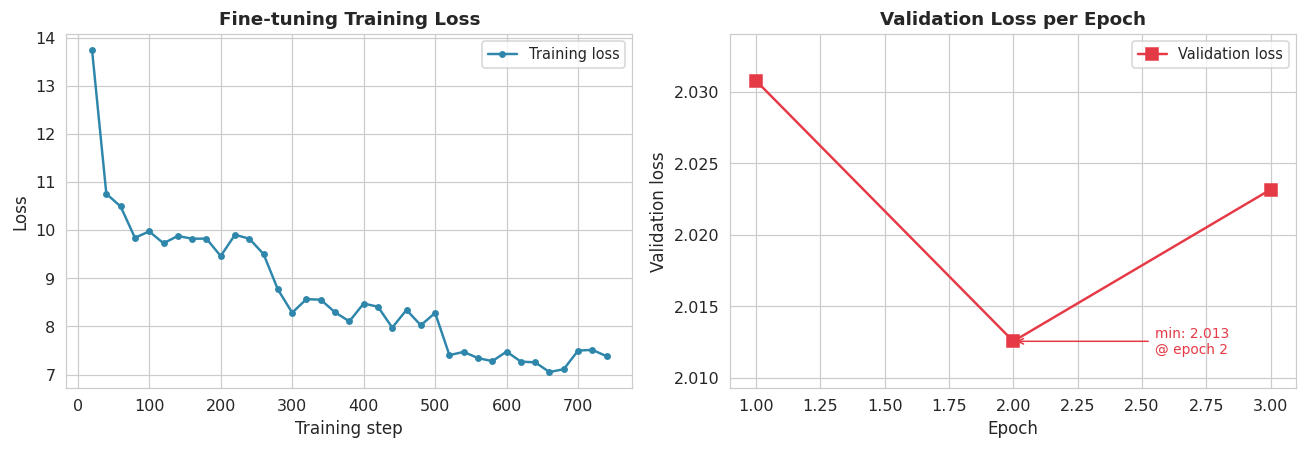


Training summary:
  train_runtime: 176.2103
  train_samples_per_second: 34.05
  train_steps_per_second: 4.256
  total_flos: 1570719224954880.0
  train_loss: 8.656679524739584
  epoch: 3.0

[2/5] Plotting XSum ROUGE + BERTScore bar chart...
Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/02_xsum_metrics_bar.png


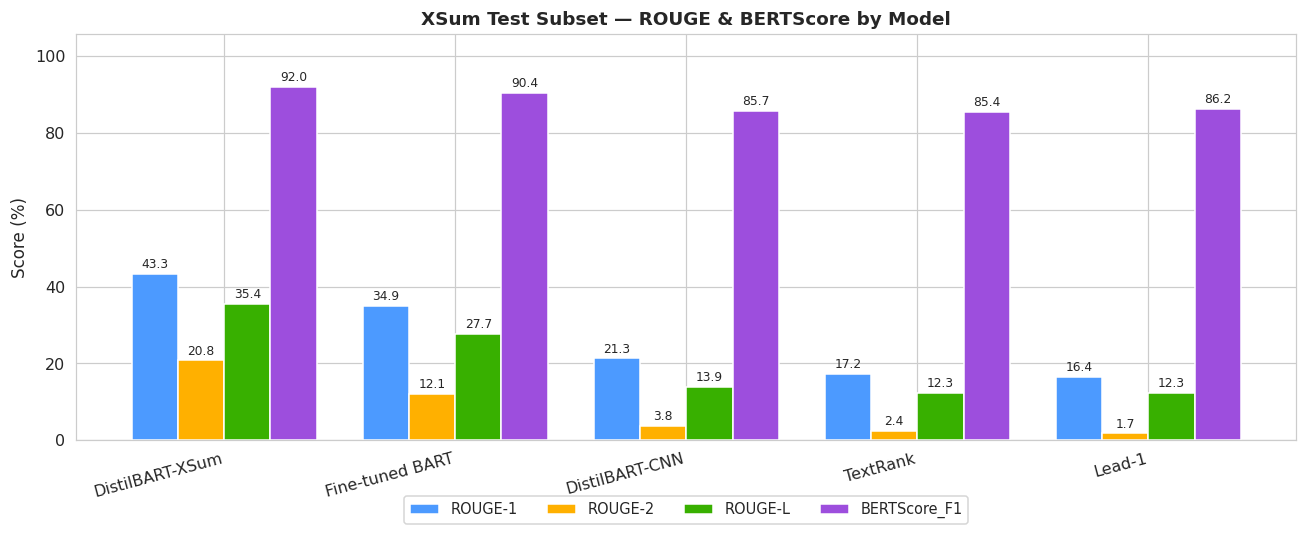


[3/5] Plotting CNN/DailyMail ROUGE + BERTScore bar chart...
Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/03_cnndm_metrics_bar.png


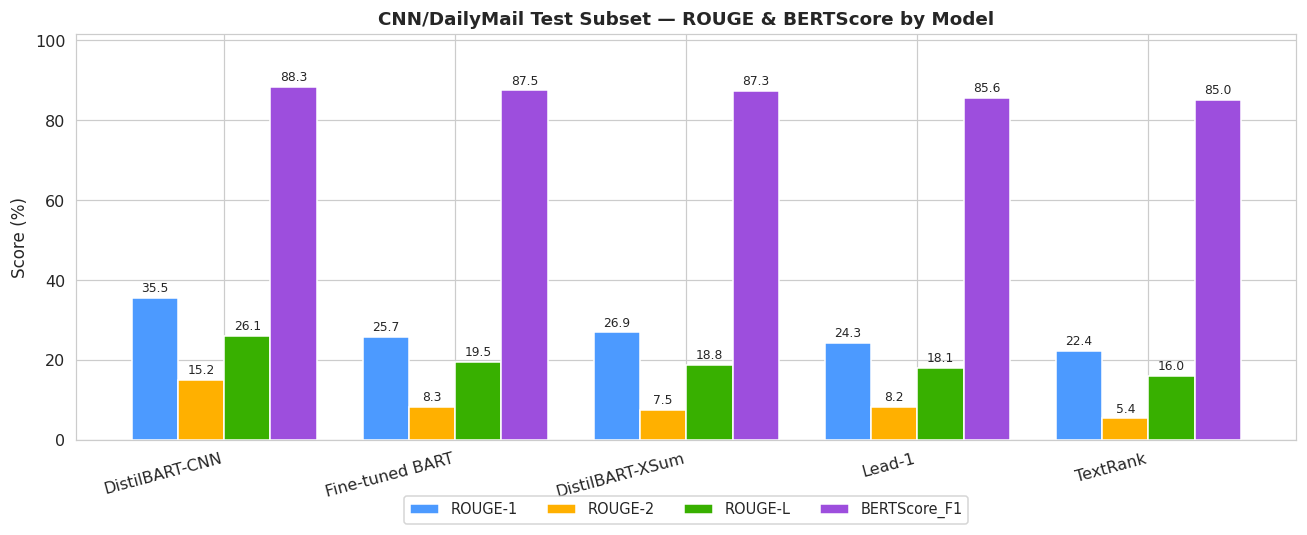


[4/5] Plotting cross-dataset comparison...
Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/04_cross_dataset_comparison.png


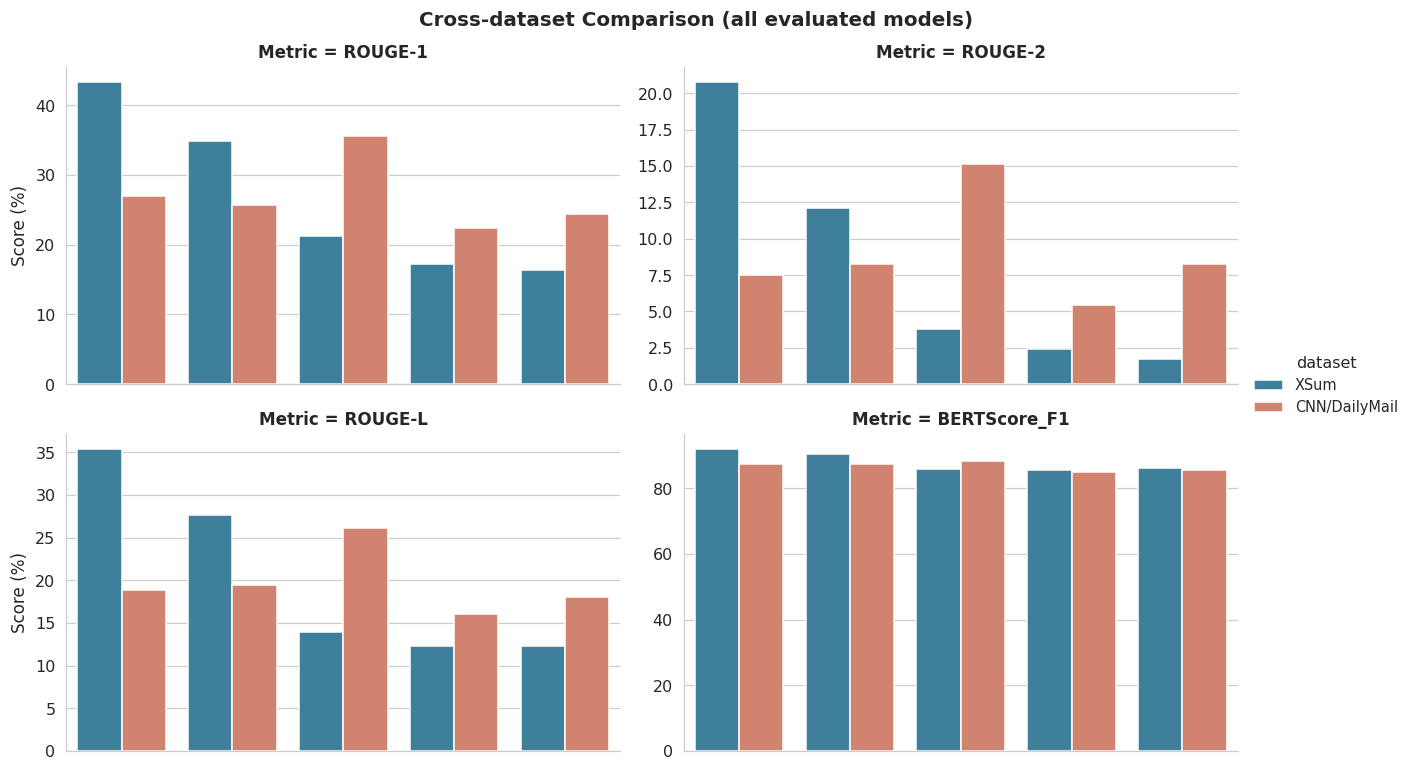


[5/5] Plotting human evaluation results...
Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/05_human_eval_average.png


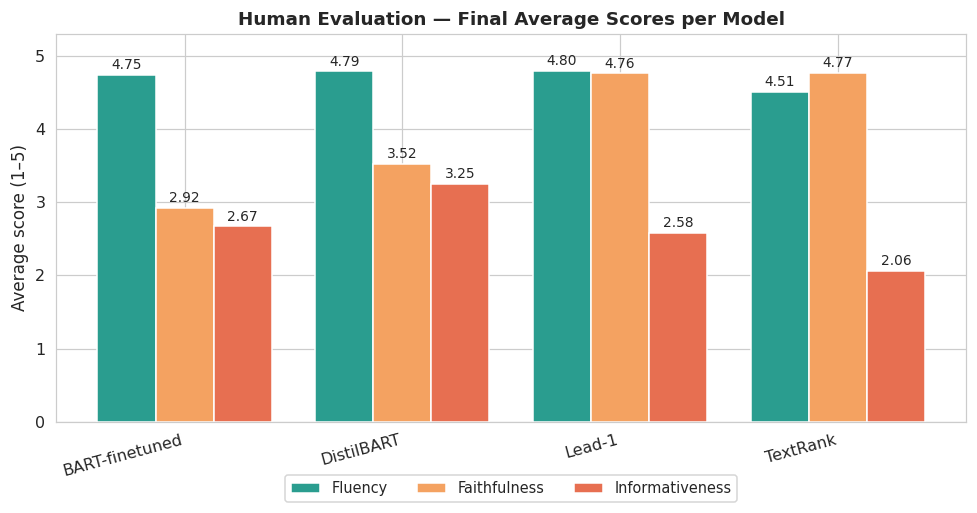

Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/06_human_eval_heatmap.png


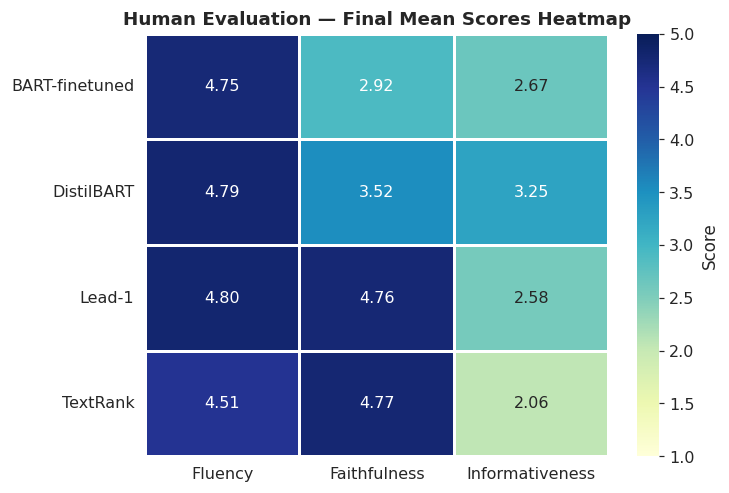

Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/07_human_eval_boxplot.png


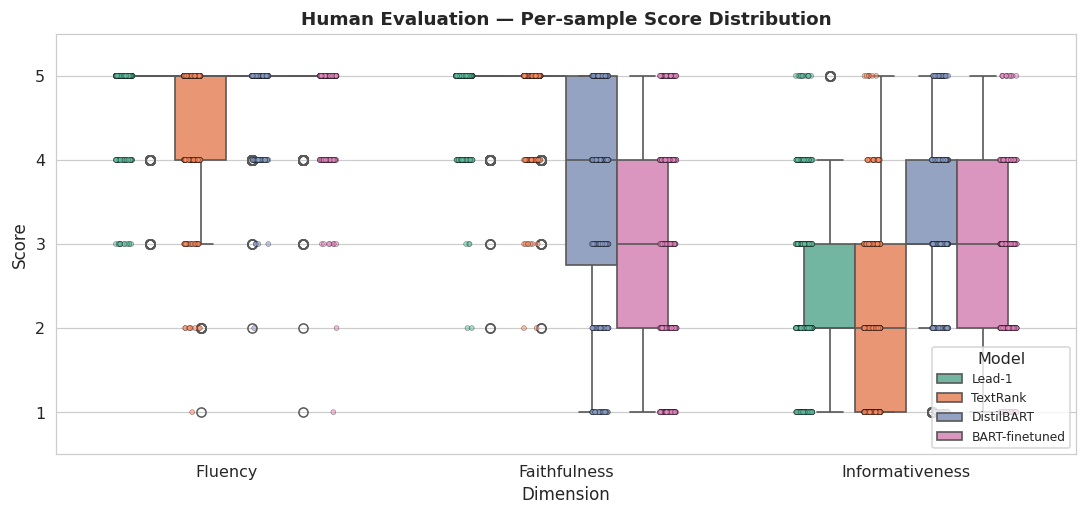

Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/08_per_annotator_scores.png


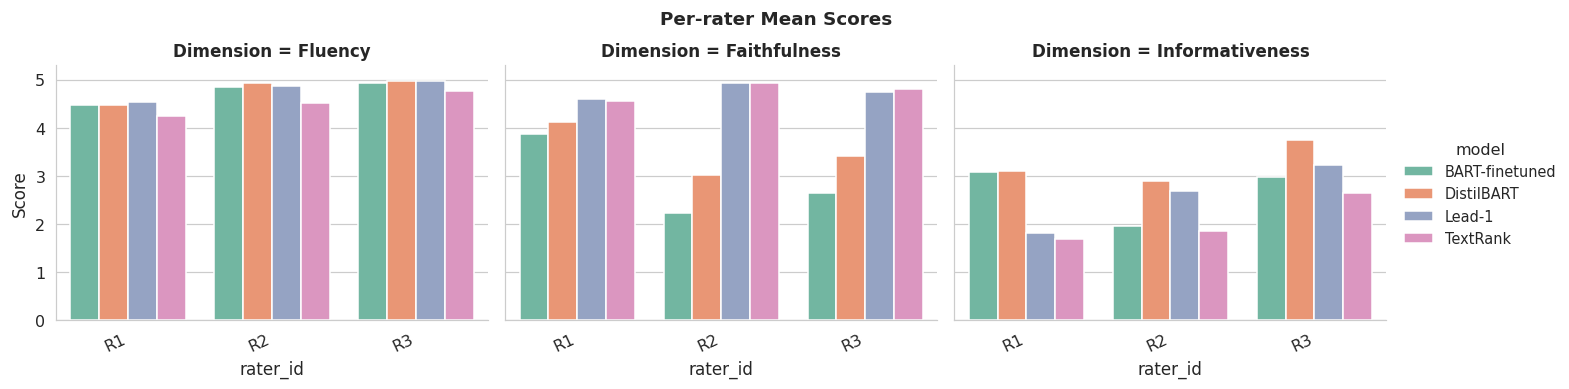

Saved figure: /content/drive/MyDrive/news_summarisation_bart/outputs/figures/09_krippendorff_alpha.png


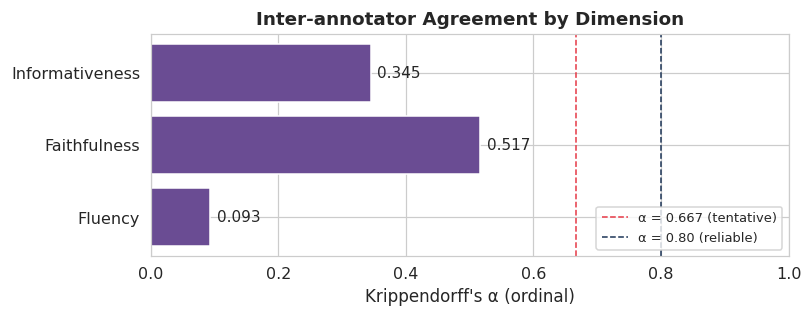


All figures saved under: /content/drive/MyDrive/news_summarisation_bart/outputs/figures


In [ ]:
# ==================== Visualisation Setup ====================
# I import the plotting libraries, apply a consistent figure style, and prepare the figure output folder.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
})

FIG_DIR = PROJECT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# I save each generated figure to the shared figure directory.
def _savefig(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved figure:", path)


# ==================== 1. Fine-tuning Training Curves ====================
# I plot training and validation loss to inspect the fine-tuning process.
# =========================================================================
print("=" * 60)
print("[1/5] Plotting fine-tuning training curves...")
print("=" * 60)

log_history = bart_trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_steps = [x["step"] for x in train_logs]
train_loss  = [x["loss"] for x in train_logs]
eval_epochs = [x["epoch"] for x in eval_logs]
eval_loss   = [x["eval_loss"] for x in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    train_steps,
    train_loss,
    marker="o",
    markersize=3.5,
    linewidth=1.6,
    color="#2E86AB",
    label="Training loss"
)
axes[0].set_title("Fine-tuning Training Loss")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].legend()

# I plot validation loss by epoch and mark the lowest validation point when evaluation logs are available.
if len(eval_epochs) > 0:
    axes[1].plot(
        eval_epochs,
        eval_loss,
        marker="s",
        markersize=8,
        linewidth=1.6,
        color="#E63946",
        label="Validation loss"
    )

    min_idx = int(np.argmin(eval_loss))
    axes[1].annotate(
        f"min: {eval_loss[min_idx]:.3f}\n@ epoch {eval_epochs[min_idx]:.0f}",
        xy=(eval_epochs[min_idx], eval_loss[min_idx]),
        xytext=(2.55, eval_loss[min_idx]),
        textcoords="data",
        ha="left",
        va="center",
        fontsize=9,
        color="#E63946",
        arrowprops=dict(
            arrowstyle="->",
            color="#E63946",
            lw=1
        ),
    )

    axes[1].set_title("Validation Loss per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation loss")
    axes[1].legend(loc="upper right")
    axes[1].margins(y=0.18)
else:
    axes[1].text(
        0.5,
        0.5,
        "No eval logs recorded",
        ha="center",
        va="center",
        transform=axes[1].transAxes
    )

plt.tight_layout()
_savefig("01_training_curves")
plt.show()

print("\nTraining summary:")
for k, v in bart_train_result.metrics.items():
    print(f"  {k}: {v}")


# ==================== 2. XSum Quantitative Metrics ====================
# I compare ROUGE and BERTScore across models on the XSum test subset.
# =====================================================================
print("\n" + "=" * 60)
print("[2/5] Plotting XSum ROUGE + BERTScore bar chart...")
print("=" * 60)

metrics_cols = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore_F1"]
palette = ["#4C9AFF", "#FFB000", "#38B000", "#9D4EDD"]

model_display_map = {
    "Lead-1": "Lead-1",
    "TextRank": "TextRank",
    "distilbart-xsum-12-6": "DistilBART-XSum",
    "distilbart-cnn-12-6": "DistilBART-CNN",
    "facebook/bart-base fine-tuned on XSum": "Fine-tuned BART",
}

xsum_plot_df = xsum_eval_results_df.copy()
xsum_plot_df["model_display"] = (
    xsum_plot_df["model"]
    .map(model_display_map)
    .fillna(xsum_plot_df["model"])
)

x = np.arange(len(xsum_plot_df))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate(metrics_cols):
    bars = ax.bar(
        x + (i - 1.5) * width,
        xsum_plot_df[col],
        width=width,
        label=col,
        color=palette[i],
        edgecolor="white"
    )

    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.8,
            f"{b.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(xsum_plot_df["model_display"], rotation=15, ha="right")
ax.set_ylabel("Score (%)")
ax.set_title("XSum Test Subset — ROUGE & BERTScore by Model")
ax.set_ylim(0, max(xsum_plot_df[metrics_cols].values.max() * 1.15, 100))
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
_savefig("02_xsum_metrics_bar")
plt.show()


# ==================== 3. CNN/DailyMail Quantitative Metrics ====================
# I compare ROUGE and BERTScore across models on the CNN/DailyMail test subset.
# ===============================================================================
print("\n" + "=" * 60)
print("[3/5] Plotting CNN/DailyMail ROUGE + BERTScore bar chart...")
print("=" * 60)

cnn_plot_df = cnndm_eval_results_df.copy()
cnn_plot_df["model_display"] = (
    cnn_plot_df["model"]
    .map(model_display_map)
    .fillna(cnn_plot_df["model"])
)

x = np.arange(len(cnn_plot_df))

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate(metrics_cols):
    bars = ax.bar(
        x + (i - 1.5) * width,
        cnn_plot_df[col],
        width=width,
        label=col,
        color=palette[i],
        edgecolor="white"
    )

    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.8,
            f"{b.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(cnn_plot_df["model_display"], rotation=15, ha="right")
ax.set_ylabel("Score (%)")
ax.set_title("CNN/DailyMail Test Subset — ROUGE & BERTScore by Model")
ax.set_ylim(0, max(cnn_plot_df[metrics_cols].values.max() * 1.15, 100))
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
_savefig("03_cnndm_metrics_bar")
plt.show()


# ==================== 4. Cross-dataset Comparison ====================
# I compare the same evaluated models across both datasets to inspect broader performance patterns.
# ====================================================================
print("\n" + "=" * 60)
print("[4/5] Plotting cross-dataset comparison...")
print("=" * 60)

cross_df = all_quant_eval_df.copy()
cross_df["model_display"] = (
    cross_df["model"]
    .map(model_display_map)
    .fillna(cross_df["model"])
)

cross_long = cross_df.melt(
    id_vars=["dataset", "model_display"],
    value_vars=metrics_cols,
    var_name="Metric",
    value_name="Score"
)

g = sns.catplot(
    data=cross_long,
    x="model_display",
    y="Score",
    hue="dataset",
    col="Metric",
    kind="bar",
    col_wrap=2,
    height=3.6,
    aspect=1.6,
    palette=["#2E86AB", "#E07A5F"],
    sharey=False,
)

g.set_xticklabels(rotation=25, ha="right")
g.set_axis_labels("", "Score (%)")
g.fig.suptitle(
    "Cross-dataset Comparison (all evaluated models)",
    y=1.02,
    fontsize=13,
    fontweight="bold"
)

_savefig("04_cross_dataset_comparison")
plt.show()


# ==================== 5. Human Evaluation Visualisation ====================
# I plot the final human evaluation summary, agreement scores, and rater-level patterns when those data are available.
# ==========================================================================
print("\n" + "=" * 60)
print("[5/5] Plotting human evaluation results...")
print("=" * 60)

has_final_human_summary = (
    "model_level_human_scores_df" in globals()
    and isinstance(model_level_human_scores_df, pd.DataFrame)
    and len(model_level_human_scores_df) > 0
)

has_human_eval_long = (
    "human_eval_ratings_long_df" in globals()
    and isinstance(human_eval_ratings_long_df, pd.DataFrame)
    and len(human_eval_ratings_long_df) > 0
)

rating_cols = ["fluency (1-5)", "faithfulness (1-5)", "informativeness (1-5)"]
disp_names = ["Fluency", "Faithfulness", "Informativeness"]
col_disp_map = dict(zip(rating_cols, disp_names))

# I match score columns flexibly because the final summary table may use cleaned column names.
score_col_candidates = {
    "Fluency": [
        "Fluency", "fluency", "fluency_score", "fluency_mean",
        "mean_fluency", "avg_fluency", "average_fluency",
        "fluency (1-5)"
    ],
    "Faithfulness": [
        "Faithfulness", "faithfulness", "faithfulness_score", "faithfulness_mean",
        "mean_faithfulness", "avg_faithfulness", "average_faithfulness",
        "faithfulness (1-5)"
    ],
    "Informativeness": [
        "Informativeness", "informativeness", "informativeness_score", "informativeness_mean",
        "mean_informativeness", "avg_informativeness", "average_informativeness",
        "informativeness (1-5)"
    ],
}

model_col_candidates = ["model", "Model", "model_name", "Model Name"]

def find_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


# I plot final model-level human evaluation scores from the latest summary table.
if has_final_human_summary:
    final_human_eval_summary_df = model_level_human_scores_df.copy()

    model_col = find_existing_column(final_human_eval_summary_df, model_col_candidates)

    selected_score_cols = {}
    for display_name, candidates in score_col_candidates.items():
        matched_col = find_existing_column(final_human_eval_summary_df, candidates)
        if matched_col is not None:
            selected_score_cols[display_name] = matched_col

    if model_col is None or len(selected_score_cols) == 0:
        print("Final human evaluation summary is available, but required plotting columns were not found.")
        print("Available columns:")
        print(list(final_human_eval_summary_df.columns))
    else:
        model_mean = final_human_eval_summary_df[[model_col] + list(selected_score_cols.values())].copy()
        model_mean = model_mean.rename(columns={model_col: "model"})
        model_mean = model_mean.rename(columns={v: k for k, v in selected_score_cols.items()})

        for col in selected_score_cols.keys():
            model_mean[col] = pd.to_numeric(model_mean[col], errors="coerce")

        model_mean = model_mean.dropna(subset=list(selected_score_cols.keys()))
        final_disp_names = list(selected_score_cols.keys())

        # I plot the latest average human scores for each model across the evaluation dimensions.
        x = np.arange(len(model_mean))
        width = 0.8 / len(final_disp_names)

        fig, ax = plt.subplots(figsize=(9, 4.8))
        dim_palette = ["#2A9D8F", "#F4A261", "#E76F51"]

        for i, d in enumerate(final_disp_names):
            offset = (i - (len(final_disp_names) - 1) / 2) * width
            bars = ax.bar(
                x + offset,
                model_mean[d],
                width=width,
                label=d,
                color=dim_palette[i],
                edgecolor="white"
            )

            for b in bars:
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    b.get_height() + 0.04,
                    f"{b.get_height():.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

        ax.set_xticks(x)
        ax.set_xticklabels(model_mean["model"], rotation=15, ha="right")
        ax.set_ylim(0, 5.3)
        ax.set_ylabel("Average score (1–5)")
        ax.set_title("Human Evaluation — Final Average Scores per Model")
        ax.legend(
            ncol=len(final_disp_names),
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12)
        )

        plt.tight_layout()
        _savefig("05_human_eval_average")
        plt.show()

        # I plot a heatmap from the latest final model-level summary table.
        heat_df = model_mean.set_index("model")[final_disp_names]

        fig, ax = plt.subplots(figsize=(6.8, 2.6 + 0.5 * len(heat_df)))
        sns.heatmap(
            heat_df,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            vmin=1,
            vmax=5,
            cbar_kws={"label": "Score"},
            ax=ax,
            linewidths=0.8,
            linecolor="white"
        )

        ax.set_title("Human Evaluation — Final Mean Scores Heatmap")
        ax.set_xlabel("")
        ax.set_ylabel("")

        plt.tight_layout()
        _savefig("06_human_eval_heatmap")
        plt.show()
else:
    print("Final model-level human evaluation summary is not available — skipping final average and heatmap plots.")


# I use the long human evaluation table for distribution and per-rater plots.
if has_human_eval_long:
    long_df = human_eval_ratings_long_df.copy()

    # I anonymise rater identifiers before plotting so personal or file-based labels are not shown in the final figures.
    if "rater_id" in long_df.columns:
        unique_raters = sorted(long_df["rater_id"].astype(str).unique())
        rater_display_map = {
            original_id: f"R{i + 1}"
            for i, original_id in enumerate(unique_raters)
        }
        long_df["rater_id"] = long_df["rater_id"].astype(str).map(rater_display_map)

    missing_rating_cols = [c for c in rating_cols if c not in long_df.columns]

    if len(missing_rating_cols) > 0:
        print("Long human evaluation table is available, but required rating columns were not found.")
        print("Missing columns:", missing_rating_cols)
        print("Available columns:")
        print(list(long_df.columns))
    else:
        for c in rating_cols:
            long_df[c] = pd.to_numeric(long_df[c], errors="coerce")

        long_df = long_df.dropna(subset=rating_cols)

        # I plot the per-sample score distribution to inspect spread and variability across models.
        plot_long = long_df.melt(
            id_vars=["model"],
            value_vars=rating_cols,
            var_name="Dimension",
            value_name="Score"
        )
        plot_long["Dimension"] = plot_long["Dimension"].map(col_disp_map)

        fig, ax = plt.subplots(figsize=(10, 4.8))
        sns.boxplot(
            data=plot_long,
            x="Dimension",
            y="Score",
            hue="model",
            palette="Set2",
            width=0.6,
            linewidth=1.1,
            ax=ax
        )
        sns.stripplot(
            data=plot_long,
            x="Dimension",
            y="Score",
            hue="model",
            dodge=True,
            palette="Set2",
            edgecolor="black",
            linewidth=0.3,
            size=3.2,
            alpha=0.55,
            ax=ax
        )

        handles, labels = ax.get_legend_handles_labels()
        n_models = plot_long["model"].nunique()
        ax.legend(
            handles[:n_models],
            labels[:n_models],
            title="Model",
            loc="lower right",
            fontsize=8
        )

        ax.set_ylim(0.5, 5.5)
        ax.set_title("Human Evaluation — Per-sample Score Distribution")

        plt.tight_layout()
        _savefig("07_human_eval_boxplot")
        plt.show()

        # I plot per-rater mean scores to inspect possible rater-level differences.
        if "rater_id" in long_df.columns and long_df["rater_id"].nunique() > 1:
            per_annot = (
                long_df.groupby(["rater_id", "model"])[rating_cols]
                .mean()
                .reset_index()
            )

            per_annot_long = per_annot.melt(
                id_vars=["rater_id", "model"],
                value_vars=rating_cols,
                var_name="Dimension",
                value_name="Score"
            )
            per_annot_long["Dimension"] = per_annot_long["Dimension"].map(col_disp_map)

            g = sns.catplot(
                data=per_annot_long,
                x="rater_id",
                y="Score",
                hue="model",
                col="Dimension",
                kind="bar",
                height=3.3,
                aspect=1.3,
                palette="Set2",
                sharey=True,
            )

            g.set(ylim=(0, 5.3))
            g.set_xticklabels(rotation=25, ha="right")
            g.fig.suptitle(
                "Per-rater Mean Scores",
                y=1.04,
                fontsize=12,
                fontweight="bold"
            )

            _savefig("08_per_annotator_scores")
            plt.show()
else:
    print("Long human evaluation data is not available — skipping distribution and per-rater plots.")


# I plot Krippendorff's alpha to inspect inter-annotator agreement by dimension.
if (
    "alpha_results_df" in globals()
    and isinstance(alpha_results_df, pd.DataFrame)
    and len(alpha_results_df) > 0
):
    alpha_plot = alpha_results_df.copy()

    if "metric" in alpha_plot.columns and "krippendorff_alpha" in alpha_plot.columns:
        alpha_plot["metric"] = alpha_plot["metric"].astype(str).str.capitalize()
        alpha_plot["krippendorff_alpha"] = pd.to_numeric(
            alpha_plot["krippendorff_alpha"],
            errors="coerce"
        )
        alpha_plot = alpha_plot.dropna(subset=["krippendorff_alpha"])

        fig, ax = plt.subplots(figsize=(7.5, 3.0))
        bars = ax.barh(
            alpha_plot["metric"],
            alpha_plot["krippendorff_alpha"],
            color="#6A4C93",
            edgecolor="white"
        )

        for b, v in zip(bars, alpha_plot["krippendorff_alpha"]):
            ax.text(
                v + 0.01,
                b.get_y() + b.get_height() / 2,
                f"{v:.3f}",
                va="center",
                fontsize=10
            )

        ax.axvline(
            0.667,
            color="#E63946",
            linestyle="--",
            linewidth=1,
            label="α = 0.667 (tentative)"
        )
        ax.axvline(
            0.80,
            color="#1D3557",
            linestyle="--",
            linewidth=1,
            label="α = 0.80 (reliable)"
        )

        x_min = min(0, alpha_plot["krippendorff_alpha"].min() - 0.05)
        ax.set_xlim(x_min, 1.0)
        ax.set_xlabel("Krippendorff's α (ordinal)")
        ax.set_title("Inter-annotator Agreement by Dimension")
        ax.legend(loc="lower right", fontsize=8.5)

        plt.tight_layout()
        _savefig("09_krippendorff_alpha")
        plt.show()
    else:
        print("Krippendorff's Alpha table is available, but required columns were not found.")
        print("Available columns:")
        print(list(alpha_plot.columns))
else:
    print("Krippendorff's Alpha results are not available — skipping agreement plot.")


print("\n" + "=" * 60)
print("All figures saved under:", FIG_DIR)
print("=" * 60)

### Package the Project Folder and Download the Archive

I create a ZIP archive of the full project folder and download it to my local machine.

The archive bundles the main project files, including generated outputs, scripts, saved figures, evaluation results, human evaluation files, demo files, and saved model artefacts. This gives me one complete project snapshot that can be stored, shared, or reviewed outside Colab.

In [ ]:
import shutil
from google.colab import files

# I define the ZIP output path using the project name for a cleaner exported archive.
zip_base = "/content/news_summarisation_bart"
zip_path = f"{zip_base}.zip"

# I remove any older ZIP archive with the same name before creating a fresh package.
if Path(zip_path).exists():
    Path(zip_path).unlink()

# I create a ZIP archive of the full project folder, including outputs, scripts, figures, and saved artefacts.
shutil.make_archive(zip_base, "zip", str(PROJECT_DIR))

# I print the archive details before downloading it.
print("Project ZIP archive has been created.")
print(f"ZIP path: {zip_path}")
print(f"ZIP exists: {Path(zip_path).exists()}")
print(f"ZIP size: {Path(zip_path).stat().st_size} bytes")

# I download the ZIP archive to the local machine.
files.download(zip_path)

Project ZIP archive has been created.
ZIP path: /content/news_summarisation_bart.zip
ZIP exists: True
ZIP size: 529079557 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 12 Summary: Results Visualisation and Final Packaging

I generated the final visualisations for the main project results.

In this part, I:

* plotted the fine-tuning training and validation loss curves;
* visualised automatic evaluation results for XSum and CNN/DailyMail;
* compared model performance across datasets;
* created human evaluation figures for average scores, score distributions, rater-level patterns, and inter-annotator agreement;
* saved all generated figures under the project output folder;
* packaged the full project folder into a single ZIP archive.

This final stage consolidates the key outputs, figures, scripts, saved artefacts, evaluation results, and demo files into a cleaner and more portable project snapshot for later review, reporting, and sharing.

## Overall Summary

This notebook presents a complete workflow for my **neural abstractive summarisation of news articles** project. I build an end-to-end pipeline that prepares datasets, implements baseline and neural summarisation models, fine-tunes a custom BART model, evaluates model outputs, supports qualitative and human judgement, and packages the final project files for reuse.

The workflow covers:

**Environment setup → Dataset loading and preprocessing → Baseline methods → Pre-trained model inference → Fine-tuning → Automatic evaluation → Qualitative analysis → Human evaluation → CLI and Gradio demo → Results visualisation → Final packaging**

---

### 1. Environment Setup and Data Preparation

I first prepare a stable working environment in Google Colab.

In this stage, I:

* mount Google Drive;
* install and import the required libraries;
* define reusable project folders and paths;
* load the XSum and CNN/DailyMail datasets;
* standardise both datasets into a shared dataframe format.

The shared dataset format includes article text, reference summaries, dataset identifiers, and helper statistics such as word counts, character counts, and sentence counts.

I also apply light text cleaning, remove invalid or duplicated rows, add helper columns, and save the processed dataset splits for later reuse. This creates a consistent data foundation for the modelling, evaluation, and analysis stages.

---

### 2. Baseline Methods

I implement 2 extractive baseline methods:

* **Lead-1**, which selects the first sentence of the article;
* **TextRank**, which selects an important sentence using graph-based sentence ranking.

I apply both baselines to the XSum and CNN/DailyMail evaluation splits, save their prediction files, and create overview tables comparing generated summary lengths with reference summary lengths. These baselines provide simple reference points for evaluating the neural summarisation models.

---

### 3. Pre-trained Model Inference

I evaluate 2 publicly available DistilBART summarisation checkpoints in zero-shot inference mode:

* **sshleifer/distilbart-xsum-12-6**
* **sshleifer/distilbart-cnn-12-6**

I use a shared batch inference function so generation is handled consistently across datasets and models.

The inference workflow follows this structure:

**Load model → Test sample generation → Run full evaluation-set inference → Save predictions → Summarise output statistics**

Both pre-trained checkpoints are applied to XSum and CNN/DailyMail. The saved prediction files are then reused in the quantitative, qualitative, and human evaluation stages.

---

### 4. Fine-tuning

I fine-tune **facebook/bart-base** on the XSum training subset.

The fine-tuning stage includes:

* preparing Hugging Face datasets;
* tokenising article-summary pairs;
* building a `Seq2SeqTrainer` pipeline;
* training with gradient accumulation;
* saving the model, tokenizer, and training logs;
* running inference with the fine-tuned model.

After training, I test the fine-tuned model on sample articles and generate full prediction files for both XSum and CNN/DailyMail evaluation sets. This gives the project a custom trained summarisation model that can be compared with the extractive baselines and pre-trained checkpoints.

---

### 5. Quantitative Evaluation

I evaluate the baseline, pre-trained, and fine-tuned models using:

* **ROUGE-1**
* **ROUGE-2**
* **ROUGE-L**
* **BERTScore F1**

I create separate evaluation tables for XSum and CNN/DailyMail, combine the results into a cross-dataset comparison table, and add within-dataset ROUGE-L rankings.

In this run, the dataset-matched DistilBART checkpoints achieve the strongest automatic results on their corresponding datasets. DistilBART-XSum performs best on XSum, while DistilBART-CNN performs best on CNN/DailyMail. The fine-tuned BART model provides a custom project-trained comparison point and helps demonstrate the transfer behaviour of an XSum-trained model on a different summarisation dataset.

---

### 6. Qualitative Analysis

I define 3 qualitative error categories:

* **Hallucination**, where generated content is not clearly supported by the article;
* **Omission**, where important information is missing;
* **Fluency issue**, where the output is awkward, incomplete, repetitive, or unnatural.

I build a unified qualitative review pool across all evaluated models and datasets. I then add helper features such as article overlap ratio, reference unigram recall, repeated bigram ratio, generated word count, generated sentence count, and punctuation checks.

These features are used to flag candidate examples for manual review. I save the candidate tables and review template so error analysis can be completed in a more structured and reproducible way.

---

### 7. Human Evaluation

I define a human evaluation rubric with 3 dimensions:

* **Fluency**
* **Faithfulness**
* **Informativeness**

The human evaluation stage includes:

* loading completed annotation files;
* handling different CSV encodings;
* cleaning score fields;
* anonymising rater identifiers;
* merging ratings into one long-format dataframe;
* computing average summary-level scores;
* computing model-level mean scores;
* measuring inter-annotator agreement with **Krippendorff’s Alpha**.

The saved human evaluation tables provide supporting evidence for comparing model quality beyond automatic metrics alone.

---

### 8. Interfaces and Demo Components

I build 2 practical interfaces for using the project outside the main notebook.

The **command-line interface** supports:

* direct text input;
* file-based input;
* summary generation from the project methods;
* printed model outputs for comparison.

The **Gradio demo** supports:

* article input;
* optional reference summary input;
* generated summaries displayed in one table;
* ROUGE scores when a reference summary is provided;
* an interactive prototype for testing the summarisation workflow.

These components make the project more reusable than a notebook-only workflow.

---

### 9. Results Visualisation and Final Packaging

I create final result visualisations for:

* fine-tuning training curves;
* XSum metric comparison;
* CNN/DailyMail metric comparison;
* cross-dataset model comparison;
* human evaluation average scores;
* human evaluation score distributions;
* per-rater rating patterns;
* Krippendorff’s Alpha agreement scores.

All generated figures are saved under the project output folder for later reporting and discussion.

I also package the full project folder into a ZIP archive so the outputs, scripts, model files, figures, evaluation tables, demo files, and related artefacts can be stored and reviewed as one complete project snapshot.

---

### 10. Key Findings

This notebook builds a complete end-to-end summarisation pipeline rather than a set of isolated experiments.

The main findings are:

* dataset-specific pre-trained checkpoints remain strong automatic baselines;
* the fine-tuned BART model adds a custom trained summarisation system for comparison;
* automatic metrics and human evaluation provide different but complementary views of model quality;
* qualitative analysis helps identify error patterns that aggregate scores alone cannot explain;
* CLI and Gradio components improve practical usability beyond the notebook environment.

Overall, the project provides a structured comparison of extractive baselines, pre-trained abstractive models, and a fine-tuned BART model across multiple evaluation perspectives.

---

### 11. Limitations

The current workflow has several limitations.

The fine-tuning stage is constrained by Colab runtime and memory limits. Batch size, training duration, and hyperparameter exploration are limited, and development-sized subsets are used to keep the notebook runnable.

The fine-tuned BART model is trained only on XSum, so applying it to CNN/DailyMail introduces a cross-dataset transfer limitation. The qualitative analysis also uses heuristic candidate selection, which means final error interpretation still requires manual judgement.

Human evaluation depends on the number of raters, the number of rated summaries, and annotation consistency. These factors should be considered when interpreting the final human evaluation results.

---

### 12. Future Directions

Future work could improve the project in several directions:

* train the fine-tuned model for longer;
* use larger training subsets or full datasets when resources allow;
* tune hyperparameters more carefully;
* compare more abstractive summarisation checkpoints;
* test more cross-dataset transfer settings;
* add runtime and memory-efficiency analysis;
* expand qualitative analysis with more systematic manual annotation;
* increase the scale of human evaluation;
* extend the Gradio demo with model selection controls, export options, and richer result comparison views.

---

### Conclusion

This notebook builds a complete workflow for **neural abstractive summarisation of news articles**, covering data preparation, modelling, evaluation, human judgement, interface development, visualisation, and final packaging.

It provides a clear technical foundation for comparing summarisation methods and shows how the current system can be extended in future work.